In [1]:
import uproot 
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import seaborn as sns
import plotly.express as px
from matplotlib import colors
import math as math
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from catboost.utils import get_roc_curve
import joblib
from sklearn.preprocessing import StandardScaler

In [2]:
data24_magup = pd.read_pickle('data24_magup_200_all.pkl')

model = CatBoostClassifier().load_model("BDT_MagUP_all")
prob = model.predict_proba(data24_magup)
print(prob)

signal_MVA_prob_eval = prob
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
data24_magup['prob'] = signal_MVA_probs


[[9.99733558e-01 2.66441780e-04]
 [9.95360646e-01 4.63935423e-03]
 [9.99999122e-01 8.78405599e-07]
 ...
 [1.00000000e+00 6.19477873e-20]
 [1.00000000e+00 2.70203724e-11]
 [9.99999758e-01 2.42344436e-07]]


/tmp/javeser/ipykernel_1727/1200111621.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data24_magup['prob'] = signal_MVA_probs


In [51]:
model.best_score_


{'learn': {'Logloss:use_weights=true': 0.007116543203041112,
  'Logloss:use_weights=false': 0.009470654830837503,
  'Accuracy:use_weights=true': 0.9983596718440378,
  'Logloss': 0.007116543203041112,
  'Accuracy:use_weights=false': 0.9967395089900664,
  'AUC': 0.9998849781184074}}

In [3]:
data24_magdown = pd.read_pickle('data24_magdown_50_all.pkl')

model = CatBoostClassifier().load_model("BDT_MagDown_all")
prob = model.predict_proba(data24_magdown)
print(prob)

signal_MVA_prob_eval = prob
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
data24_magdown['prob'] = signal_MVA_probs


[[9.99269371e-01 7.30628559e-04]
 [9.99996580e-01 3.41988759e-06]
 [9.99999994e-01 5.68766449e-09]
 ...
 [1.00000000e+00 8.43273934e-12]
 [9.99999931e-01 6.90486899e-08]
 [9.99999820e-01 1.80027959e-07]]


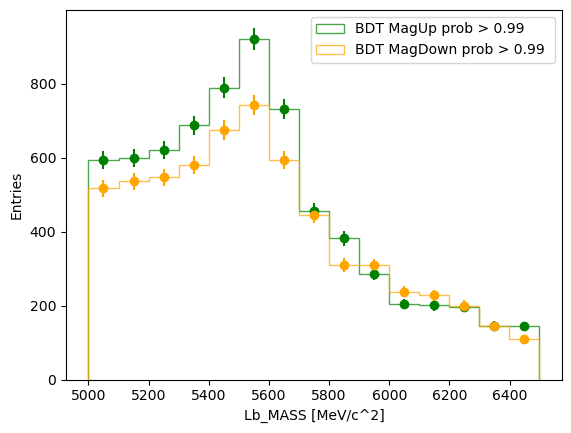

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create the figure and axes
fig, axes = plt.subplots()

# Plot histograms
hist1, bins1, _ = axes.hist(data24_magup.query('(prob > 0.99)')['Lb_MASS'], bins=15, label='BDT MagUp prob > 0.99', color='green', alpha=0.7, histtype='step')
hist2, bins2, _ = axes.hist(data24_magdown.query('(prob > 0.99)')['Lb_MASS'], bins=15, label='BDT MagDown prob > 0.99 ', color='orange', alpha=0.7, histtype='step')

# Calculate the bin centers for the error bars
bin_centers1 = 0.5 * (bins1[1:] + bins1[:-1])
bin_centers2 = 0.5 * (bins2[1:] + bins2[:-1])

# Plot error bars for the first histogram
axes.errorbar(
    bin_centers1,
    hist1,
    yerr=np.sqrt(hist1),
    fmt='o',
    color='green',
    # label='Binary Data',
    drawstyle='steps-mid'
)

# Plot error bars for the second histogram
axes.errorbar(
    bin_centers2,
    hist2,
    yerr=np.sqrt(hist2),
    fmt='o',
    color='orange',
    # label='MultiClass Data',
    drawstyle='steps-mid'
)

# Set labels and legend
plt.xlabel('Lb_MASS [MeV/c^2]')
plt.ylabel('Entries')
plt.legend()

# Display the plot
plt.show()


Armentero variables 

Ajuste de fondo exponencial para MagUp 

[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (signal,background)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization

  RooFitResult: minimized FCN value: 228779, estimated distance to minimum: 7.21136e-07
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas


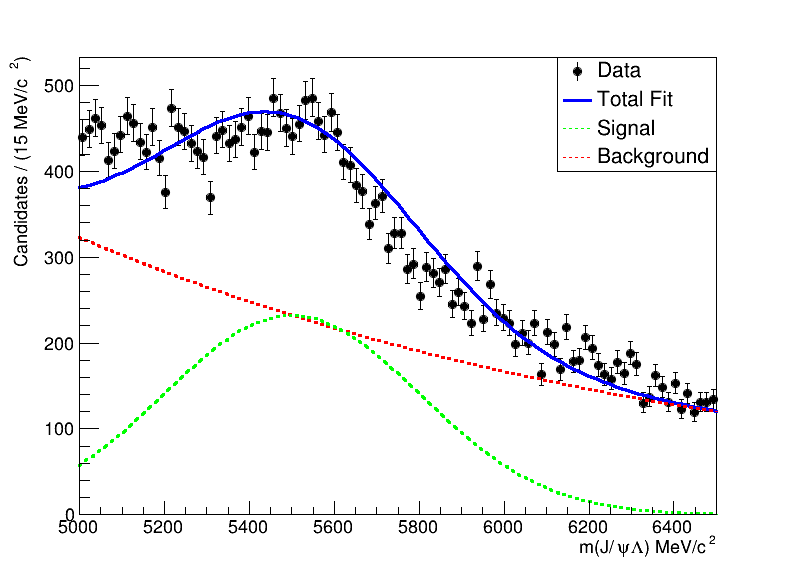

In [27]:
import ROOT
import pandas as pd

# Filtra los datos según las condiciones especificadas  abs(data24_magup['alpha_combined']) > 0.45) & 
filtered_mass = data24_magup.loc[
    (data24_magup['prob'] > 0.75), 
    'Lb_MASS'
]

# Convierte la Serie de pandas filtrada a un RooDataSet
x = ROOT.RooRealVar('x', 'x', 5000, 6500)
data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
for mass in filtered_mass:
    x.setVal(mass)
    data_list.add(ROOT.RooArgSet(x))

# Define los parámetros para la señal
sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 5600, 5500, 5650)
sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 120, 100, 300)

# Construye el modelo de señal Gaussiano
signalModel = ROOT.RooGaussian('signal', 'signal', x, sigmean, sigwidth)

# Define el parámetro para el fondo exponencial
lambda_bg = ROOT.RooRealVar('lambda_bg', 'slope', -0.001, -1.0, 0.0)

# Construye el modelo de fondo exponencial
background = ROOT.RooExponential('background', 'background', x, lambda_bg)

# Realiza el ajuste del fondo
background_fit_result = background.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Realiza el ajuste de la señal
signal_fit_result = signalModel.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Construye un modelo combinado de señal y fondo
nsig = ROOT.RooRealVar('nsig', 'nsig', 1000, 100., 20000)
nbkg = ROOT.RooRealVar('nbkg', 'nbkg', 400, 100., 20000)
model = ROOT.RooAddPdf('model', 'model', ROOT.RooArgList(signalModel, background), ROOT.RooArgList(nsig, nbkg))

# Realiza el ajuste total
total_fit_result = model.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Imprime los resultados del ajuste
background_fit_result.Print()
signal_fit_result.Print()
total_fit_result.Print()

# Crea un RooPlot para dibujar
xframe = x.frame()

# Dibuja los datos y el modelo combinado
data_list.plotOn(xframe)
model.plotOn(xframe)
model.plotOn(xframe, ROOT.RooFit.Components('background'), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kRed))
model.plotOn(xframe, ROOT.RooFit.Components('signal'), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kGreen))

# Configura los títulos de los ejes
xframe.SetTitle("")
xframe.SetXTitle("m(J/#psi#Lambda) MeV/c^{2}")
xframe.SetYTitle("Candidates / (15 MeV/c^{2})")

# Crea una leyenda
legend = ROOT.TLegend(0.7, 0.7, 0.9, 0.9)

# Ajusta el estilo de los puntos de la leyenda a círculos
data_marker = ROOT.TMarker()
data_marker.SetMarkerStyle(ROOT.kFullCircle)
legend.AddEntry(data_marker, "Data", "pe")
legend.AddEntry(xframe.findObject("model_Norm[x]"), "Total Fit", "l")

# Ajusta el estilo de la línea de la leyenda para la señal a verde y discontinua
signal_line = ROOT.TLine()
signal_line.SetLineColor(ROOT.kGreen)
signal_line.SetLineStyle(ROOT.kDashed)
legend.AddEntry(signal_line, "Signal", "l")

# Ajusta el estilo de la línea de la leyenda para el fondo a rojo y discontinua
background_line = ROOT.TLine()
background_line.SetLineColor(ROOT.kRed)
background_line.SetLineStyle(ROOT.kDashed)
legend.AddEntry(background_line, "Background", "l")

# Dibuja el gráfico
canvas = ROOT.TCanvas('canvas', 'Fit Plot', 800, 600)
xframe.Draw()
canvas.Draw()
legend.Draw()

# Opcional: imprime las definiciones para verificar
x.Print()
sigmean.Print()
sigwidth.Print()
lambda_bg.Print()
nsig.Print()
nbkg.Print()
model.Print()


For MagDown

[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (signal,background)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization

  RooFitResult: minimized FCN value: 113446, estimated distance to minimum: 1.06511e-06
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas


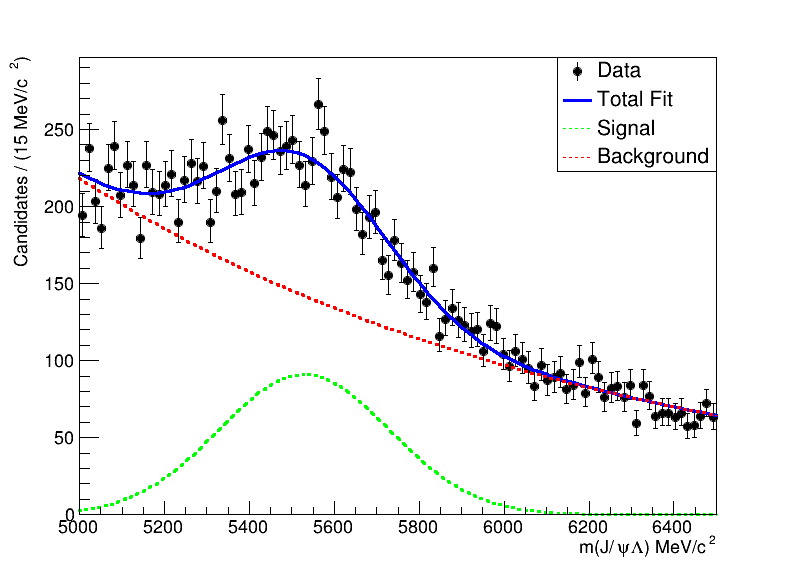

In [67]:
import ROOT
import pandas as pd

# Filtra los datos según las condiciones especificadas  abs(data24_magup['alpha_combined']) > 0.45) & 
filtered_mass = data24_magdown.loc[
    (data24_magdown['prob'] > 0.93), 
    'Lb_MASS'
]

# Convierte la Serie de pandas filtrada a un RooDataSet
x = ROOT.RooRealVar('x', 'x', 5000, 6500)
data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
for mass in filtered_mass:
    x.setVal(mass)
    data_list.add(ROOT.RooArgSet(x))

# Define los parámetros para la señal
sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 5600, 5500, 5650)
sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 120, 100, 300)

# Construye el modelo de señal Gaussiano
signalModel = ROOT.RooGaussian('signal', 'signal', x, sigmean, sigwidth)

# Define el parámetro para el fondo exponencial
lambda_bg = ROOT.RooRealVar('lambda_bg', 'slope', -0.001, -1.0, 0.0)

# Construye el modelo de fondo exponencial
background = ROOT.RooExponential('background', 'background', x, lambda_bg)

# Realiza el ajuste del fondo
background_fit_result = background.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Realiza el ajuste de la señal
signal_fit_result = signalModel.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Construye un modelo combinado de señal y fondo
nsig = ROOT.RooRealVar('nsig', 'nsig', 1000, 100., 20000)
nbkg = ROOT.RooRealVar('nbkg', 'nbkg', 400, 100., 60000)
model = ROOT.RooAddPdf('model', 'model', ROOT.RooArgList(signalModel, background), ROOT.RooArgList(nsig, nbkg))

# Realiza el ajuste total
total_fit_result = model.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Imprime los resultados del ajuste
background_fit_result.Print()
signal_fit_result.Print()
total_fit_result.Print()

# Crea un RooPlot para dibujar
xframe = x.frame()

# Dibuja los datos y el modelo combinado
data_list.plotOn(xframe)
model.plotOn(xframe)
model.plotOn(xframe, ROOT.RooFit.Components('background'), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kRed))
model.plotOn(xframe, ROOT.RooFit.Components('signal'), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kGreen))

# Configura los títulos de los ejes
xframe.SetTitle("")
xframe.SetXTitle("m(J/#psi#Lambda) MeV/c^{2}")
xframe.SetYTitle("Candidates / (15 MeV/c^{2})")

# Crea una leyenda
legend = ROOT.TLegend(0.7, 0.7, 0.9, 0.9)

# Ajusta el estilo de los puntos de la leyenda a círculos
data_marker = ROOT.TMarker()
data_marker.SetMarkerStyle(ROOT.kFullCircle)
legend.AddEntry(data_marker, "Data", "pe")
legend.AddEntry(xframe.findObject("model_Norm[x]"), "Total Fit", "l")

# Ajusta el estilo de la línea de la leyenda para la señal a verde y discontinua
signal_line = ROOT.TLine()
signal_line.SetLineColor(ROOT.kGreen)
signal_line.SetLineStyle(ROOT.kDashed)
legend.AddEntry(signal_line, "Signal", "l")

# Ajusta el estilo de la línea de la leyenda para el fondo a rojo y discontinua
background_line = ROOT.TLine()
background_line.SetLineColor(ROOT.kRed)
background_line.SetLineStyle(ROOT.kDashed)
legend.AddEntry(background_line, "Background", "l")

# Dibuja el gráfico
canvas = ROOT.TCanvas('canvas', 'Fit Plot', 800, 600)
xframe.Draw()
canvas.Draw()
legend.Draw()

# Opcional: imprime las definiciones para verificar
x.Print()
sigmean.Print()
sigwidth.Print()
lambda_bg.Print()
nsig.Print()
nbkg.Print()
model.Print()


Optimization for MagUp 

Calculo de la optimizacion del corte en probabilidad

El valor máximo de sig / (sig + bkg)^0.5 es 25.845614247416588 para prob = 0.855


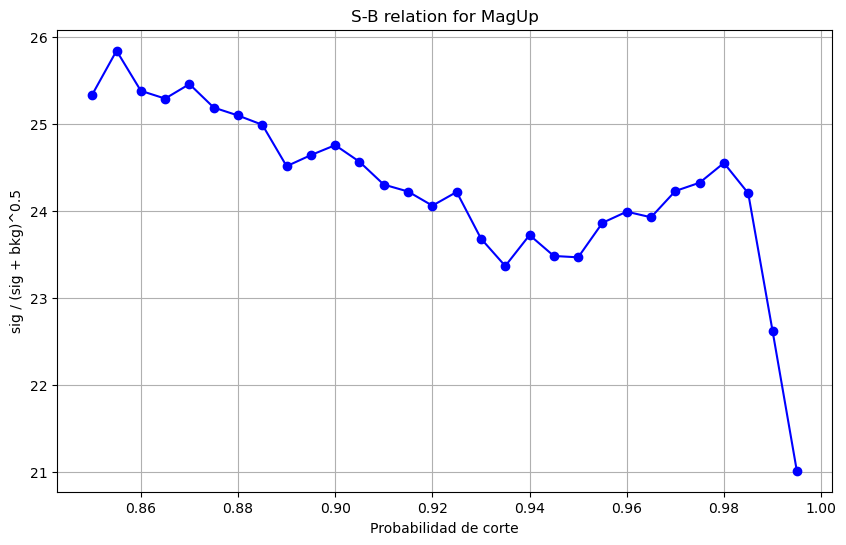

[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (signal,background)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (signal,background)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: 

In [53]:

import ROOT
import pandas as pd
import matplotlib.pyplot as plt

# Define el rango de probabilidad para evaluar
# Define el rango de probabilidad para evaluar
prob_start = 0.85
prob_end = 0.995
prob_step = 0.005  # Paso entre los valores de probabilidad

# Genera los valores de probabilidad dentro del rango definido
prob_values = np.arange(prob_start, prob_end, prob_step)  # Puedes ajustar estos valores según sea necesario

# Listas para almacenar los valores de probabilidad y los correspondientes valores de la expresión
prob_list = []
sig_bkg_ratio_list = []

# Variables para almacenar el valor máximo y la probabilidad correspondiente
max_sig_bkg_ratio = -1
best_prob = None

# Itera sobre diferentes valores de 'prob'
for prob_threshold in prob_values:
    # Filtra los datos según el valor actual de 'prob'
    filtered_mass = data24_magup.loc[
        (data24_magup['prob'] > prob_threshold), 
        'Lb_MASS'
    ]

    # Convierte la Serie de pandas filtrada a un RooDataSet
    x = ROOT.RooRealVar('x', 'x', 5000, 6500)
    data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
    for mass in filtered_mass:
        x.setVal(mass)
        data_list.add(ROOT.RooArgSet(x))

    # Define los parámetros para la señal
    sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 5600, 5500, 5650)
    sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 120, 100, 300)

    # Construye el modelo de señal Gaussiano
    signalModel = ROOT.RooGaussian('signal', 'signal', x, sigmean, sigwidth)

    # Define el parámetro para el fondo exponencial
    lambda_bg = ROOT.RooRealVar('lambda_bg', 'slope', -0.001, -1.0, 0.0)

    # Construye el modelo de fondo exponencial
    background = ROOT.RooExponential('background', 'background', x, lambda_bg)

    # Construye un modelo combinado de señal y fondo
    nsig = ROOT.RooRealVar('nsig', 'nsig', 1000, 100., 20000)
    nbkg = ROOT.RooRealVar('nbkg', 'nbkg', 400, 100., 60000)
    model = ROOT.RooAddPdf('model', 'model', ROOT.RooArgList(signalModel, background), ROOT.RooArgList(nsig, nbkg))

    # Realiza el ajuste total
    total_fit_result = model.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

    # Calcula la expresión sig / (sig + bkg)^0.5
    sig_value = nsig.getVal()
    bkg_value = nbkg.getVal()
    sig_bkg_ratio = sig_value / ((sig_value + bkg_value)**0.5)

    # Almacena los valores en las listas
    prob_list.append(prob_threshold)
    sig_bkg_ratio_list.append(sig_bkg_ratio)

    if sig_bkg_ratio > max_sig_bkg_ratio:
        max_sig_bkg_ratio = sig_bkg_ratio
        best_prob = prob_threshold

# Imprime el valor máximo y la probabilidad correspondiente
print(f"El valor máximo de sig / (sig + bkg)^0.5 es {max_sig_bkg_ratio} para prob = {best_prob}")

# Graficar los resultados
plt.figure(figsize=(10, 6))
plt.plot(prob_list, sig_bkg_ratio_list, marker='o', linestyle='-', color='b')
plt.xlabel('Probabilidad de corte')
plt.ylabel('sig / (sig + bkg)^0.5')
plt.title('S-B relation for MagUp')
plt.grid(True)
plt.show()


the value of prob:  0.0
the ratio signal:  0.5727991185259154
the ratio background:  0.3138515674851438
signal yield:  199999.99999538762
bkg yield:  599999.9999956173
signal yield rescaled:  114559.8237025411
bkg rescaled 188310.94048971077
the value of prob:  0.05
the ratio signal:  0.5738451328704287
the ratio background:  0.3334384339233692
signal yield:  16497.012881678707
bkg yield:  118093.46312528524
signal yield rescaled:  9466.730549052092
bkg rescaled 39376.89940108226
the value of prob:  0.1
the ratio signal:  0.5732597998220396
the ratio background:  0.3344573290217996
signal yield:  14291.461197510458
bkg yield:  90968.51229229102
signal yield rescaled:  8192.72018524929
bkg rescaled 30425.0856463664
the value of prob:  0.15000000000000002
the ratio signal:  0.6139832821611841
the ratio background:  0.3353267826652439
signal yield:  11338.25491251782
bkg yield:  78803.3747570226
signal yield rescaled:  6961.498965167861
bkg rescaled 26424.882120435883
the value of prob:  

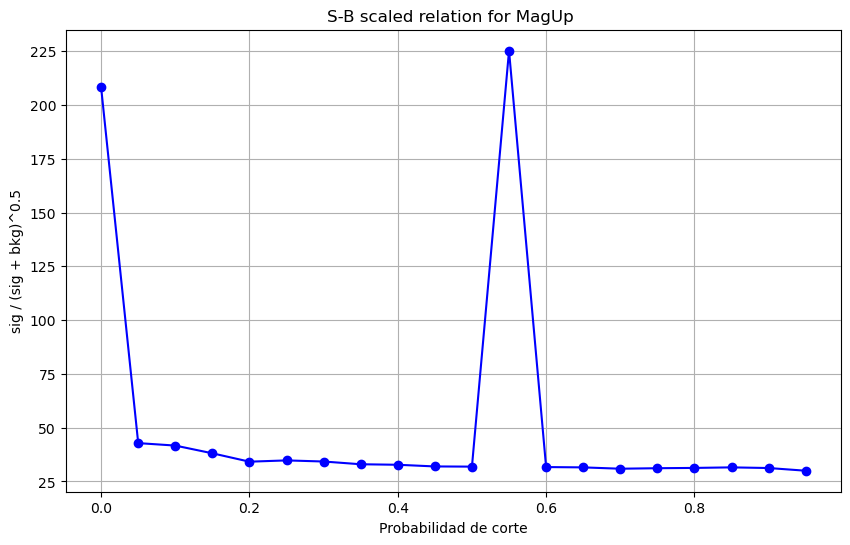

[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (signal,background)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Eval -- RooRealVar::setRange(x) new range named 'signalRegion' created with bounds [5300,5750]
[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (signal,background)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Eval -- RooRealVar::setRange(x) new range named 'signalRe

In [12]:
import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define el rango de probabilidad para evaluar
prob_start = 0.0
prob_end = 0.995
prob_step = 0.05  # Paso entre los valores de probabilidad

# Genera los valores de probabilidad dentro del rango definido
prob_values = np.arange(prob_start, prob_end, prob_step)

# Listas para almacenar los valores de probabilidad y los correspondientes valores de la expresión
prob_list = []
sig_bkg_ratio_list = []

# Variables para almacenar el valor máximo y la probabilidad correspondiente
max_sig_bkg_ratio = -1
best_prob = None

# Itera sobre diferentes valores de 'prob'
for prob_threshold in prob_values:
    # Filtra los datos según el valor actual de 'prob'
    filtered_mass = data24_magup.loc[
        (data24_magup['prob'] > prob_threshold), 
        'Lb_MASS'
    ]

    # Convierte la Serie de pandas filtrada a un RooDataSet
    x = ROOT.RooRealVar('x', 'x', 5000, 6500)
    data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
    for mass in filtered_mass:
        x.setVal(mass)
        data_list.add(ROOT.RooArgSet(x))

    # Define los parámetros para la señal
    sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 5600, 5500, 5650)
    sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 120, 100, 300)

    # Construye el modelo de señal Gaussiano
    signalModel = ROOT.RooGaussian('signal', 'signal', x, sigmean, sigwidth)

    # Define el parámetro para el fondo exponencial
    lambda_bg = ROOT.RooRealVar('lambda_bg', 'slope', -0.001, -1.0, 0.0)

    # Construye el modelo de fondo exponencial
    background = ROOT.RooExponential('background', 'background', x, lambda_bg)

    # Construye un modelo combinado de señal y fondo
    nsig = ROOT.RooRealVar('nsig', 'nsig', 1000, 100., 200000)
    nbkg = ROOT.RooRealVar('nbkg', 'nbkg', 400, 100., 600000)
    model = ROOT.RooAddPdf('model', 'model', ROOT.RooArgList(signalModel, background), ROOT.RooArgList(nsig, nbkg))

    # Realiza el ajuste total
    total_fit_result = model.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

    # Crear un nuevo intervalo para la integración en la región de 5300-5750 MeV
    x.setRange("signalRegion", 5300, 5750)
    
    # Integra el componente de la señal y el fondo en la región de 5300-5750 MeV
    integral_signal_region = signalModel.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("signalRegion"))
    integral_full_range = signalModel.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("full"))
    
    ratio_signal = integral_signal_region.getVal() / integral_full_range.getVal()
    S_rescaled = nsig.getVal() * ratio_signal
    signal = nsig.getVal()
    
    # Integra el componente de fondo en la región de 5300-5750 MeV
    integral_bkg_region = background.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("signalRegion"))
    integral_bkg_full_range = background.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("full"))
    
    ratio_bkg = integral_bkg_region.getVal() / integral_bkg_full_range.getVal()
    B_rescaled = nbkg.getVal() * ratio_bkg
    bkg = nbkg.getVal() 
    
    # Calcula la nueva relación S_rescaled / sqrt(S_rescaled + B_rescaled)
    sig_bkg_ratio = S_rescaled / np.sqrt(S_rescaled + B_rescaled)
    
    # Almacena los valores en las listas
    prob_list.append(prob_threshold)
    sig_bkg_ratio_list.append(sig_bkg_ratio)

    print('the value of prob: ', prob_threshold)
    print("the ratio signal: ", ratio_signal)
    print("the ratio background: ", ratio_bkg)
    print('signal yield: ', signal)
    print('bkg yield: ', bkg)
    print('signal yield rescaled: ', S_rescaled)
    print('bkg rescaled', B_rescaled)
    
    
    if sig_bkg_ratio > max_sig_bkg_ratio:
        max_sig_bkg_ratio = sig_bkg_ratio
        best_prob = prob_threshold

# Imprime el valor máximo y la probabilidad correspondiente
print(f"El valor máximo de sig / (sig + bkg)^0.5 es {max_sig_bkg_ratio} para prob = {best_prob}")

# Graficar los resultados
plt.figure(figsize=(10, 6))
plt.plot(prob_list, sig_bkg_ratio_list, marker='o', linestyle='-', color='b')
plt.xlabel('Probabilidad de corte')
plt.ylabel('sig / (sig + bkg)^0.5')
plt.title('S-B scaled relation for MagUp ')
plt.grid(True)
plt.show()


the value of prob:  0.5
the ratio signal:  0.7364578103708682
the ratio background:  0.338864900072058
signal yield:  5934.335859435994
bkg yield:  42463.7782933361
signal yield rescaled:  4370.387993045557
bkg rescaled 14389.483988053364

the value of prob:  0.9500000000000004
the ratio signal:  0.8500923353290627
the ratio background:  0.34347612905867875
signal yield:  2824.95945022634
bkg yield:  11662.051628097059
signal yield rescaled:  2401.476376252814
bkg rescaled 4005.63635010124

El valor máximo de sig / (sig + bkg)^0.5 es 27.798045849658198 para prob = 0.93


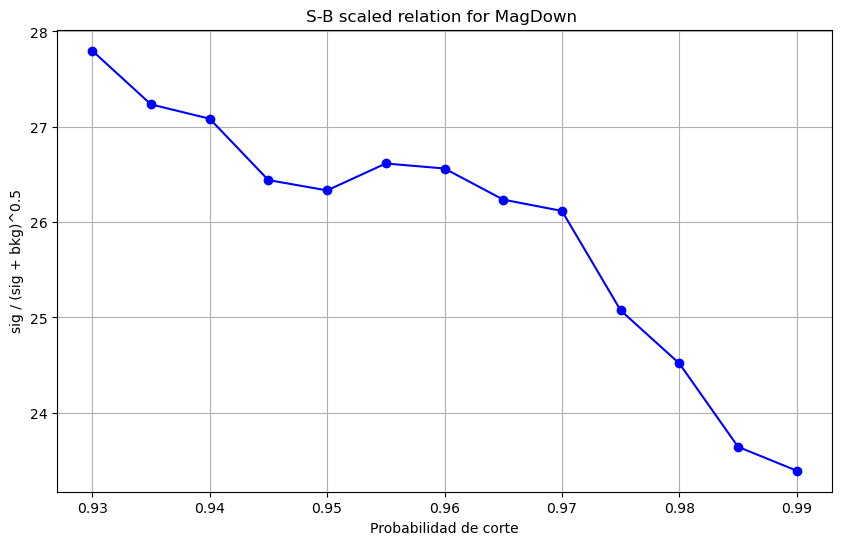

[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (signal,background)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Eval -- RooRealVar::setRange(x) new range named 'signalRegion' created with bounds [5300,5750]
[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (signal,background)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Eval -- RooRealVar::setRange(x) new range named 'signalRe

In [68]:
import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define el rango de probabilidad para evaluar
prob_start = 0.93
prob_end = 0.995
prob_step = 0.005  # Paso entre los valores de probabilidad

# Genera los valores de probabilidad dentro del rango definido
prob_values = np.arange(prob_start, prob_end, prob_step)

# Listas para almacenar los valores de probabilidad y los correspondientes valores de la expresión
prob_list = []
sig_bkg_ratio_list = []

# Variables para almacenar el valor máximo y la probabilidad correspondiente
max_sig_bkg_ratio = -1
best_prob = None

# Itera sobre diferentes valores de 'prob'
for prob_threshold in prob_values:
    # Filtra los datos según el valor actual de 'prob'
    filtered_mass = data24_magdown.loc[
        (data24_magdown['prob'] > prob_threshold), 
        'Lb_MASS'
    ]

    # Convierte la Serie de pandas filtrada a un RooDataSet
    x = ROOT.RooRealVar('x', 'x', 5000, 6500)
    data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
    for mass in filtered_mass:
        x.setVal(mass)
        data_list.add(ROOT.RooArgSet(x))

    # Define los parámetros para la señal
    sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 5600, 5500, 5650)
    sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 120, 100, 300)

    # Construye el modelo de señal Gaussiano
    signalModel = ROOT.RooGaussian('signal', 'signal', x, sigmean, sigwidth)

    # Define el parámetro para el fondo exponencial
    lambda_bg = ROOT.RooRealVar('lambda_bg', 'slope', -0.001, -1.0, 0.0)

    # Construye el modelo de fondo exponencial
    background = ROOT.RooExponential('background', 'background', x, lambda_bg)

    # Construye un modelo combinado de señal y fondo
    nsig = ROOT.RooRealVar('nsig', 'nsig', 1000, 100., 20000)
    nbkg = ROOT.RooRealVar('nbkg', 'nbkg', 400, 100., 40000)
    model = ROOT.RooAddPdf('model', 'model', ROOT.RooArgList(signalModel, background), ROOT.RooArgList(nsig, nbkg))

    # Realiza el ajuste total
    total_fit_result = model.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

    # Crear un nuevo intervalo para la integración en la región de 5300-5750 MeV
    x.setRange("signalRegion", 5300, 5750)
    
    # Integra el componente de la señal y el fondo en la región de 5300-5750 MeV
    integral_signal_region = signalModel.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("signalRegion"))
    integral_full_range = signalModel.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("full"))
    
    ratio_signal = integral_signal_region.getVal() / integral_full_range.getVal()
    S_rescaled = nsig.getVal() * ratio_signal
    
    # Integra el componente de fondo en la región de 5300-5750 MeV
    integral_bkg_region = background.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("signalRegion"))
    integral_bkg_full_range = background.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("full"))
    
    ratio_bkg = integral_bkg_region.getVal() / integral_bkg_full_range.getVal()
    B_rescaled = nbkg.getVal() * ratio_bkg
    
    # Calcula la nueva relación S_rescaled / sqrt(S_rescaled + B_rescaled)
    sig_bkg_ratio = S_rescaled / np.sqrt(S_rescaled + B_rescaled)
    
    # Almacena los valores en las listas
    prob_list.append(prob_threshold)
    sig_bkg_ratio_list.append(sig_bkg_ratio)
    
    if sig_bkg_ratio > max_sig_bkg_ratio:
        max_sig_bkg_ratio = sig_bkg_ratio
        best_prob = prob_threshold

# Imprime el valor máximo y la probabilidad correspondiente
print(f"El valor máximo de sig / (sig + bkg)^0.5 es {max_sig_bkg_ratio} para prob = {best_prob}")

# Graficar los resultados
plt.figure(figsize=(10, 6))
plt.plot(prob_list, sig_bkg_ratio_list, marker='o', linestyle='-', color='b')
plt.xlabel('Probabilidad de corte')
plt.ylabel('sig / (sig + bkg)^0.5')
plt.title('S-B scaled relation for MagDown ')
plt.grid(True)
plt.show()


El valor máximo de sig / (sig + bkg)^0.5 es 24.245688598852283 para prob = 0.93


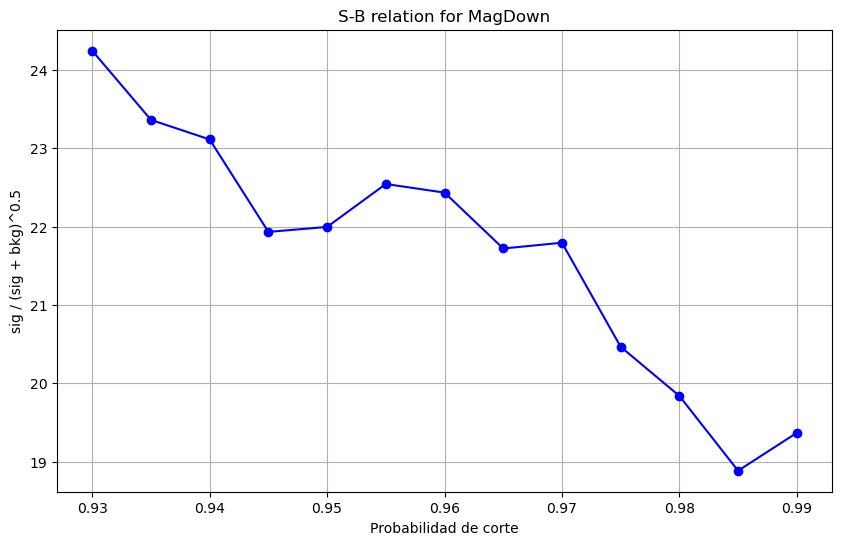

[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (signal,background)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (signal,background)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: 

In [70]:

import ROOT
import pandas as pd
import matplotlib.pyplot as plt

# Define el rango de probabilidad para evaluar
# Define el rango de probabilidad para evaluar
prob_start = 0.93
prob_end = 0.995
prob_step = 0.005 # Paso entre los valores de probabilidad

# Genera los valores de probabilidad dentro del rango definido
prob_values = np.arange(prob_start, prob_end, prob_step)  # Puedes ajustar estos valores según sea necesario

# Listas para almacenar los valores de probabilidad y los correspondientes valores de la expresión
prob_list = []
sig_bkg_ratio_list = []

# Variables para almacenar el valor máximo y la probabilidad correspondiente
max_sig_bkg_ratio = -1
best_prob = None

# Itera sobre diferentes valores de 'prob'
for prob_threshold in prob_values:
    # Filtra los datos según el valor actual de 'prob'
    filtered_mass = data24_magdown.loc[
        (data24_magdown['prob'] > prob_threshold), 
        'Lb_MASS'
    ]

    # Convierte la Serie de pandas filtrada a un RooDataSet
    x = ROOT.RooRealVar('x', 'x', 5000, 6500)
    data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
    for mass in filtered_mass:
        x.setVal(mass)
        data_list.add(ROOT.RooArgSet(x))

    # Define los parámetros para la señal
    sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 5600, 5500, 5650)
    sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 120, 100, 300)

    # Construye el modelo de señal Gaussiano
    signalModel = ROOT.RooGaussian('signal', 'signal', x, sigmean, sigwidth)

    # Define el parámetro para el fondo exponencial
    lambda_bg = ROOT.RooRealVar('lambda_bg', 'slope', -0.001, -1.0, 0.0)

    # Construye el modelo de fondo exponencial
    background = ROOT.RooExponential('background', 'background', x, lambda_bg)

    # Construye un modelo combinado de señal y fondo
    nsig = ROOT.RooRealVar('nsig', 'nsig', 1000, 100., 20000)
    nbkg = ROOT.RooRealVar('nbkg', 'nbkg', 400, 100., 40000)
    model = ROOT.RooAddPdf('model', 'model', ROOT.RooArgList(signalModel, background), ROOT.RooArgList(nsig, nbkg))

    # Realiza el ajuste total
    total_fit_result = model.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

    # Calcula la expresión sig / (sig + bkg)^0.5
    sig_value = nsig.getVal()
    bkg_value = nbkg.getVal()
    sig_bkg_ratio = sig_value / ((sig_value + bkg_value)**0.5)

    # Almacena los valores en las listas
    prob_list.append(prob_threshold)
    sig_bkg_ratio_list.append(sig_bkg_ratio)

    # Compara para encontrar el valor máximo
    if sig_bkg_ratio > max_sig_bkg_ratio:
        max_sig_bkg_ratio = sig_bkg_ratio
        best_prob = prob_threshold

# Imprime el valor máximo y la probabilidad correspondiente
print(f"El valor máximo de sig / (sig + bkg)^0.5 es {max_sig_bkg_ratio} para prob = {best_prob}")

# Graficar los resultados
plt.figure(figsize=(10, 6))
plt.plot(prob_list, sig_bkg_ratio_list, marker='o', linestyle='-', color='b')
plt.xlabel('Probabilidad de corte')
plt.ylabel('sig / (sig + bkg)^0.5')
plt.title('S-B relation for MagDown')
plt.grid(True)
plt.show()


El valor máximo de sig / (sig + bkg)^0.5 es 33.260655910800274 para prob = 0.81
Los valores de sig / (sig + bkg)^0.5: [33.260655910800274, 29.603007843710426, 25.7828285618313, 25.753795515108063, 25.166009984539812, 24.972625809595694, 24.791267199266585, 24.08960728505316, 25.22985729706955, 25.331693336781417, 24.17225300855436, 24.12757881498231, 24.2546139595517, 23.104889142334553, 21.99600950807714, 22.440493172477396, 21.792497032292903, 19.837608595837953, 19.367584496341205] para prob: [0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]


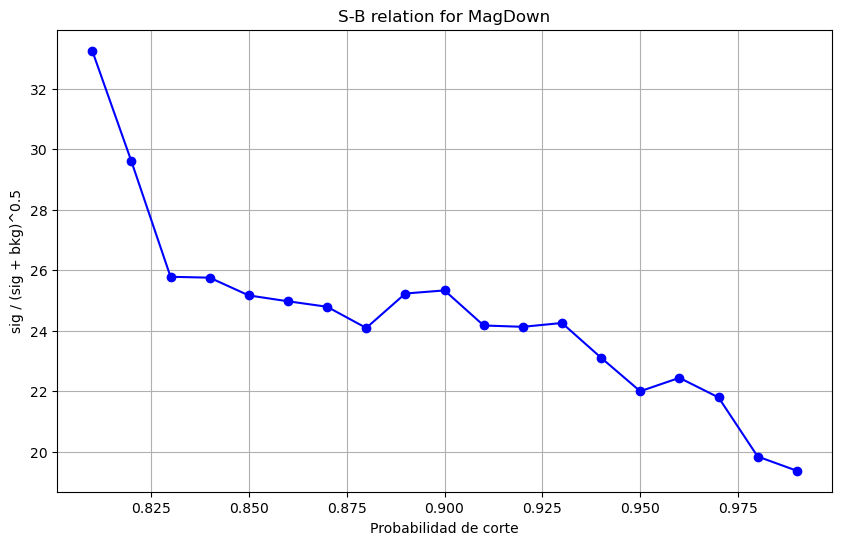

[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (signal,background)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (signal,background)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: 

In [36]:

import ROOT
import pandas as pd
import matplotlib.pyplot as plt

# Define el rango de probabilidad para evaluar
# Define el rango de probabilidad para evaluar
prob_start = 0.1
prob_end = 0.99
prob_step = 0.01 # Paso entre los valores de probabilidad

# Genera los valores de probabilidad dentro del rango definido
# prob_values = np.arange(prob_start, prob_end, prob_step) 
prob_values = [0.81, 0.82,0.83,0.84,0.85,0.86,0.87,0.88,0.89,0.90,0.91,0.92,0.93,0.94,0.95,0.96,0.97,0.98,0.99]
# Listas para almacenar los valores de probabilidad y los correspondientes valores de la expresión
prob_list = []
sig_bkg_ratio_list = []

# Variables para almacenar el valor máximo y la probabilidad correspondiente
max_sig_bkg_ratio = -1
best_prob = None

# Itera sobre diferentes valores de 'prob'
for prob_threshold in prob_values:
    # Filtra los datos según el valor actual de 'prob'
    filtered_mass = data24_magdown.loc[
        (data24_magdown['prob'] > prob_threshold), 
        'Lb_MASS'
    ]

    # Convierte la Serie de pandas filtrada a un RooDataSet
    x = ROOT.RooRealVar('x', 'x', 5000, 6500)
    data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
    for mass in filtered_mass:
        x.setVal(mass)
        data_list.add(ROOT.RooArgSet(x))

    # Define los parámetros para la señal
    sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 5600, 5500, 5650)
    sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 120, 100, 300)

    # Construye el modelo de señal Gaussiano
    signalModel = ROOT.RooGaussian('signal', 'signal', x, sigmean, sigwidth)

    # Define el parámetro para el fondo exponencial
    lambda_bg = ROOT.RooRealVar('lambda_bg', 'slope', -0.001, -1.0, 0.0)

    # Construye el modelo de fondo exponencial
    background = ROOT.RooExponential('background', 'background', x, lambda_bg)

    # Construye un modelo combinado de señal y fondo
    nsig = ROOT.RooRealVar('nsig', 'nsig', 1000, 100., 20000)
    nbkg = ROOT.RooRealVar('nbkg', 'nbkg', 400, 100., 20000)
    model = ROOT.RooAddPdf('model', 'model', ROOT.RooArgList(signalModel, background), ROOT.RooArgList(nsig, nbkg))

    # Realiza el ajuste total
    total_fit_result = model.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

    # Calcula la expresión sig / (sig + bkg)^0.5
    sig_value = nsig.getVal()
    bkg_value = nbkg.getVal()
    sig_bkg_ratio = sig_value / ((sig_value + bkg_value)**0.5)

    # Almacena los valores en las listas
    prob_list.append(prob_threshold)
    sig_bkg_ratio_list.append(sig_bkg_ratio)

    # Compara para encontrar el valor máximo
    if sig_bkg_ratio > max_sig_bkg_ratio:
        max_sig_bkg_ratio = sig_bkg_ratio
        best_prob = prob_threshold

# Imprime el valor máximo y la probabilidad correspondiente
print(f"El valor máximo de sig / (sig + bkg)^0.5 es {max_sig_bkg_ratio} para prob = {best_prob}")
print(f"Los valores de sig / (sig + bkg)^0.5: {sig_bkg_ratio_list} para prob: {prob_list}" )

# Graficar los resultados
plt.figure(figsize=(10, 6))
plt.plot(prob_list, sig_bkg_ratio_list, marker='o', linestyle='-', color='b')
plt.xlabel('Probabilidad de corte')
plt.ylabel('sig / (sig + bkg)^0.5')
plt.title('S-B relation for MagDown')
plt.grid(True)
plt.show()


[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (signal,background)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization

  RooFitResult: minimized FCN value: 96831.6, estimated distance to minimum: 3.90567e-07
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESS

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas


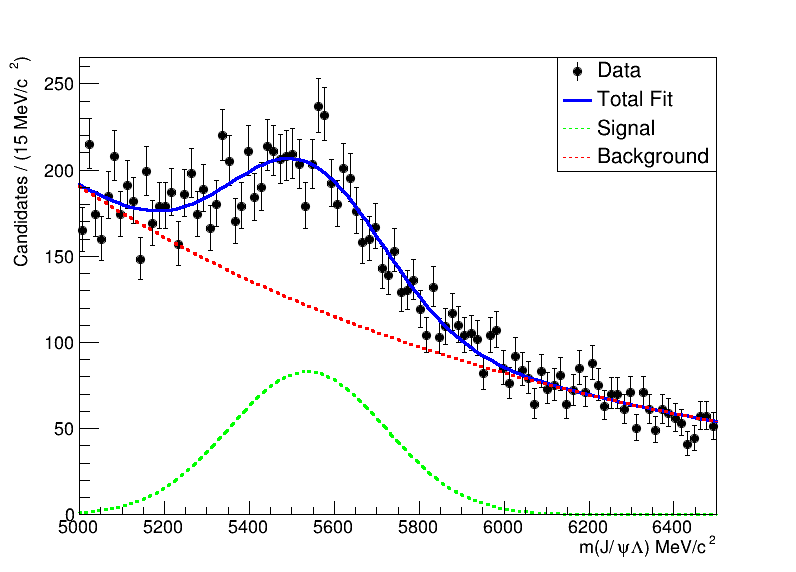

In [38]:
import ROOT
import pandas as pd

# Filtra los datos según las condiciones especificadas  abs(data24_magup['alpha_combined']) > 0.45) & 
filtered_mass = data24_magdown.loc[
    (data24_magdown['prob'] > 0.95), 
    'Lb_MASS'
]

# Convierte la Serie de pandas filtrada a un RooDataSet
x = ROOT.RooRealVar('x', 'x', 5000, 6500)
data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
for mass in filtered_mass:
    x.setVal(mass)
    data_list.add(ROOT.RooArgSet(x))

# Define los parámetros para la señal
sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 5600, 5500, 5650)
sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 120, 100, 300)

# Construye el modelo de señal Gaussiano
signalModel = ROOT.RooGaussian('signal', 'signal', x, sigmean, sigwidth)

# Define el parámetro para el fondo exponencial
lambda_bg = ROOT.RooRealVar('lambda_bg', 'slope', -0.001, -1.0, 0.0)

# Construye el modelo de fondo exponencial
background = ROOT.RooExponential('background', 'background', x, lambda_bg)

# Realiza el ajuste del fondo
background_fit_result = background.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Realiza el ajuste de la señal
signal_fit_result = signalModel.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Construye un modelo combinado de señal y fondo
nsig = ROOT.RooRealVar('nsig', 'nsig', 1000, 100., 20000)
nbkg = ROOT.RooRealVar('nbkg', 'nbkg', 400, 100., 20000)
model = ROOT.RooAddPdf('model', 'model', ROOT.RooArgList(signalModel, background), ROOT.RooArgList(nsig, nbkg))

# Realiza el ajuste total
total_fit_result = model.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Imprime los resultados del ajuste
background_fit_result.Print()
signal_fit_result.Print()
total_fit_result.Print()

# Crea un RooPlot para dibujar
xframe = x.frame()

# Dibuja los datos y el modelo combinado
data_list.plotOn(xframe)
model.plotOn(xframe)
model.plotOn(xframe, ROOT.RooFit.Components('background'), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kRed))
model.plotOn(xframe, ROOT.RooFit.Components('signal'), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kGreen))

# Configura los títulos de los ejes
xframe.SetTitle("")
xframe.SetXTitle("m(J/#psi#Lambda) MeV/c^{2}")
xframe.SetYTitle("Candidates / (15 MeV/c^{2})")

# Crea una leyenda
legend = ROOT.TLegend(0.7, 0.7, 0.9, 0.9)

# Ajusta el estilo de los puntos de la leyenda a círculos
data_marker = ROOT.TMarker()
data_marker.SetMarkerStyle(ROOT.kFullCircle)
legend.AddEntry(data_marker, "Data", "pe")
legend.AddEntry(xframe.findObject("model_Norm[x]"), "Total Fit", "l")

# Ajusta el estilo de la línea de la leyenda para la señal a verde y discontinua
signal_line = ROOT.TLine()
signal_line.SetLineColor(ROOT.kGreen)
signal_line.SetLineStyle(ROOT.kDashed)
legend.AddEntry(signal_line, "Signal", "l")

# Ajusta el estilo de la línea de la leyenda para el fondo a rojo y discontinua
background_line = ROOT.TLine()
background_line.SetLineColor(ROOT.kRed)
background_line.SetLineStyle(ROOT.kDashed)
legend.AddEntry(background_line, "Background", "l")

# Dibuja el gráfico
canvas = ROOT.TCanvas('canvas', 'Fit Plot', 800, 600)
xframe.Draw()
canvas.Draw()
legend.Draw()

# Opcional: imprime las definiciones para verificar
x.Print()
sigmean.Print()
sigwidth.Print()
lambda_bg.Print()
nsig.Print()
nbkg.Print()
model.Print()


Una vez optimizado el corte, guerdamos en otro .pkl los datos del Magup y magDown de la BDT

In [40]:
import pandas as pd
from catboost import CatBoostClassifier

# Cargar datos
mc_data = pd.read_pickle('mc_data_all.pkl')

# Filtrar los datos según el campo magnético
mc_data_up = mc_data.query('MAGFIELD == True').copy()
mc_data_down = mc_data.query('MAGFIELD == False').copy()

# Cargar modelos y hacer predicciones para "MagUP"
model_up = CatBoostClassifier().load_model("BDT_MagUP_all")
prob_up = model_up.predict_proba(mc_data_up)
mc_data_up['prob'] = [1 - i[0] for i in prob_up]

# Cargar modelos y hacer predicciones para "MagDown"
model_down = CatBoostClassifier().load_model("BDT_MagDown_all")
prob_down = model_down.predict_proba(mc_data_down)
mc_data_down['prob'] = [1 - i[0] for i in prob_down]

# Combinar los resultados
mc_data_combined = pd.concat([mc_data_up[['prob']], mc_data_down[['prob']]])

# Asegurarte de que las probabilidades estén alineadas con el índice original
mc_data['prob'] = mc_data_combined['prob']


/tmp/javeser/ipykernel_24442/2822489246.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_data['prob'] = mc_data_combined['prob']


In [41]:
# Filtrar los datos según los cortes de probabilidad y el campo magnético
mc_data_up_cut = mc_data.query('MAGFIELD == True and prob > 0.96')
mc_data_down_cut = mc_data.query('MAGFIELD == False and prob > 0.90')

# Combinar los datos filtrados
mc_data_filtered = pd.concat([mc_data_up_cut, mc_data_down_cut])

# Guardar el dataframe filtrado en un archivo .pkl
mc_data_filtered.to_pickle('mc_data_BDT.pkl')

print("Datos filtrados guardados en 'mc_data_BDT.pkl'")


Datos filtrados guardados en 'mc_data_BDT.pkl'


In [42]:
data_BDT_up = data24_magup.query('prob > 0.96')
data_BDT_down = data24_magdown.query('prob > 0.90')

data_BDT_up.to_pickle('data_BDT_MagUp.pkl')
data_BDT_down.to_pickle('data_BDT_MagDown.pkl')

In [43]:
# Añadir la columna MAGFIELD a cada dataframe
data_BDT_up['MAGFIELD'] = True
data_BDT_down['MAGFIELD'] = False

# Combinar los dataframes en uno solo
data_BDT_combined = pd.concat([data_BDT_up, data_BDT_down])

# Guardar el dataframe combinado en un archivo .pkl
data_BDT_combined.to_pickle('data_BDT_combined.pkl')

print("Datos combinados guardados en 'data_BDT_combined.pkl'")


Datos combinados guardados en 'data_BDT_combined.pkl'


/tmp/javeser/ipykernel_24442/4286391869.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_BDT_up['MAGFIELD'] = True
/tmp/javeser/ipykernel_24442/4286391869.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_BDT_up['MAGFIELD'] = True
/tmp/javeser/ipykernel_24442/4286391869.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

In [40]:
data_BDT_combined

,L_MASS,Lb_MASS,Jpsi_MASS,Jpsi_P,Jpsi_PT,Jpsi_ETA,Jpsi_CHI2,Jpsi_MAXDOCA,Jpsi_BPVDIRA,Jpsi_END_VRHO,...,p_RK_IP,pim_RK_IP,prob,MAGFIELD,p_TRACK_POS_CLOSESTTOBEAM_X,p_TRACK_POS_CLOSESTTOBEAM_Y,p_TRACK_POS_CLOSESTTOBEAM_Z,pim_TRACK_POS_CLOSESTTOBEAM_X,pim_TRACK_POS_CLOSESTTOBEAM_Y,pim_TRACK_POS_CLOSESTTOBEAM_Z
106,1079.189209,5133.297363,3244.967285,45687.652344,1623.759155,4.029826,0.026939,0.004721,0.998524,1.265356,...,36.107991,446.271698,0.975456,True,NaN,NaN,NaN,NaN,NaN,NaN
127,1079.314697,6468.224609,3097.961670,34075.851562,522.977478,4.869855,3.915475,0.049992,0.999759,1.199482,...,88.221418,572.244167,0.996925,True,NaN,NaN,NaN,NaN,NaN,NaN
163,1079.509399,6444.345703,3105.055420,237897.656250,8667.685547,4.004976,0.121701,0.005257,0.999999,1.185527,...,71.169528,561.471047,0.946239,True,NaN,NaN,NaN,NaN,NaN,NaN
208,1079.698486,5896.769043,3146.238525,255808.734375,6345.003906,4.389720,0.048347,0.004971,0.999991,1.399007,...,56.274249,457.000756,0.999849,True,NaN,NaN,NaN,NaN,NaN,NaN
289,1079.990723,5467.488770,3049.157471,112196.218750,1548.691162,4.975843,0.548271,0.032118,0.999716,1.177331,...,79.203568,541.696061,0.999982,True,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3168553,1699.328369,5826.198242,2999.874756,47753.761719,2921.687744,3.486069,0.040031,0.006429,0.999610,1.261880,...,47.283735,407.176252,0.885234,False,99.8878,-213.2415,7826.0991,208.1136,-205.3015,7826.0991
3168723,1699.363770,5588.363770,3060.744385,50576.226562,5372.594727,2.932401,0.143999,0.015939,0.999560,2.012980,...,17.582071,149.457618,0.969184,False,183.4907,466.4152,7826.0991,-523.1705,484.4175,7826.0991
3168976,1699.412354,5388.648437,3068.843994,93733.171875,2988.947021,4.138386,0.021325,0.003749,0.999957,1.192002,...,1.783413,85.878206,0.934840,False,177.3700,166.8291,7826.0991,-243.7316,209.6342,7826.0996
3169668,1699.554932,6048.369629,3071.131348,93817.492188,2154.676758,4.466723,0.460723,0.025058,0.999889,1.367281,...,73.122588,245.563882,0.953213,False,243.1947,-289.8022,7826.0991,255.0116,-298.8647,7826.0991


Ajuste con crystal Ball

[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (signal,background)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization

  RooFitResult: minimized FCN value: 69371.7, estimated distance to minimum: 1.48028e-06
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESS

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas


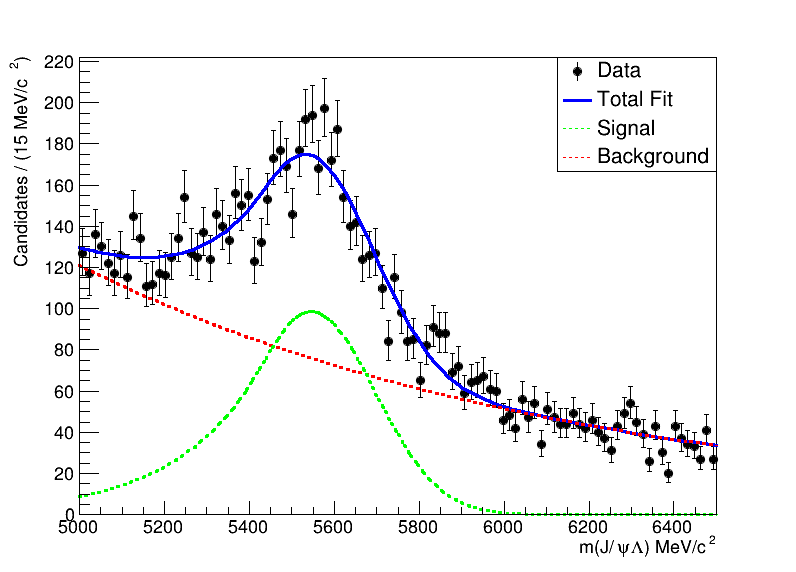

In [89]:
import ROOT
import pandas as pd

# Filtra los datos según las condiciones especificadas
filtered_mass = data24_magup.loc[
    (data24_magup['prob'] > 0.98), 
    'Lb_MASS'
]

# Convierte la Serie de pandas filtrada a un RooDataSet
x = ROOT.RooRealVar('x', 'x', 5000, 6500)
data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
for mass in filtered_mass:
    x.setVal(mass)
    data_list.add(ROOT.RooArgSet(x))

# Define los parámetros para la señal Crystal Ball
sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 5600, 5400, 5800)
sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 120, 100, 300)
alpha = ROOT.RooRealVar('alpha', 'alpha', 1.5, 0.1, 100)  # Parámetro para el límite de la cola
n = ROOT.RooRealVar('n', 'n', 1, 0.1, 100)  # Parámetro de forma de la cola

# Construye el modelo de señal Crystal Ball
signalModel = ROOT.RooCBShape('signal', 'signal', x, sigmean, sigwidth, alpha, n)

# Define el parámetro para el fondo exponencial
lambda_bg = ROOT.RooRealVar('lambda_bg', 'slope', -0.001, -1.0, 0.0)

# Construye el modelo de fondo exponencial
background = ROOT.RooExponential('background', 'background', x, lambda_bg)

# Realiza el ajuste del fondo
background_fit_result = background.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Realiza el ajuste de la señal
signal_fit_result = signalModel.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Construye un modelo combinado de señal y fondo
nsig = ROOT.RooRealVar('nsig', 'nsig', 1000, 100., 20000)
nbkg = ROOT.RooRealVar('nbkg', 'nbkg', 400, 100., 20000)
model = ROOT.RooAddPdf('model', 'model', ROOT.RooArgList(signalModel, background), ROOT.RooArgList(nsig, nbkg))

# Realiza el ajuste total
total_fit_result = model.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Imprime los resultados del ajuste
background_fit_result.Print()
signal_fit_result.Print()
total_fit_result.Print()

# Crea un RooPlot para dibujar
xframe = x.frame()

# Dibuja los datos y el modelo combinado
data_list.plotOn(xframe)
model.plotOn(xframe)
model.plotOn(xframe, ROOT.RooFit.Components('background'), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kRed))
model.plotOn(xframe, ROOT.RooFit.Components('signal'), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kGreen))

# Configura los títulos de los ejes
xframe.SetTitle("")
xframe.SetXTitle("m(J/#psi#Lambda) MeV/c^{2}")
xframe.SetYTitle("Candidates / (15 MeV/c^{2})")

# Crea una leyenda
legend = ROOT.TLegend(0.7, 0.7, 0.9, 0.9)

# Ajusta el estilo de los puntos de la leyenda a círculos
data_marker = ROOT.TMarker()
data_marker.SetMarkerStyle(ROOT.kFullCircle)
legend.AddEntry(data_marker, "Data", "pe")
legend.AddEntry(xframe.findObject("model_Norm[x]"), "Total Fit", "l")

# Ajusta el estilo de la línea de la leyenda para la señal a verde y discontinua
signal_line = ROOT.TLine()
signal_line.SetLineColor(ROOT.kGreen)
signal_line.SetLineStyle(ROOT.kDashed)
legend.AddEntry(signal_line, "Signal", "l")

# Ajusta el estilo de la línea de la leyenda para el fondo a rojo y discontinua
background_line = ROOT.TLine()
background_line.SetLineColor(ROOT.kRed)
background_line.SetLineStyle(ROOT.kDashed)
legend.AddEntry(background_line, "Background", "l")

# Dibuja el gráfico
canvas = ROOT.TCanvas('canvas', 'Fit Plot', 800, 600)
xframe.Draw()
canvas.Draw()
legend.Draw()

# Opcional: imprime las definiciones para verificar
x.Print()
sigmean.Print()
sigwidth.Print()
alpha.Print()
n.Print()
lambda_bg.Print()
nsig.Print()
nbkg.Print()
model.Print()


Doble Crystal Ball

[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (cb_left,cb_right)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (cb_left,cb_right,background)
RooAbsMinimizerFcn: Minimized function has error status.
Returning maximum FCN so far (3512.33) to force MIGRAD to back out of this region. Error log follows.
Parameter values: 

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas


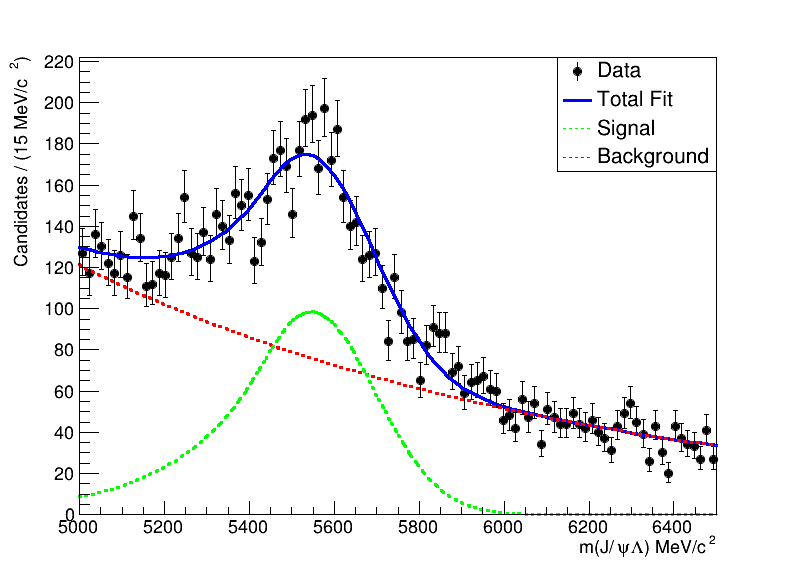

In [97]:
import ROOT
import pandas as pd

# Filtra los datos según las condiciones especificadas
filtered_mass = data24_magup.loc[
    (data24_magup['prob'] > 0.98), 
    'Lb_MASS'
]

# Convierte la Serie de pandas filtrada a un RooDataSet
x = ROOT.RooRealVar('x', 'x', 5000, 6500)
data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
for mass in filtered_mass:
    x.setVal(mass)
    data_list.add(ROOT.RooArgSet(x))

# Define los parámetros para la señal (izquierda y derecha) usando CrystalBallShape
sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 5600, 5500, 5650)
sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 120, 100, 300)

# Parámetros de la cola izquierda
alpha1 = ROOT.RooRealVar('alpha1', 'alpha1', 1.5, 0.5, 50.0)
n1 = ROOT.RooRealVar('n1', 'n1', 2, 0.1, 500)

# Parámetros de la cola derecha
alpha2 = ROOT.RooRealVar('alpha2', 'alpha2', 1.5, 0.5, 50.0)
n2 = ROOT.RooRealVar('n2', 'n2', 2, 0.1, 100)

# Crear dos Crystal Ball: uno para la cola izquierda y otro para la derecha
cb_left = ROOT.RooCBShape('cb_left', 'Crystal Ball Left Tail', x, sigmean, sigwidth, alpha1, n1)
cb_right = ROOT.RooCBShape('cb_right', 'Crystal Ball Right Tail', x, sigmean, sigwidth, alpha2, n2)

# Combina las dos funciones Crystal Ball en un modelo compuesto
frac = ROOT.RooRealVar('frac', 'frac', 0.5, 0.0, 1.0)
signalModel = ROOT.RooAddPdf('signal', 'Double Crystal Ball', cb_left, cb_right, frac)

# Define el parámetro para el fondo exponencial
lambda_bg = ROOT.RooRealVar('lambda_bg', 'slope', -0.001, -1.0, 0.0)

# Construye el modelo de fondo exponencial
background = ROOT.RooExponential('background', 'background', x, lambda_bg)

# Realiza el ajuste del fondo
background_fit_result = background.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Realiza el ajuste de la señal
signal_fit_result = signalModel.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Construye un modelo combinado de señal y fondo
nsig = ROOT.RooRealVar('nsig', 'nsig', 1000, 100., 20000)
nbkg = ROOT.RooRealVar('nbkg', 'nbkg', 400, 100., 20000)
model = ROOT.RooAddPdf('model', 'model', ROOT.RooArgList(signalModel, background), ROOT.RooArgList(nsig, nbkg))

# Realiza el ajuste total
total_fit_result = model.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Imprime los resultados del ajuste
background_fit_result.Print()
signal_fit_result.Print()
total_fit_result.Print()

# Crea un RooPlot para dibujar
xframe = x.frame()

# Dibuja los datos y el modelo combinado
data_list.plotOn(xframe)
model.plotOn(xframe)
model.plotOn(xframe, ROOT.RooFit.Components('background'), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kRed))
model.plotOn(xframe, ROOT.RooFit.Components('signal'), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kGreen))

# Configura los títulos de los ejes
xframe.SetTitle("")
xframe.SetXTitle("m(J/#psi#Lambda) MeV/c^{2}")
xframe.SetYTitle("Candidates / (15 MeV/c^{2})")

# Crea una leyenda
legend = ROOT.TLegend(0.7, 0.7, 0.9, 0.9)

# Ajusta el estilo de los puntos de la leyenda a círculos
data_marker = ROOT.TMarker()
data_marker.SetMarkerStyle(ROOT.kFullCircle)
legend.AddEntry(data_marker, "Data", "pe")
legend.AddEntry(xframe.findObject("model_Norm[x]"), "Total Fit", "l")

# Ajusta el estilo de la línea de la leyenda para la señal a verde y discontinua
signal_line = ROOT.TLine()
signal_line.SetLineColor(ROOT.kGreen)
signal_line.SetLineStyle(ROOT.kDashed)
legend.AddEntry(signal_line, "Signal", "l")

# Ajusta el estilo de la línea de la leyenda para el fondo a rojo y discontinua
background_line = ROOT.TLine()
background_line.SetLineColor(ROOT.kRed)
background_line.SetLineStyle(ROOT.kDashed)
legend.AddEntry(background_line, "Background", "l")

# Dibuja el gráfico
canvas = ROOT.TCanvas('canvas', 'Fit Plot', 800, 600)
xframe.Draw()
canvas.Draw()
legend.Draw()

# Opcional: imprime las definiciones para verificar
x.Print()
sigmean.Print()
sigwidth.Print()
alpha1.Print()
n1.Print()
alpha2.Print()
n2.Print()
lambda_bg.Print()
nsig.Print()
nbkg.Print()
model.Print()


El valor máximo de sig / (sig + bkg)^0.5 es 33.12472010307162 para prob = 0.855


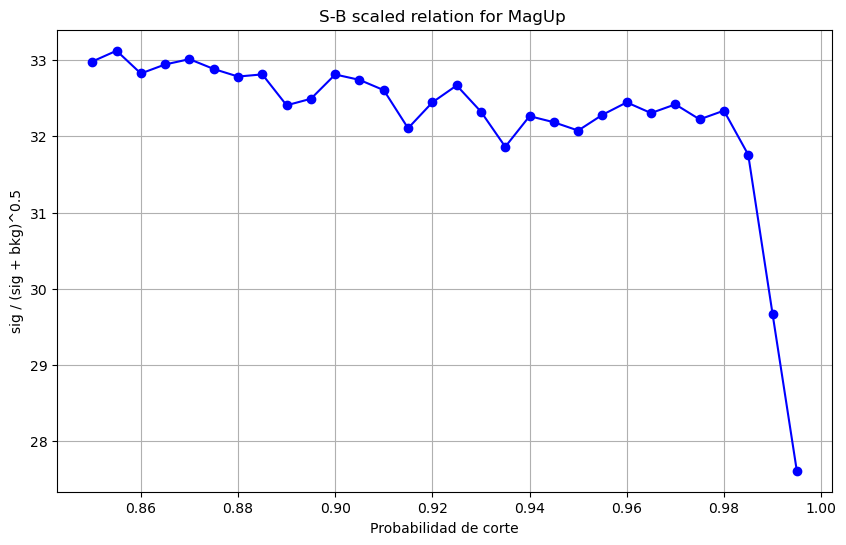

[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (cb_left,cb_right,background)
RooAbsMinimizerFcn: Minimized function has error status.
Returning maximum FCN so far (8296.17) to force MIGRAD to back out of this region. Error log follows.
Parameter values: 	alpha1=1.0581	alpha2=0.511612	frac=0.992099	lambda_bg=-0.000812866	n1=23.3095	n2=157.784	nbkg=20004.6	nsig=4339.56	sigmean=5537.22	sigwidth=174.279
RooNLLVar::nll_model_data[ parameters=(alpha1,alpha2,frac,lambda_bg,n1,n2,nbkg,nsig,sigmean,sigwidth) ]
     function value is NAN @ parameters=(alpha1 = 1.0581,alpha2 = 0.511612,frac = 0.992099,lambda_bg = -0.000812866,n1 = 23.3095,n2 = 157.784,nbkg = 20004.6,nsig = 4339.56,sigmean = 5537.22,sigwidth = 174.279)
RooAddPdf::model[ nsig * signal 

In [99]:
import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define el rango de probabilidad para evaluar
prob_start = 0.85
prob_end = 0.995
prob_step = 0.005  # Paso entre los valores de probabilidad

# Genera los valores de probabilidad dentro del rango definido
prob_values = np.arange(prob_start, prob_end, prob_step)

# Listas para almacenar los valores de probabilidad y los correspondientes valores de la expresión
prob_list = []
sig_bkg_ratio_list = []

# Variables para almacenar el valor máximo y la probabilidad correspondiente
max_sig_bkg_ratio = -1
best_prob = None

# Itera sobre diferentes valores de 'prob'
for prob_threshold in prob_values:
    # Filtra los datos según el valor actual de 'prob'
    filtered_mass = data24_magup.loc[
        (data24_magup['prob'] > prob_threshold), 
        'Lb_MASS'
    ]

    # Convierte la Serie de pandas filtrada a un RooDataSet
    x = ROOT.RooRealVar('x', 'x', 5000, 6500)
    data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
    for mass in filtered_mass:
        x.setVal(mass)
        data_list.add(ROOT.RooArgSet(x))

    # Define los parámetros para la señal Double Crystal Ball
    sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 5600, 5500, 5650)
    sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 120, 100, 300)
    
    # Parámetros de la cola izquierda
    alpha1 = ROOT.RooRealVar('alpha1', 'alpha1', 1.5, 0.5, 50.0)
    n1 = ROOT.RooRealVar('n1', 'n1', 2, 0.1, 500)
    
    # Parámetros de la cola derecha
    alpha2 = ROOT.RooRealVar('alpha2', 'alpha2', 1.5, 0.5, 50.0)
    n2 = ROOT.RooRealVar('n2', 'n2', 2, 0.1, 500)
    
    # Crear dos Crystal Ball: uno para la cola izquierda y otro para la derecha
    cb_left = ROOT.RooCBShape('cb_left', 'Crystal Ball Left Tail', x, sigmean, sigwidth, alpha1, n1)
    cb_right = ROOT.RooCBShape('cb_right', 'Crystal Ball Right Tail', x, sigmean, sigwidth, alpha2, n2)
    
    # Combina las dos funciones Crystal Ball en un modelo compuesto
    frac = ROOT.RooRealVar('frac', 'frac', 0.5, 0.0, 1.0)
    signalModel = ROOT.RooAddPdf('signal', 'Double Crystal Ball', cb_left, cb_right, frac)

    # Define el parámetro para el fondo exponencial
    lambda_bg = ROOT.RooRealVar('lambda_bg', 'slope', -0.001, -1.0, 0.0)

    # Construye el modelo de fondo exponencial
    background = ROOT.RooExponential('background', 'background', x, lambda_bg)

    # Construye un modelo combinado de señal y fondo
    nsig = ROOT.RooRealVar('nsig', 'nsig', 1000, 100., 20000)
    nbkg = ROOT.RooRealVar('nbkg', 'nbkg', 400, 100., 60000)
    model = ROOT.RooAddPdf('model', 'model', ROOT.RooArgList(signalModel, background), ROOT.RooArgList(nsig, nbkg))

    # Realiza el ajuste total
    total_fit_result = model.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

    # Crear un nuevo intervalo para la integración en la región de 5300-5750 MeV
    x.setRange("signalRegion", 5300, 5750)
    
    # Integra el componente de la señal y el fondo en la región de 5300-5750 MeV
    integral_signal_region = signalModel.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("signalRegion"))
    integral_full_range = signalModel.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("full"))
    
    ratio_signal = integral_signal_region.getVal() / integral_full_range.getVal()
    S_rescaled = nsig.getVal() * ratio_signal
    
    # Integra el componente de fondo en la región de 5300-5750 MeV
    integral_bkg_region = background.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("signalRegion"))
    integral_bkg_full_range = background.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("full"))
    
    ratio_bkg = integral_bkg_region.getVal() / integral_bkg_full_range.getVal()
    B_rescaled = nbkg.getVal() * ratio_bkg
    
    # Calcula la nueva relación S_rescaled / sqrt(S_rescaled + B_rescaled)
    sig_bkg_ratio = S_rescaled / np.sqrt(S_rescaled + B_rescaled)
    
    # Almacena los valores en las listas
    prob_list.append(prob_threshold)
    sig_bkg_ratio_list.append(sig_bkg_ratio)
    
    if sig_bkg_ratio > max_sig_bkg_ratio:
        max_sig_bkg_ratio = sig_bkg_ratio
        best_prob = prob_threshold

# Imprime el valor máximo y la probabilidad correspondiente
print(f"El valor máximo de sig / (sig + bkg)^0.5 es {max_sig_bkg_ratio} para prob = {best_prob}")

# Graficar los resultados
plt.figure(figsize=(10, 6))
plt.plot(prob_list, sig_bkg_ratio_list, marker='o', linestyle='-', color='b')
plt.xlabel('Probabilidad de corte')
plt.ylabel('sig / (sig + bkg)^0.5')
plt.title('S-B scaled relation for MagUp ')
plt.grid(True)
plt.show()


Doble crystal ball with floating mean dor magup 

El valor máximo de sig / (sig + bkg)^0.5 es 32.44814785538203 para prob = 0.9600000000000001


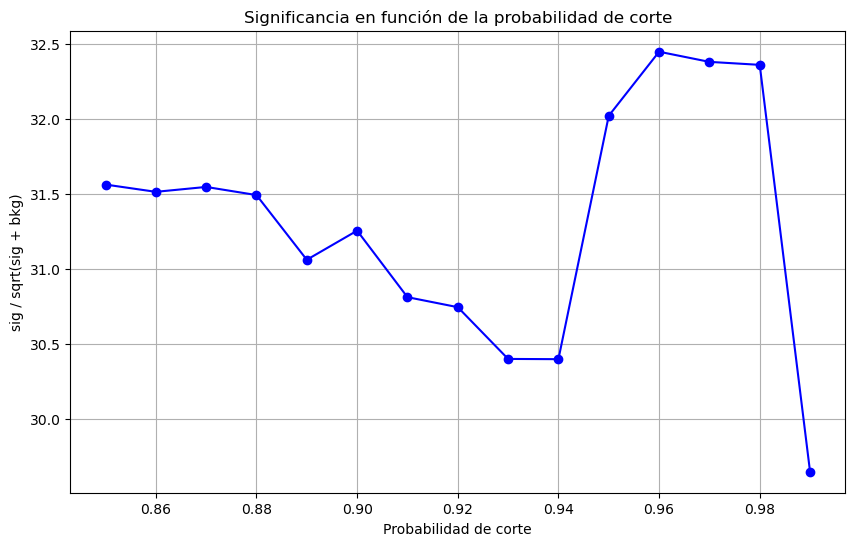

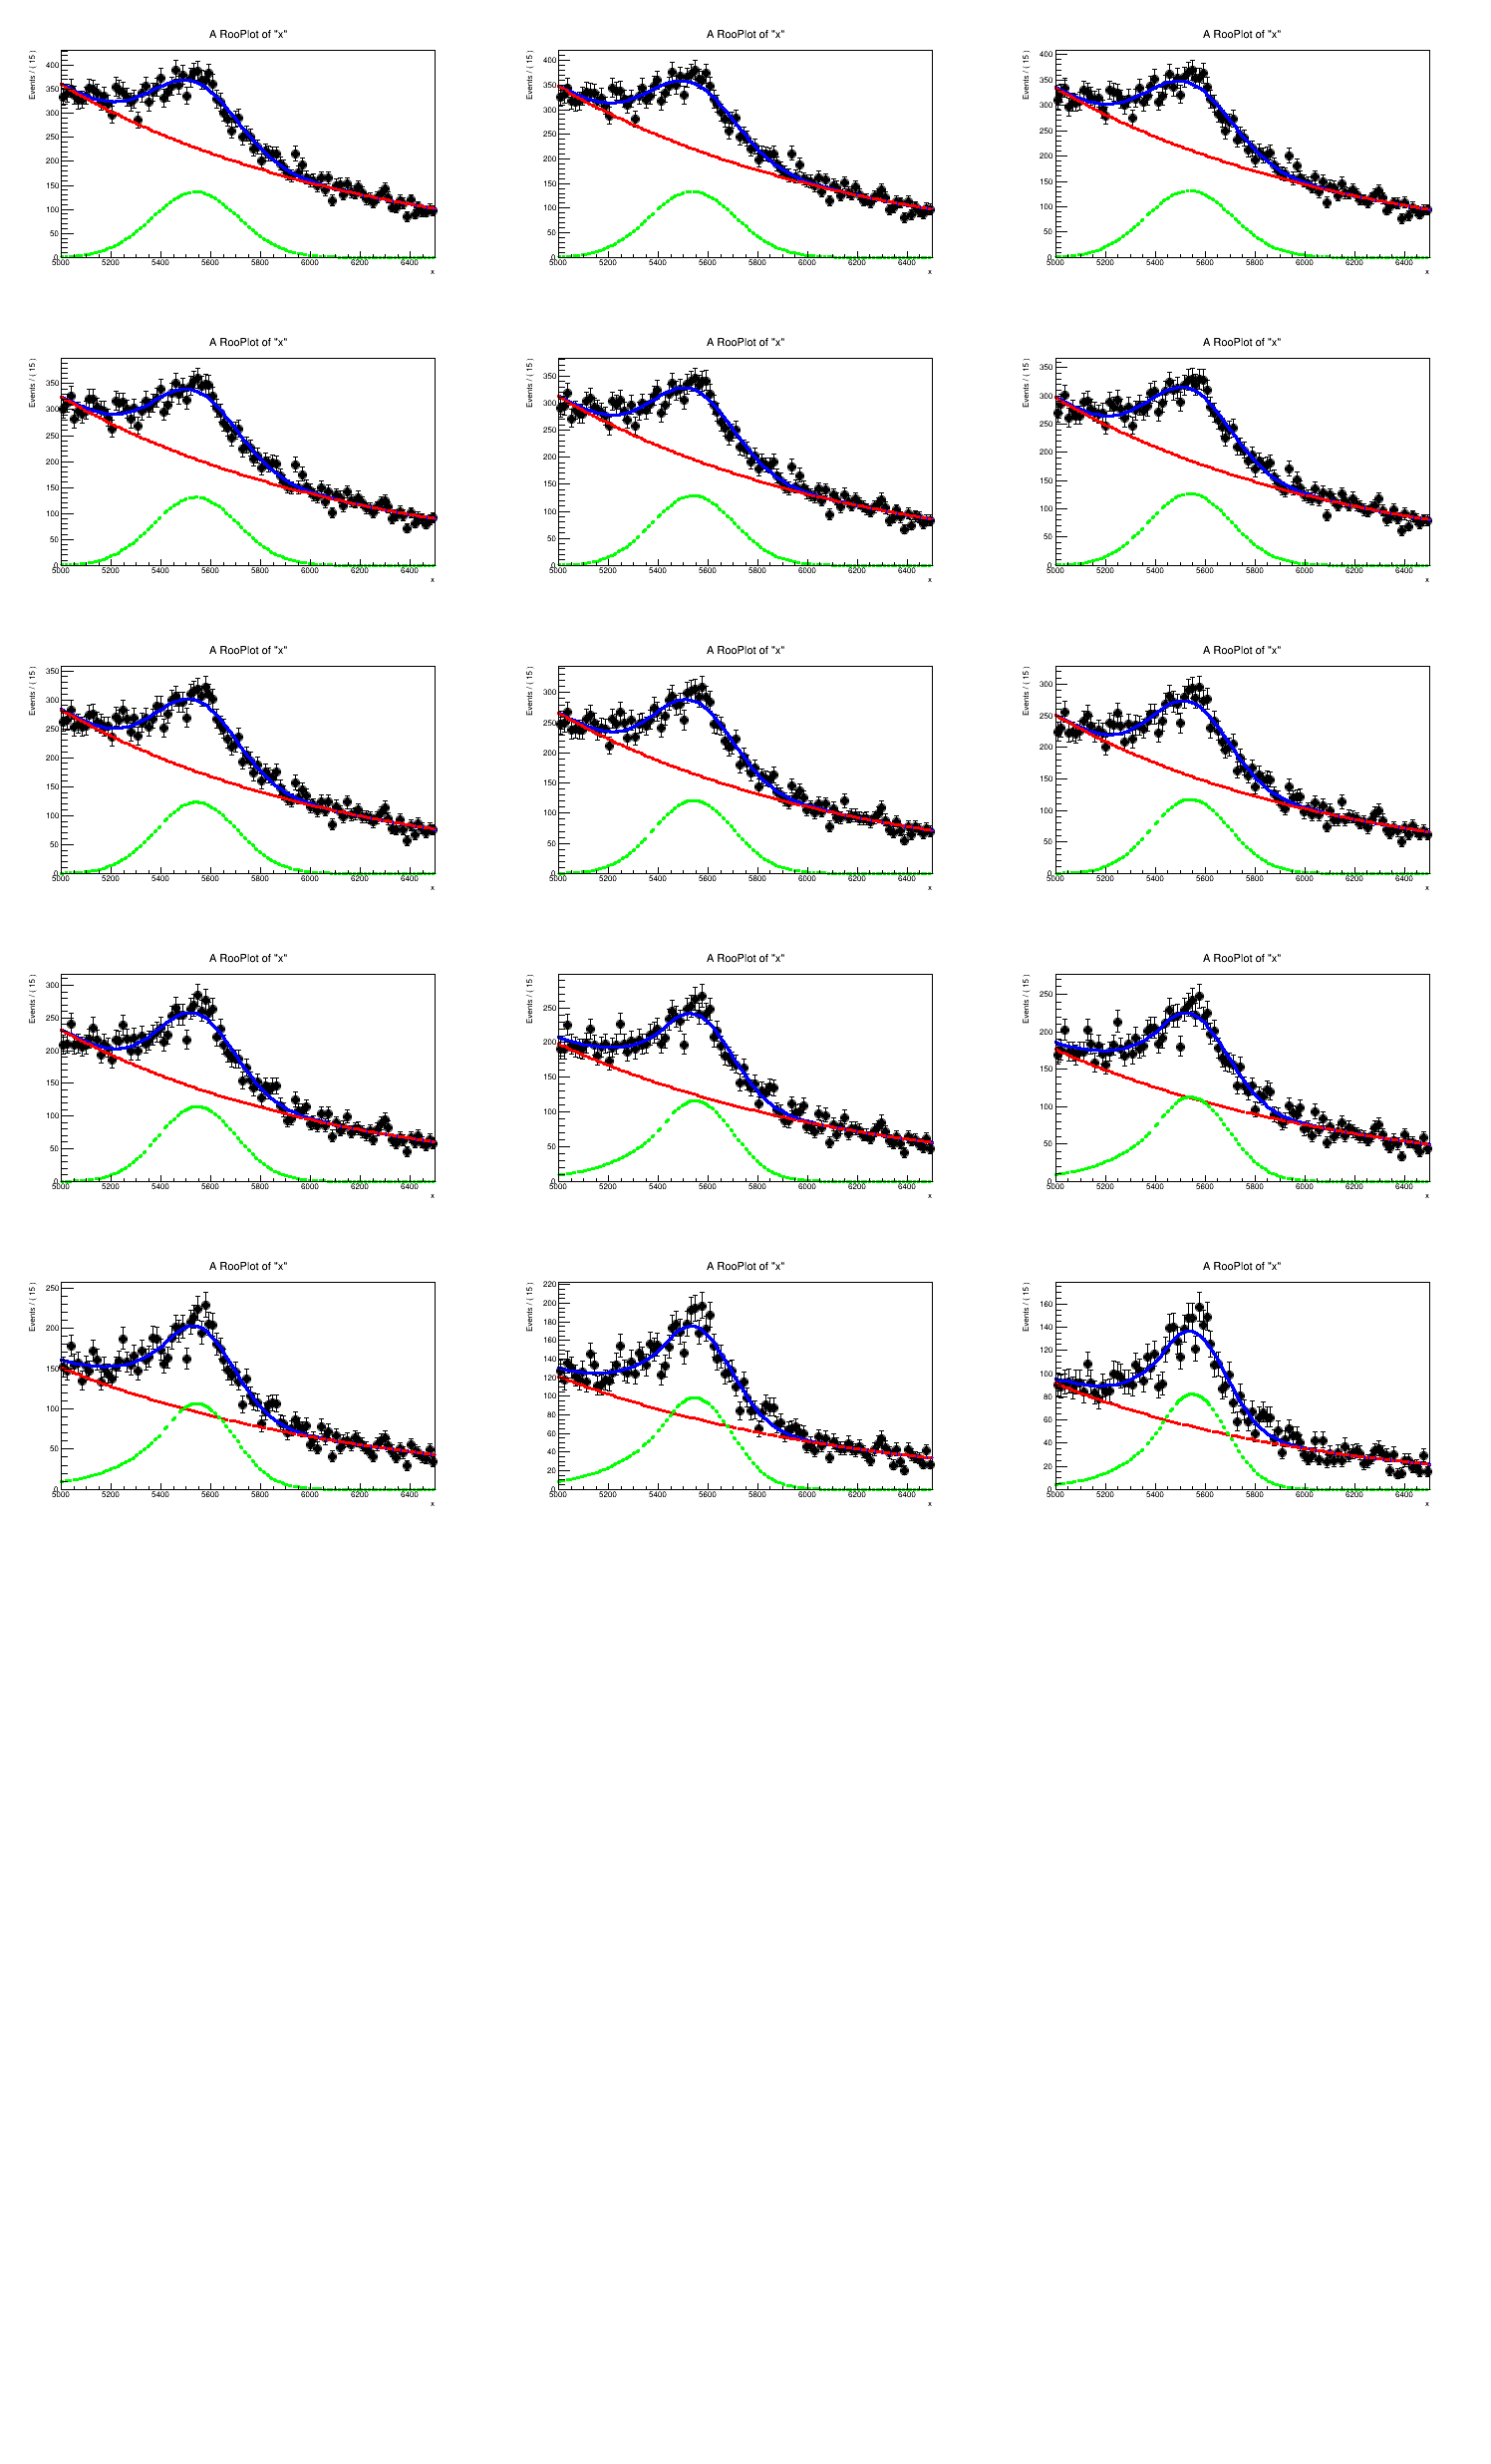

In [34]:
import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define el rango de probabilidad para evaluar
prob_start = 0.85
prob_end = 0.99
prob_step = 0.01  # Paso entre los valores de probabilidad

# Genera los valores de probabilidad dentro del rango definido
prob_values = np.arange(prob_start, prob_end, prob_step)

# Listas para almacenar los valores de probabilidad y los correspondientes valores de la expresión
prob_list = []
sig_bkg_ratio_list = []

# Variables para almacenar el valor máximo y la probabilidad correspondiente
max_sig_bkg_ratio = -1
best_prob = None

# Crear un canvas para dibujar los 12 ajustes con un nombre único
canvas_name = f"canvas_{np.random.randint(1e6)}"
canvas = ROOT.TCanvas(canvas_name, "Fits", 1500, 2500)
canvas.Divide(3, 8)  # 3 columnas por 4 filas

# Itera sobre diferentes valores de 'prob'
for i, prob_threshold in enumerate(prob_values):
    # Filtra los datos según el valor actual de 'prob'
    filtered_mass = data24_magup.loc[
        (data24_magup['prob'] > prob_threshold), 
        'Lb_MASS'
    ]

    # Convierte la Serie de pandas filtrada a un RooDataSet
    x = ROOT.RooRealVar('x', 'x', 5000, 6500)
    data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
    for mass in filtered_mass:
        x.setVal(mass)
        data_list.add(ROOT.RooArgSet(x))

    # Define los parámetros para la señal Double Crystal Ball, con sigmean fijo en 6012
    sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 5540,5520, 5620 )
    sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 120, 100, 300)
    
    # Parámetros de la cola izquierda
    alpha1 = ROOT.RooRealVar('alpha1', 'alpha1', 1.5, 0.5, 100.0)
    n1 = ROOT.RooRealVar('n1', 'n1', 2, 0.1, 500)
    
    # Parámetros de la cola derecha
    alpha2 = ROOT.RooRealVar('alpha2', 'alpha2', 1.5, 0.5, 100.0)
    n2 = ROOT.RooRealVar('n2', 'n2', 2, 0.1, 500)
    
    # Crear dos Crystal Ball: uno para la cola izquierda y otro para la derecha
    cb_left = ROOT.RooCBShape('cb_left', 'Crystal Ball Left Tail', x, sigmean, sigwidth, alpha1, n1)
    cb_right = ROOT.RooCBShape('cb_right', 'Crystal Ball Right Tail', x, sigmean, sigwidth, alpha2, n2)
    
    # Combina las dos funciones Crystal Ball en un modelo compuesto
    frac = ROOT.RooRealVar('frac', 'frac', 0.5, 0.0, 1.0)
    signalModel = ROOT.RooAddPdf('signal', 'Double Crystal Ball', cb_left, cb_right, frac)

    # Define el parámetro para el fondo exponencial
    lambda_bg = ROOT.RooRealVar('lambda_bg', 'slope', -0.001, -1.0, 0.0)

    # Construye el modelo de fondo exponencial
    background = ROOT.RooExponential('background', 'background', x, lambda_bg)

    # Construye un modelo combinado de señal y fondo
    nsig = ROOT.RooRealVar('nsig', 'nsig', 1000, 100., 20000)
    nbkg = ROOT.RooRealVar('nbkg', 'nbkg', 400, 100., 60000)
    model = ROOT.RooAddPdf('model', 'model', ROOT.RooArgList(signalModel, background), ROOT.RooArgList(nsig, nbkg))

    # Realiza el ajuste total
    total_fit_result = model.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

    # Crear un nuevo intervalo para la integración en la región de 5300-5750 MeV
    x.setRange("signalRegion", 5300, 5750)
    
    # Integra el componente de la señal y el fondo en la región de 5300-5750 MeV
    integral_signal_region = signalModel.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("signalRegion"))
    integral_full_range = signalModel.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("full"))
    
    ratio_signal = integral_signal_region.getVal() / integral_full_range.getVal()
    S_rescaled = nsig.getVal() * ratio_signal
    
    # Integra el componente de fondo en la región de 5300-5750 MeV
    integral_bkg_region = background.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("signalRegion"))
    integral_bkg_full_range = background.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("full"))
    
    ratio_bkg = integral_bkg_region.getVal() / integral_bkg_full_range.getVal()
    B_rescaled = nbkg.getVal() * ratio_bkg
    
    # Calcula la nueva relación S_rescaled / sqrt(S_rescaled + B_rescaled)
    sig_bkg_ratio = S_rescaled / np.sqrt(S_rescaled + B_rescaled)
    
    # Almacena los valores en las listas
    prob_list.append(prob_threshold)
    sig_bkg_ratio_list.append(sig_bkg_ratio)
    
    if sig_bkg_ratio > max_sig_bkg_ratio:
        max_sig_bkg_ratio = sig_bkg_ratio
        best_prob = prob_threshold
    
    # Dibuja los resultados del ajuste en el canvas
    canvas.cd(i+1)
    frame = x.frame()
    data_list.plotOn(frame)
    model.plotOn(frame)
    model.plotOn(frame, ROOT.RooFit.Components("background"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kRed))
    model.plotOn(frame, ROOT.RooFit.Components("signal"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kGreen))
    frame.Draw()

# Muestra el canvas con los 12 ajustes
canvas.Update()
canvas.Draw()

# Imprime el valor máximo y la probabilidad correspondiente
print(f"El valor máximo de sig / (sig + bkg)^0.5 es {max_sig_bkg_ratio} para prob = {best_prob}")

# Graficar los resultados de la significancia en función de la probabilidad
plt.figure(figsize=(10, 6))
plt.plot(prob_list, sig_bkg_ratio_list, marker='o', linestyle='-', color='b')
plt.xlabel('Probabilidad de corte')
plt.ylabel('sig / sqrt(sig + bkg)')
plt.title('Significancia en función de la probabilidad de corte')
plt.grid(True)
plt.show()


Doble crystal ball with floating mean for magdown

El valor máximo de sig / (sig + bkg)^0.5 es 31.447427439000844 para prob = 0.9


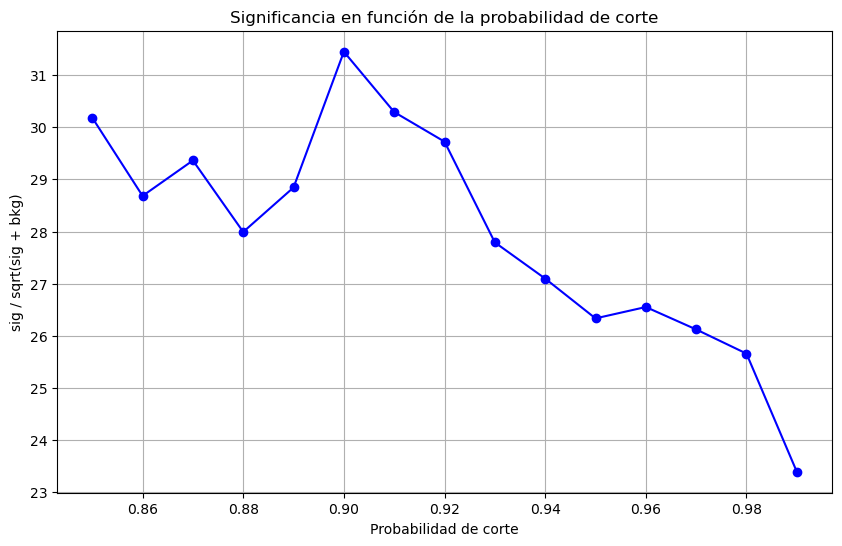

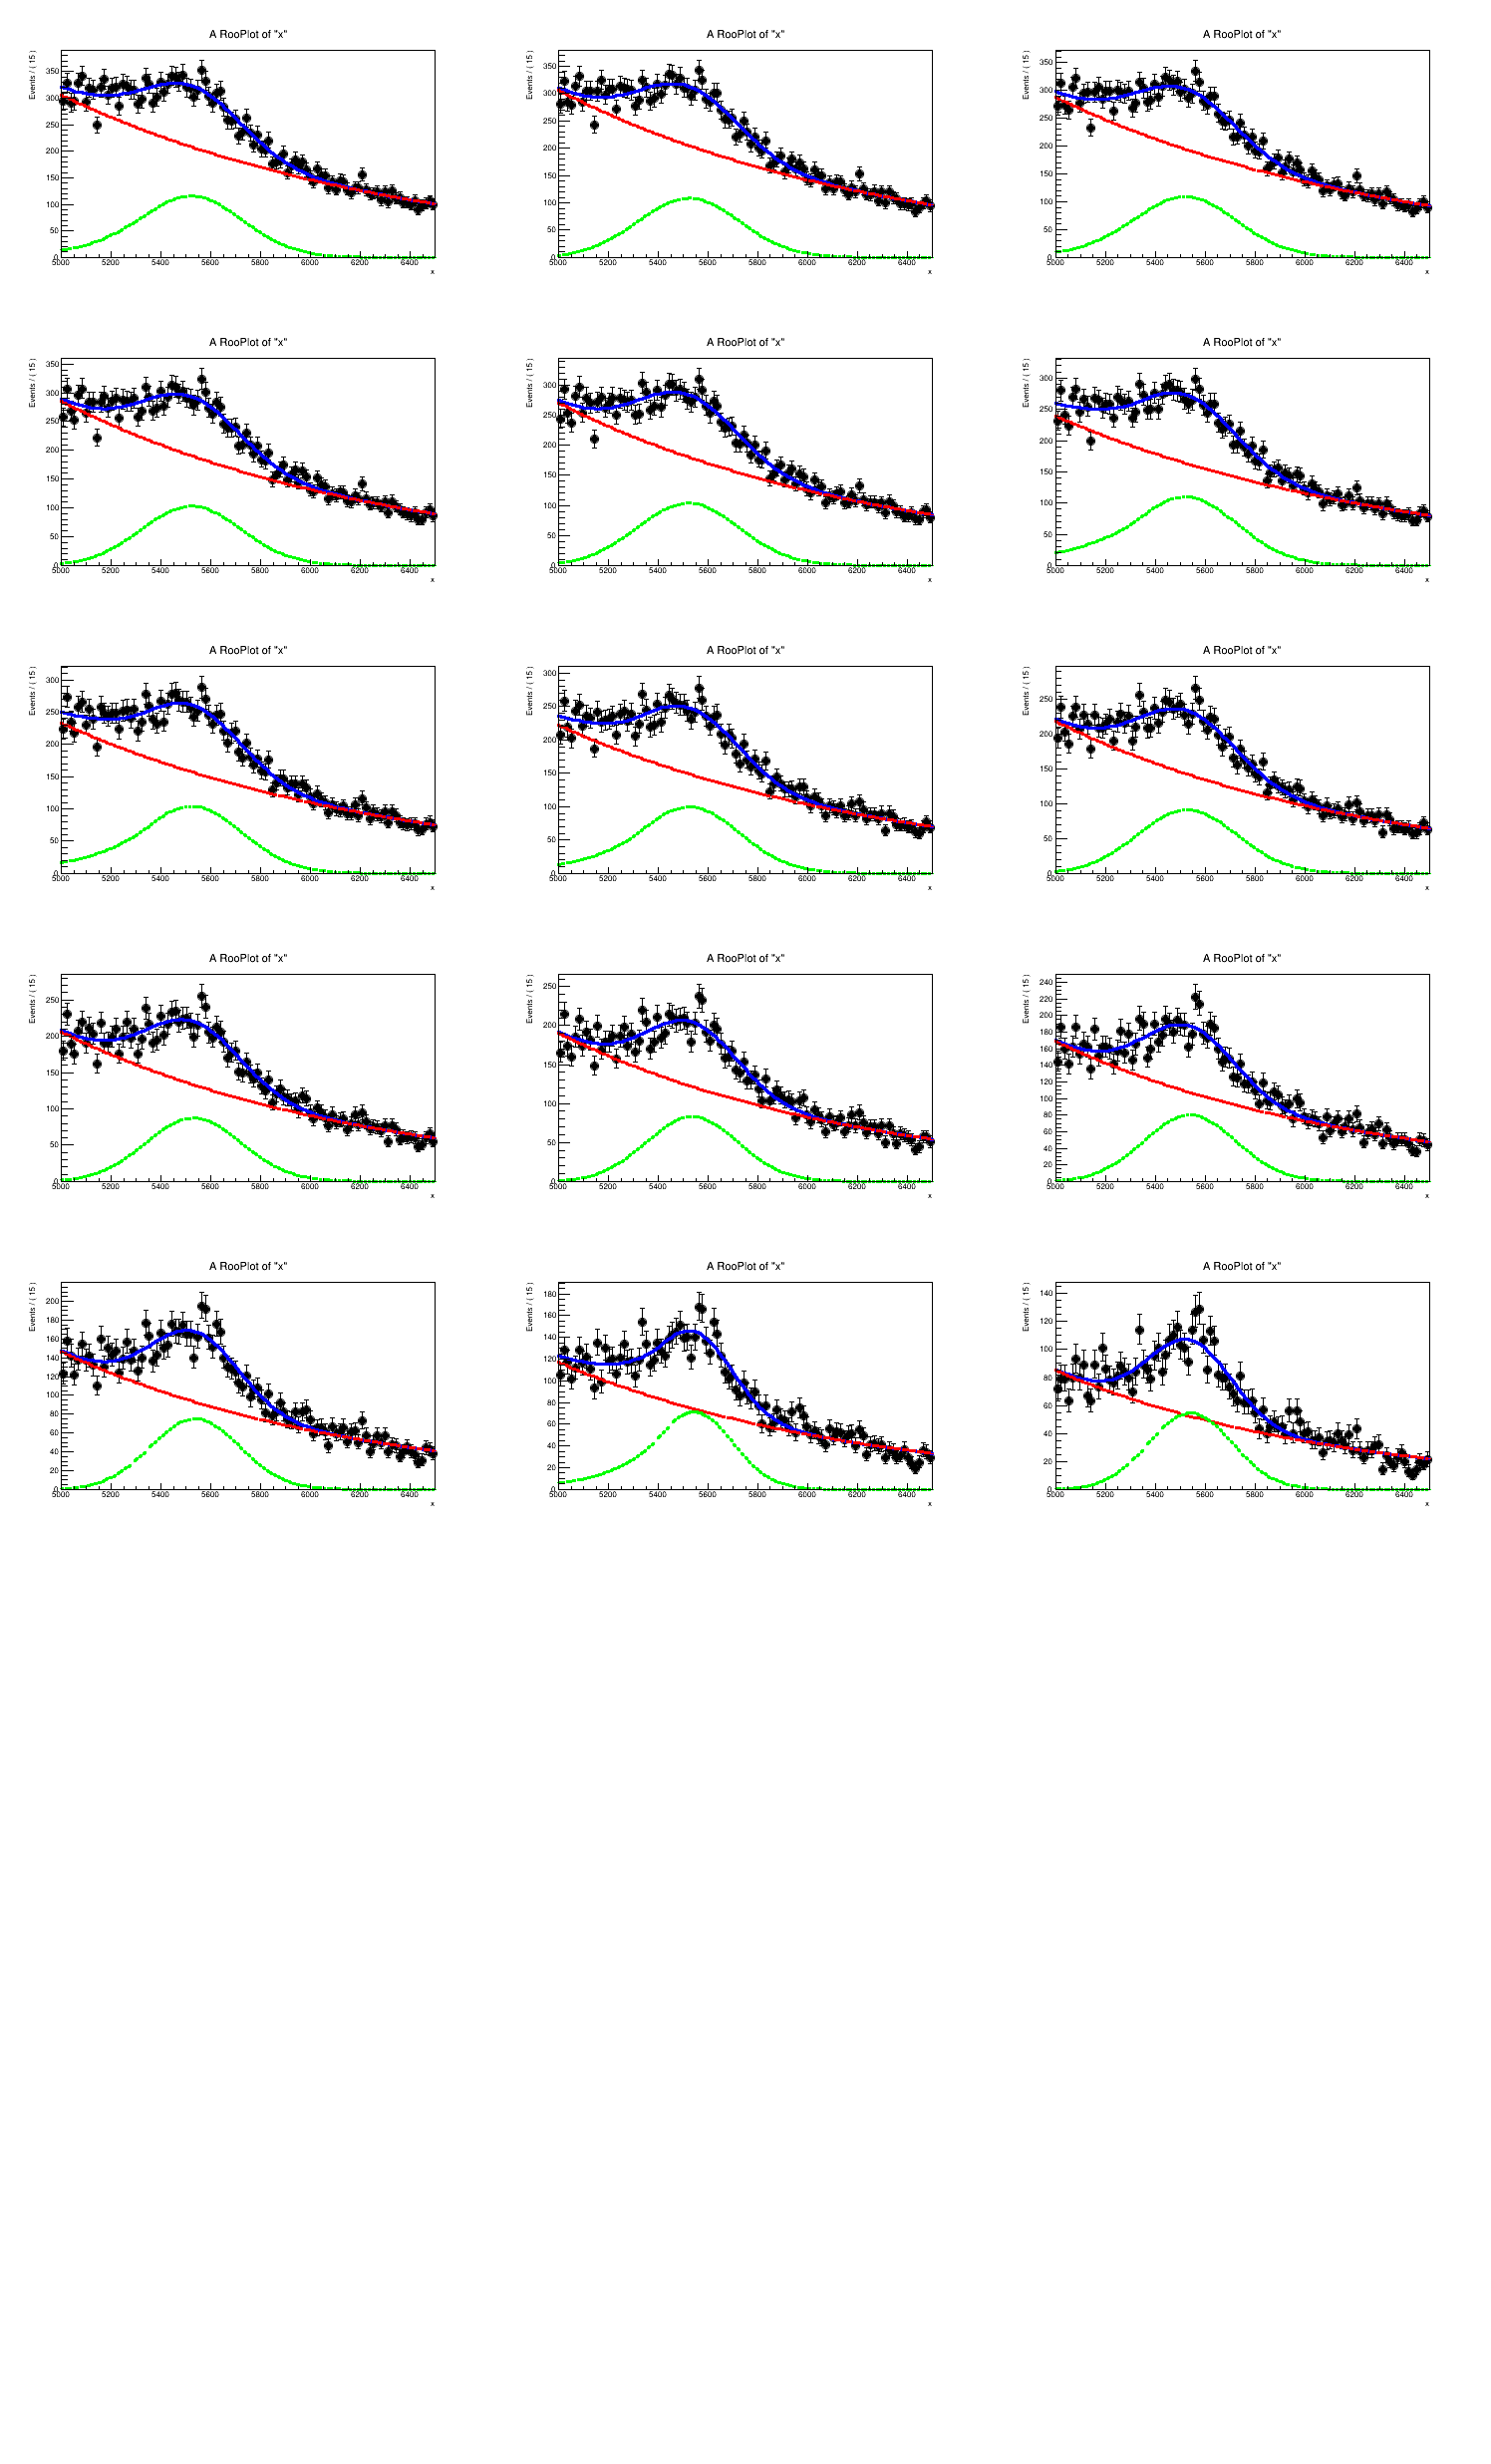

In [35]:
import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define el rango de probabilidad para evaluar
prob_start = 0.85
prob_end = 0.99
prob_step = 0.01  # Paso entre los valores de probabilidad

# Genera los valores de probabilidad dentro del rango definido
prob_values = np.arange(prob_start, prob_end, prob_step)

# Listas para almacenar los valores de probabilidad y los correspondientes valores de la expresión
prob_list = []
sig_bkg_ratio_list = []

# Variables para almacenar el valor máximo y la probabilidad correspondiente
max_sig_bkg_ratio = -1
best_prob = None

# Crear un canvas para dibujar los 12 ajustes con un nombre único
canvas_name = f"canvas_{np.random.randint(1e6)}"
canvas = ROOT.TCanvas(canvas_name, "Fits", 1500, 2500)
canvas.Divide(3, 8)  # 3 columnas por 4 filas

# Itera sobre diferentes valores de 'prob'
for i, prob_threshold in enumerate(prob_values):
    # Filtra los datos según el valor actual de 'prob'
    filtered_mass = data24_magdown.loc[
        (data24_magdown['prob'] > prob_threshold), 
        'Lb_MASS'
    ]

    # Convierte la Serie de pandas filtrada a un RooDataSet
    x = ROOT.RooRealVar('x', 'x', 5000, 6500)
    data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
    for mass in filtered_mass:
        x.setVal(mass)
        data_list.add(ROOT.RooArgSet(x))

    # Define los parámetros para la señal Double Crystal Ball, con sigmean fijo en 6012
    sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 5540,5520, 5620 )
    sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 120, 100, 300)
    
    # Parámetros de la cola izquierda
    alpha1 = ROOT.RooRealVar('alpha1', 'alpha1', 1.5, 0.5, 100.0)
    n1 = ROOT.RooRealVar('n1', 'n1', 2, 0.1, 500)
    
    # Parámetros de la cola derecha
    alpha2 = ROOT.RooRealVar('alpha2', 'alpha2', 1.5, 0.5, 100.0)
    n2 = ROOT.RooRealVar('n2', 'n2', 2, 0.1, 500)
    
    # Crear dos Crystal Ball: uno para la cola izquierda y otro para la derecha
    cb_left = ROOT.RooCBShape('cb_left', 'Crystal Ball Left Tail', x, sigmean, sigwidth, alpha1, n1)
    cb_right = ROOT.RooCBShape('cb_right', 'Crystal Ball Right Tail', x, sigmean, sigwidth, alpha2, n2)
    
    # Combina las dos funciones Crystal Ball en un modelo compuesto
    frac = ROOT.RooRealVar('frac', 'frac', 0.5, 0.0, 1.0)
    signalModel = ROOT.RooAddPdf('signal', 'Double Crystal Ball', cb_left, cb_right, frac)

    # Define el parámetro para el fondo exponencial
    lambda_bg = ROOT.RooRealVar('lambda_bg', 'slope', -0.001, -1.0, 0.0)

    # Construye el modelo de fondo exponencial
    background = ROOT.RooExponential('background', 'background', x, lambda_bg)

    # Construye un modelo combinado de señal y fondo
    nsig = ROOT.RooRealVar('nsig', 'nsig', 1000, 100., 20000)
    nbkg = ROOT.RooRealVar('nbkg', 'nbkg', 400, 100., 60000)
    model = ROOT.RooAddPdf('model', 'model', ROOT.RooArgList(signalModel, background), ROOT.RooArgList(nsig, nbkg))

    # Realiza el ajuste total
    total_fit_result = model.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

    # Crear un nuevo intervalo para la integración en la región de 5300-5750 MeV
    x.setRange("signalRegion", 5300, 5750)
    
    # Integra el componente de la señal y el fondo en la región de 5300-5750 MeV
    integral_signal_region = signalModel.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("signalRegion"))
    integral_full_range = signalModel.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("full"))
    
    ratio_signal = integral_signal_region.getVal() / integral_full_range.getVal()
    S_rescaled = nsig.getVal() * ratio_signal
    
    # Integra el componente de fondo en la región de 5300-5750 MeV
    integral_bkg_region = background.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("signalRegion"))
    integral_bkg_full_range = background.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("full"))
    
    ratio_bkg = integral_bkg_region.getVal() / integral_bkg_full_range.getVal()
    B_rescaled = nbkg.getVal() * ratio_bkg
    
    # Calcula la nueva relación S_rescaled / sqrt(S_rescaled + B_rescaled)
    sig_bkg_ratio = S_rescaled / np.sqrt(S_rescaled + B_rescaled)
    
    # Almacena los valores en las listas
    prob_list.append(prob_threshold)
    sig_bkg_ratio_list.append(sig_bkg_ratio)
    
    if sig_bkg_ratio > max_sig_bkg_ratio:
        max_sig_bkg_ratio = sig_bkg_ratio
        best_prob = prob_threshold
    
    # Dibuja los resultados del ajuste en el canvas
    canvas.cd(i+1)
    frame = x.frame()
    data_list.plotOn(frame)
    model.plotOn(frame)
    model.plotOn(frame, ROOT.RooFit.Components("background"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kRed))
    model.plotOn(frame, ROOT.RooFit.Components("signal"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kGreen))
    frame.Draw()

# Muestra el canvas con los 12 ajustes
canvas.Update()
canvas.Draw()

# Imprime el valor máximo y la probabilidad correspondiente
print(f"El valor máximo de sig / (sig + bkg)^0.5 es {max_sig_bkg_ratio} para prob = {best_prob}")

# Graficar los resultados de la significancia en función de la probabilidad
plt.figure(figsize=(10, 6))
plt.plot(prob_list, sig_bkg_ratio_list, marker='o', linestyle='-', color='b')
plt.xlabel('Probabilidad de corte')
plt.ylabel('sig / sqrt(sig + bkg)')
plt.title('Significancia en función de la probabilidad de corte')
plt.grid(True)
plt.show()


El valor máximo de sig / (sig + bkg)^0.5 es 32.44814785538203 para prob = 0.9600000000000001


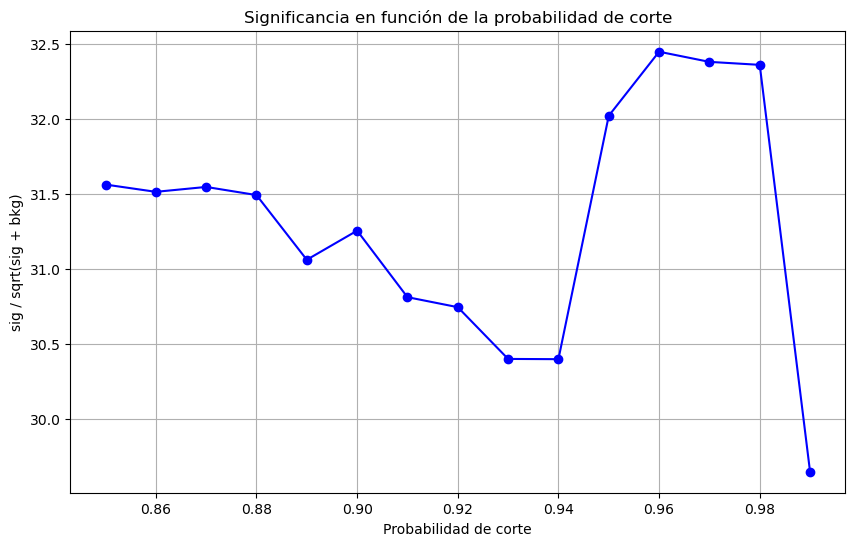

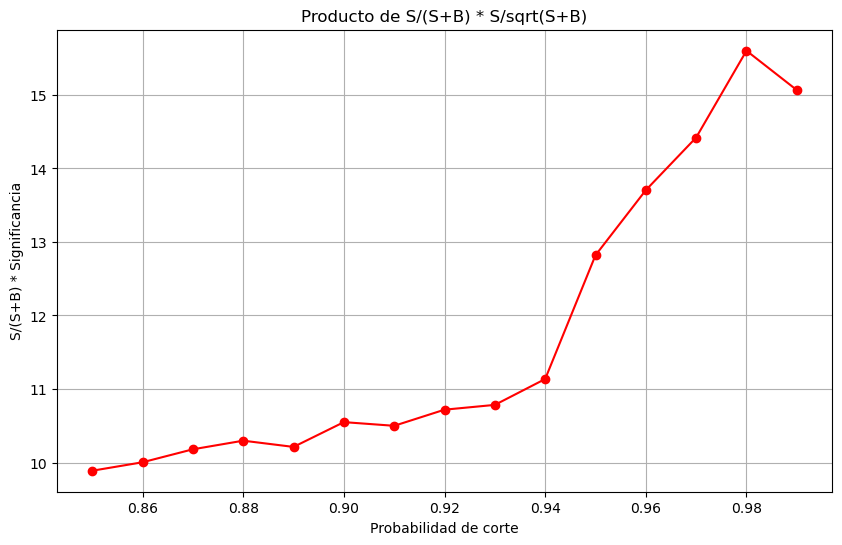

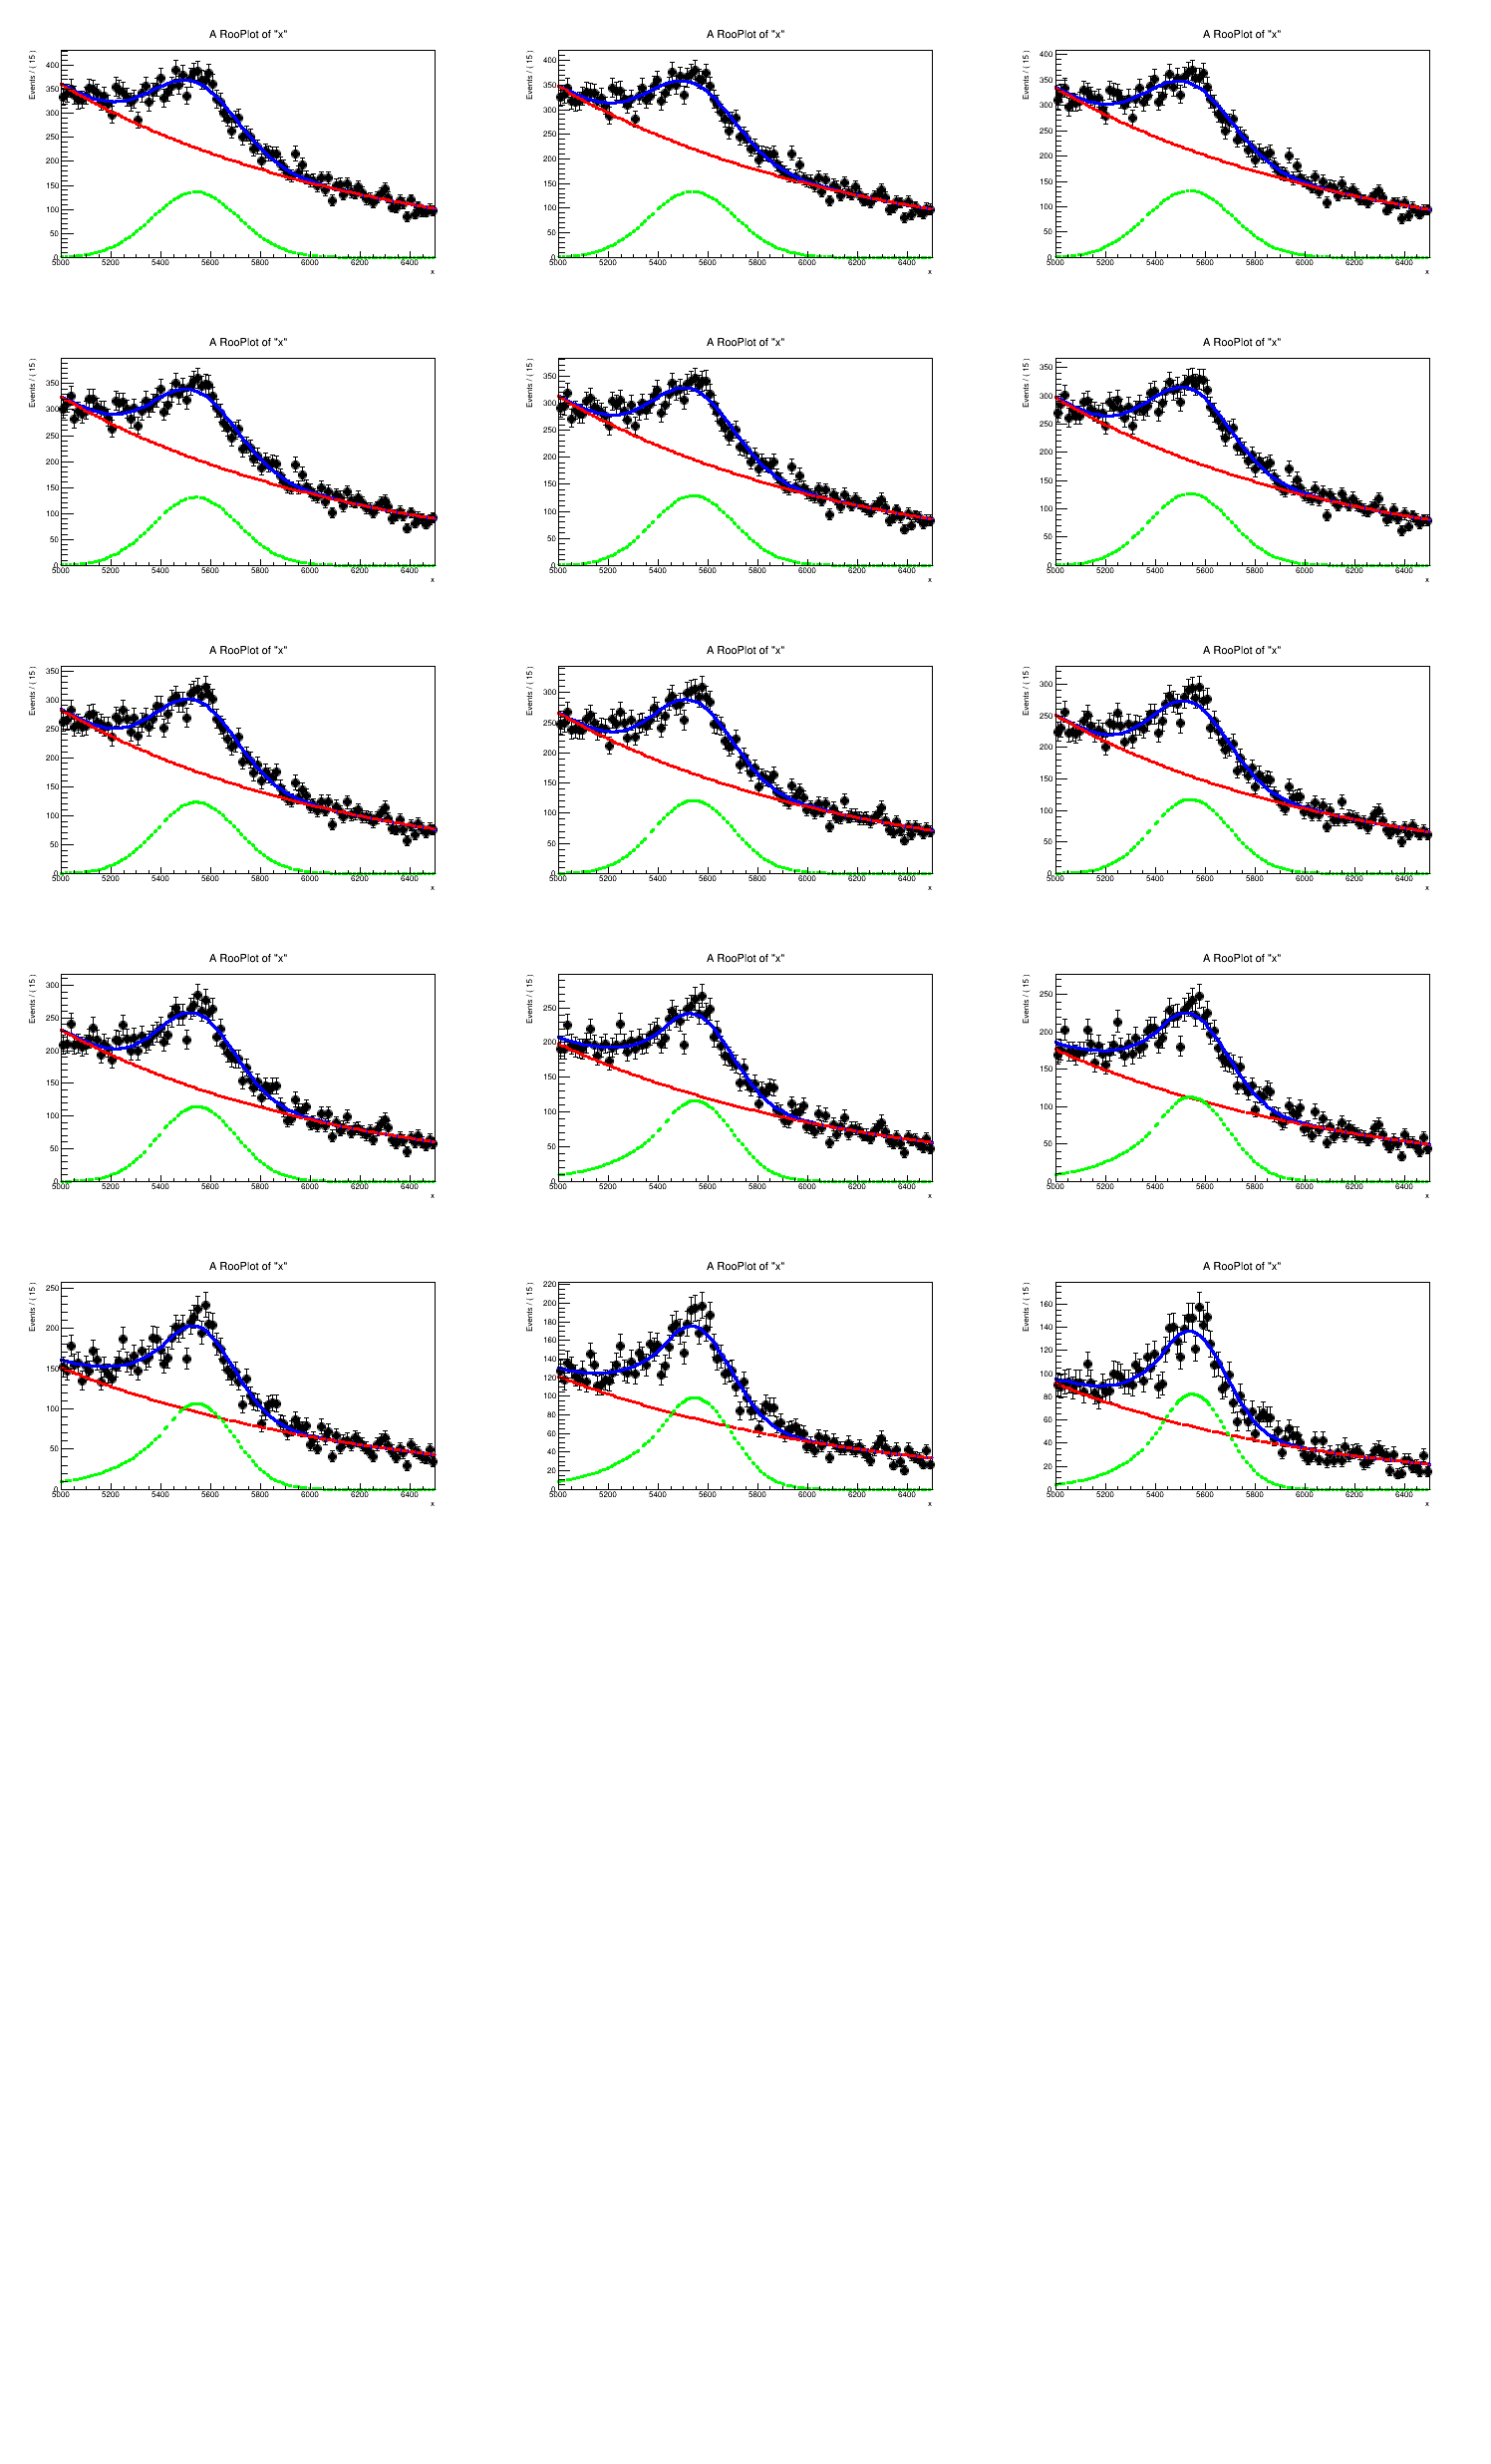

In [6]:
import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define el rango de probabilidad para evaluar
prob_start = 0.85
prob_end = 0.99
prob_step = 0.01  # Paso entre los valores de probabilidad

# Genera los valores de probabilidad dentro del rango definido
prob_values = np.arange(prob_start, prob_end, prob_step)

# Listas para almacenar los valores de probabilidad y los correspondientes valores de la expresión
prob_list = []
sig_bkg_ratio_list = []
product_list = []  # Nueva lista para almacenar los valores del producto S/(S+B) * Significancia

# Variables para almacenar el valor máximo y la probabilidad correspondiente
max_sig_bkg_ratio = -1
best_prob = None

# Crear un canvas para dibujar los 12 ajustes con un nombre único
canvas_name = f"canvas_{np.random.randint(1e6)}"
canvas = ROOT.TCanvas(canvas_name, "Fits", 1500, 2500)
canvas.Divide(3, 8)  # 3 columnas por 4 filas

# Itera sobre diferentes valores de 'prob'
for i, prob_threshold in enumerate(prob_values):
    # Filtra los datos según el valor actual de 'prob'
    filtered_mass = data24_magup.loc[
        (data24_magup['prob'] > prob_threshold), 
        'Lb_MASS'
    ]

    # Convierte la Serie de pandas filtrada a un RooDataSet
    x = ROOT.RooRealVar('x', 'x', 5000, 6500)
    data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
    for mass in filtered_mass:
        x.setVal(mass)
        data_list.add(ROOT.RooArgSet(x))

    # Define los parámetros para la señal Double Crystal Ball, con sigmean fijo en 6012
    sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 5540,5520, 5620 )
    sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 120, 100, 300)
    
    # Parámetros de la cola izquierda
    alpha1 = ROOT.RooRealVar('alpha1', 'alpha1', 1.5, 0.5, 100.0)
    n1 = ROOT.RooRealVar('n1', 'n1', 2, 0.1, 500)
    
    # Parámetros de la cola derecha
    alpha2 = ROOT.RooRealVar('alpha2', 'alpha2', 1.5, 0.5, 100.0)
    n2 = ROOT.RooRealVar('n2', 'n2', 2, 0.1, 500)
    
    # Crear dos Crystal Ball: uno para la cola izquierda y otro para la derecha
    cb_left = ROOT.RooCBShape('cb_left', 'Crystal Ball Left Tail', x, sigmean, sigwidth, alpha1, n1)
    cb_right = ROOT.RooCBShape('cb_right', 'Crystal Ball Right Tail', x, sigmean, sigwidth, alpha2, n2)
    
    # Combina las dos funciones Crystal Ball en un modelo compuesto
    frac = ROOT.RooRealVar('frac', 'frac', 0.5, 0.0, 1.0)
    signalModel = ROOT.RooAddPdf('signal', 'Double Crystal Ball', cb_left, cb_right, frac)

    # Define el parámetro para el fondo exponencial
    lambda_bg = ROOT.RooRealVar('lambda_bg', 'slope', -0.001, -1.0, 0.0)

    # Construye el modelo de fondo exponencial
    background = ROOT.RooExponential('background', 'background', x, lambda_bg)

    # Construye un modelo combinado de señal y fondo
    nsig = ROOT.RooRealVar('nsig', 'nsig', 1000, 100., 20000)
    nbkg = ROOT.RooRealVar('nbkg', 'nbkg', 400, 100., 60000)
    model = ROOT.RooAddPdf('model', 'model', ROOT.RooArgList(signalModel, background), ROOT.RooArgList(nsig, nbkg))

    # Realiza el ajuste total
    total_fit_result = model.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

    # Crear un nuevo intervalo para la integración en la región de 5300-5750 MeV
    x.setRange("signalRegion", 5300, 5750)
    
    # Integra el componente de la señal y el fondo en la región de 5300-5750 MeV
    integral_signal_region = signalModel.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("signalRegion"))
    integral_full_range = signalModel.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("full"))
    
    ratio_signal = integral_signal_region.getVal() / integral_full_range.getVal()
    S_rescaled = nsig.getVal() * ratio_signal
    
    # Integra el componente de fondo en la región de 5300-5750 MeV
    integral_bkg_region = background.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("signalRegion"))
    integral_bkg_full_range = background.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("full"))
    
    ratio_bkg = integral_bkg_region.getVal() / integral_bkg_full_range.getVal()
    B_rescaled = nbkg.getVal() * ratio_bkg
    
    # Calcula la nueva relación S_rescaled / sqrt(S_rescaled + B_rescaled)
    sig_bkg_ratio = S_rescaled / np.sqrt(S_rescaled + B_rescaled)
    
    # Calcula el producto de S/(S+B) * significancia
    if (S_rescaled + B_rescaled) > 0:
        product = (S_rescaled / (S_rescaled + B_rescaled)) * sig_bkg_ratio
    else:
        product = 0
    
    # Almacena los valores en las listas
    prob_list.append(prob_threshold)
    sig_bkg_ratio_list.append(sig_bkg_ratio)
    product_list.append(product)
    
    if sig_bkg_ratio > max_sig_bkg_ratio:
        max_sig_bkg_ratio = sig_bkg_ratio
        best_prob = prob_threshold
    
    # Dibuja los resultados del ajuste en el canvas
    canvas.cd(i+1)
    frame = x.frame()
    data_list.plotOn(frame)
    model.plotOn(frame)
    model.plotOn(frame, ROOT.RooFit.Components("background"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kRed))
    model.plotOn(frame, ROOT.RooFit.Components("signal"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kGreen))
    frame.Draw()

# Muestra el canvas con los ajustes
canvas.Update()
canvas.Draw()

# Imprime el valor máximo y la probabilidad correspondiente
print(f"El valor máximo de sig / (sig + bkg)^0.5 es {max_sig_bkg_ratio} para prob = {best_prob}")

# Graficar los resultados de la significancia en función de la probabilidad
plt.figure(figsize=(10, 6))
plt.plot(prob_list, sig_bkg_ratio_list, marker='o', linestyle='-', color='b')
plt.xlabel('Probabilidad de corte')
plt.ylabel('sig / sqrt(sig + bkg)')
plt.title('Significancia en función de la probabilidad de corte')
plt.grid(True)
plt.show()

# Graficar el producto de S/(S+B) * significancia en función de la probabilidad
plt.figure(figsize=(10, 6))
plt.plot(prob_list, product_list, marker='o', linestyle='-', color='r')
plt.xlabel('Probabilidad de corte')
plt.ylabel('S/(S+B) * Significancia')
plt.title('Producto de S/(S+B) * S/sqrt(S+B)')
plt.grid(True)
plt.show()


El valor máximo de sig / (sig + bkg)^0.5 es 31.447427439000844 para prob = 0.9


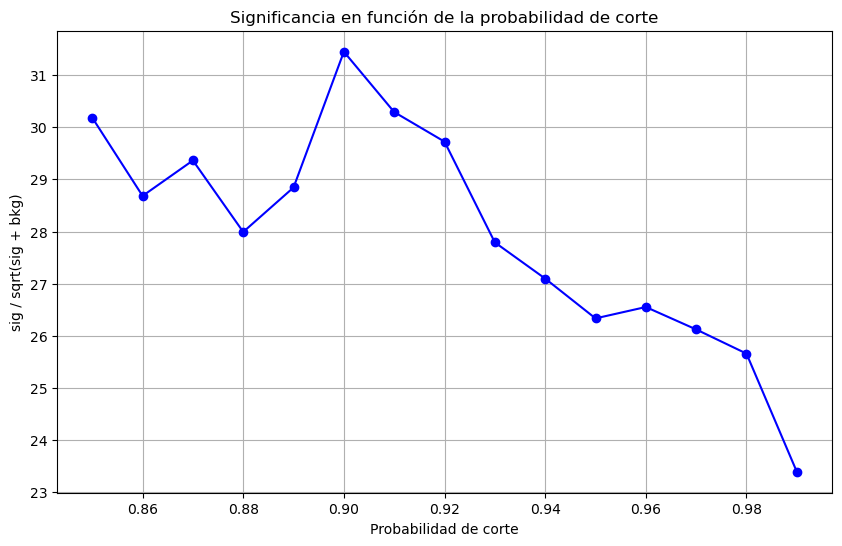

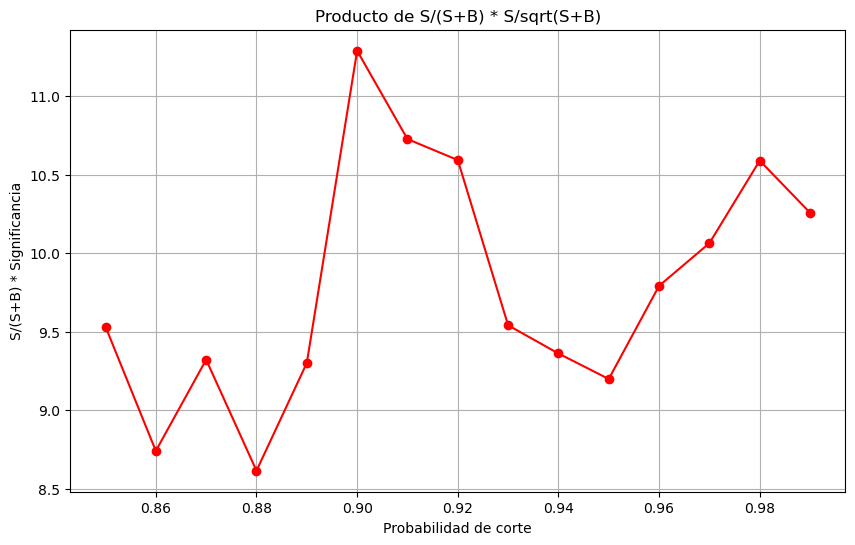

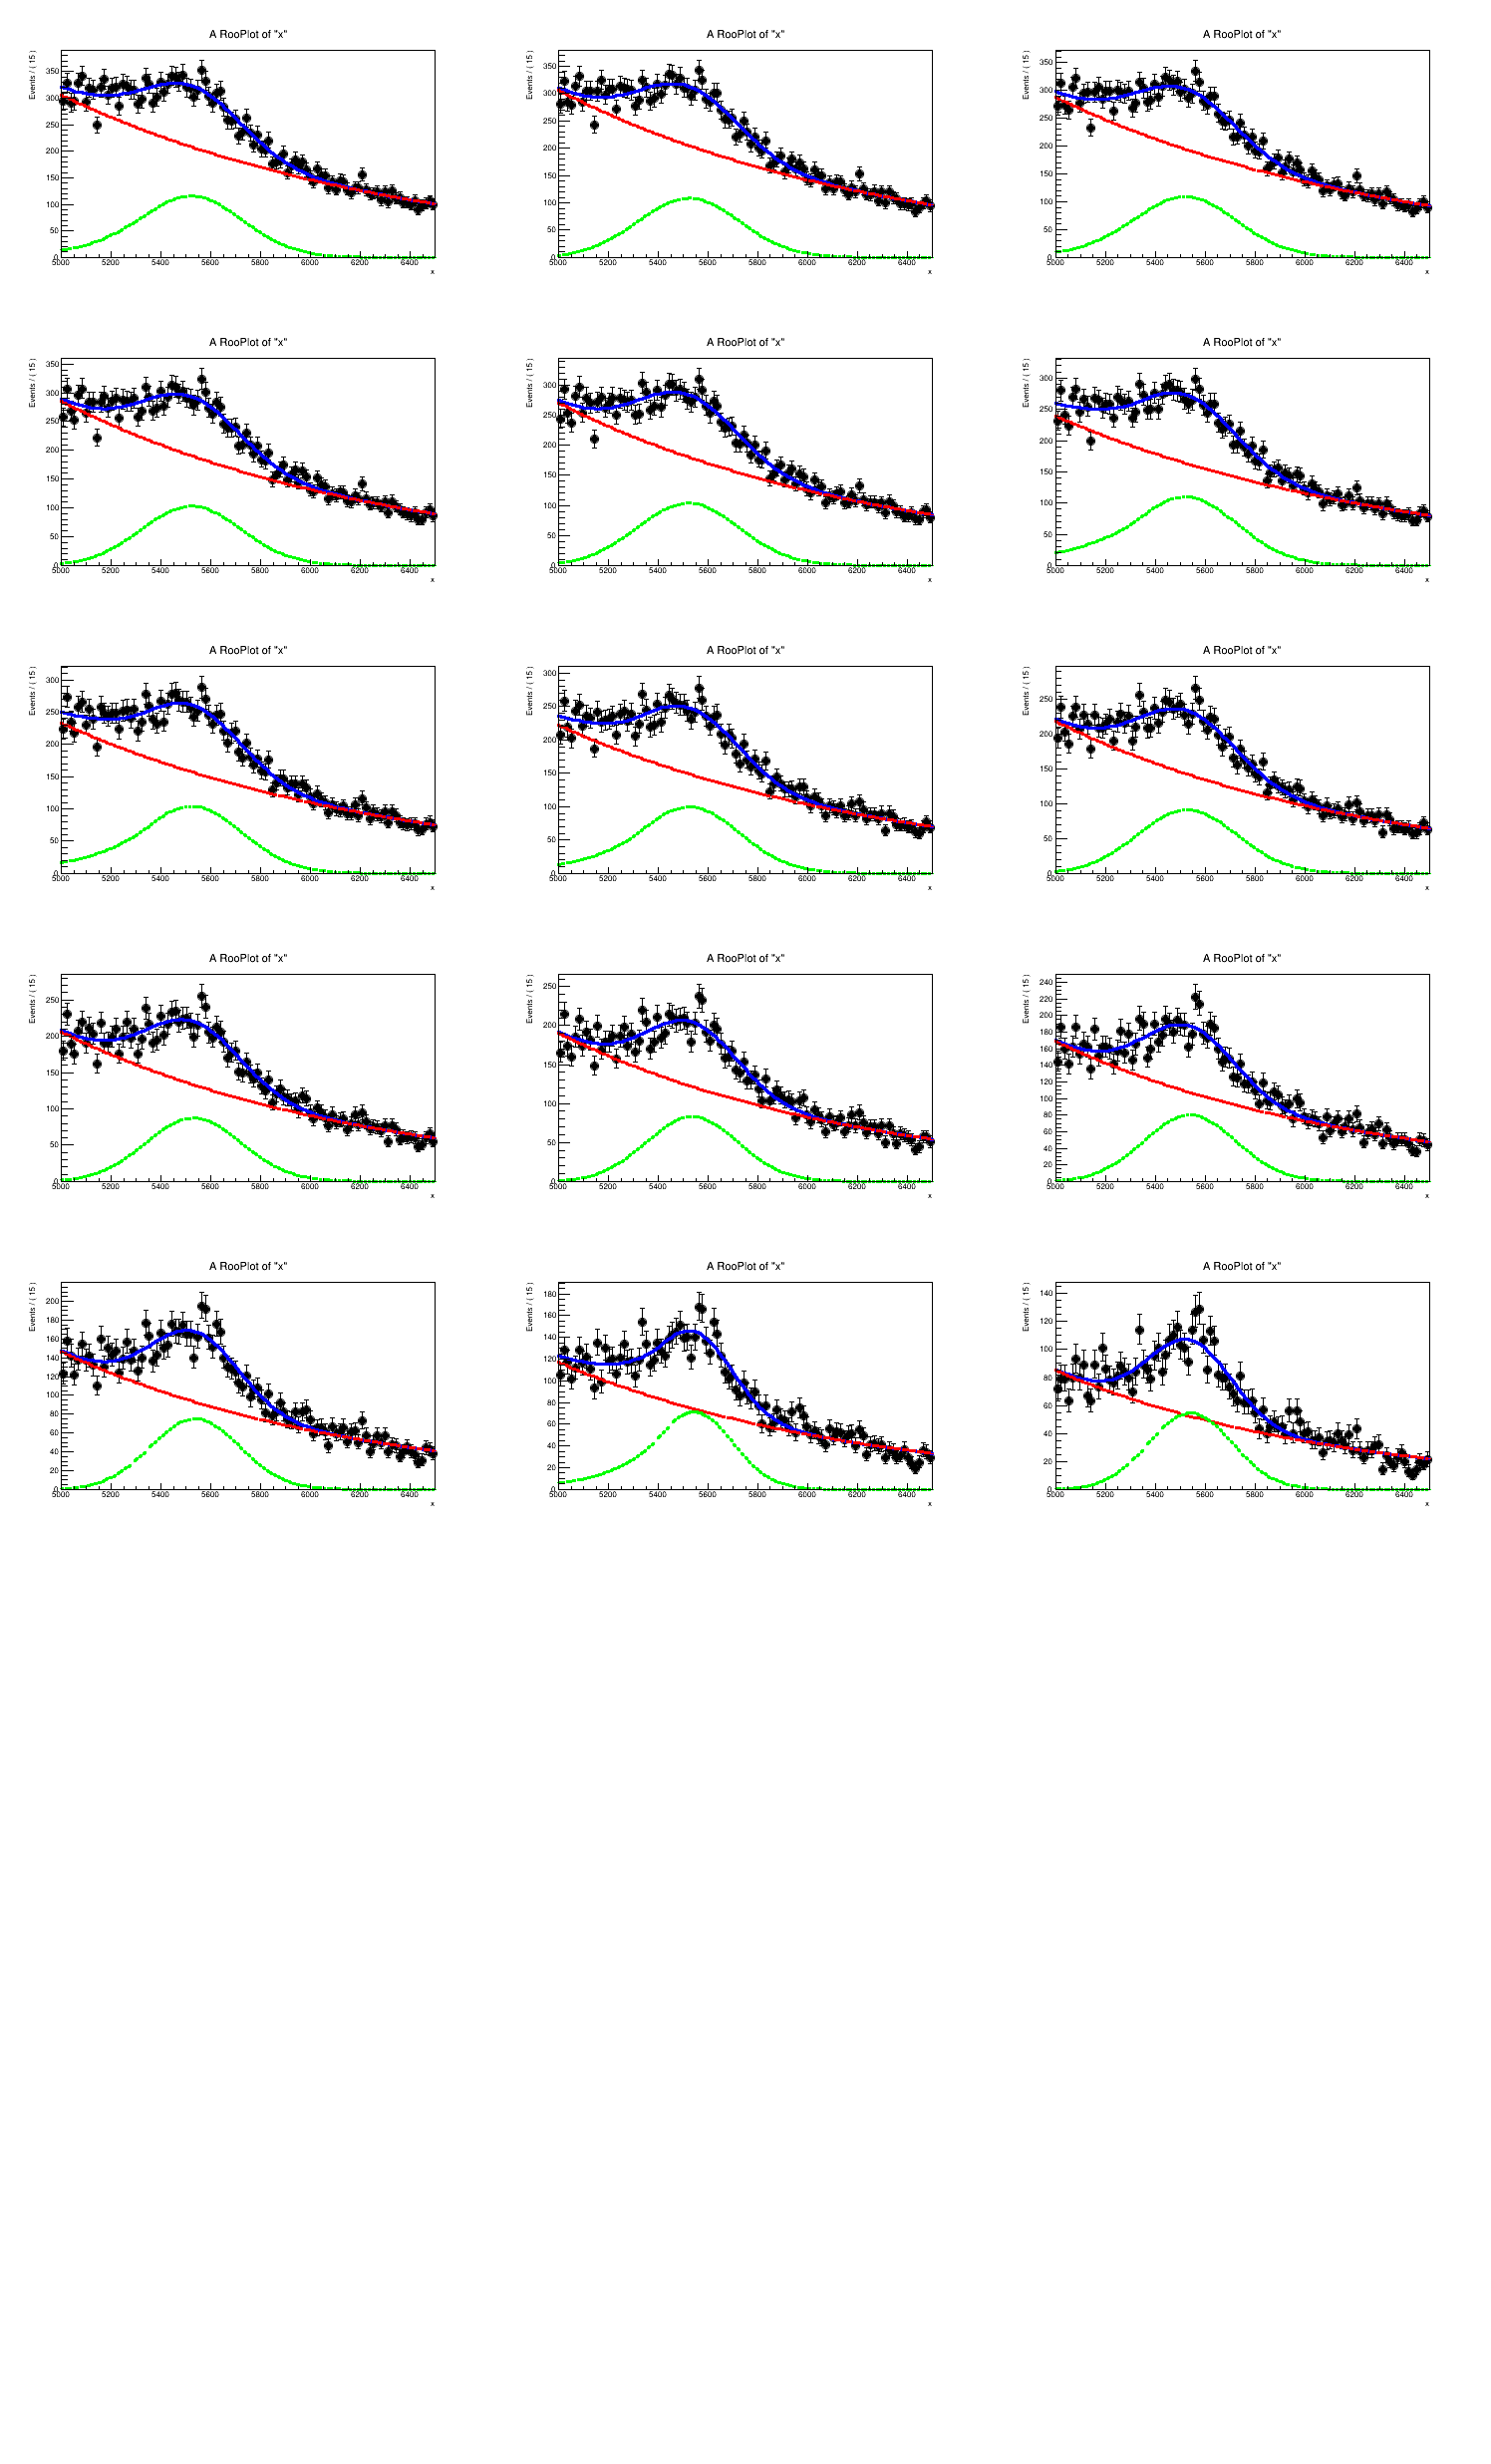

In [7]:
import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define el rango de probabilidad para evaluar
prob_start = 0.85
prob_end = 0.99
prob_step = 0.01  # Paso entre los valores de probabilidad

# Genera los valores de probabilidad dentro del rango definido
prob_values = np.arange(prob_start, prob_end, prob_step)

# Listas para almacenar los valores de probabilidad y los correspondientes valores de la expresión
prob_list = []
sig_bkg_ratio_list = []
product_list = []  # Nueva lista para almacenar los valores del producto S/(S+B) * Significancia

# Variables para almacenar el valor máximo y la probabilidad correspondiente
max_sig_bkg_ratio = -1
best_prob = None

# Crear un canvas para dibujar los 12 ajustes con un nombre único
canvas_name = f"canvas_{np.random.randint(1e6)}"
canvas = ROOT.TCanvas(canvas_name, "Fits", 1500, 2500)
canvas.Divide(3, 8)  # 3 columnas por 4 filas

# Itera sobre diferentes valores de 'prob'
for i, prob_threshold in enumerate(prob_values):
    # Filtra los datos según el valor actual de 'prob'
    filtered_mass = data24_magdown.loc[
        (data24_magdown['prob'] > prob_threshold), 
        'Lb_MASS'
    ]

    # Convierte la Serie de pandas filtrada a un RooDataSet
    x = ROOT.RooRealVar('x', 'x', 5000, 6500)
    data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
    for mass in filtered_mass:
        x.setVal(mass)
        data_list.add(ROOT.RooArgSet(x))

    # Define los parámetros para la señal Double Crystal Ball, con sigmean fijo en 6012
    sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 5540,5520, 5620 )
    sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 120, 100, 300)
    
    # Parámetros de la cola izquierda
    alpha1 = ROOT.RooRealVar('alpha1', 'alpha1', 1.5, 0.5, 100.0)
    n1 = ROOT.RooRealVar('n1', 'n1', 2, 0.1, 500)
    
    # Parámetros de la cola derecha
    alpha2 = ROOT.RooRealVar('alpha2', 'alpha2', 1.5, 0.5, 100.0)
    n2 = ROOT.RooRealVar('n2', 'n2', 2, 0.1, 500)
    
    # Crear dos Crystal Ball: uno para la cola izquierda y otro para la derecha
    cb_left = ROOT.RooCBShape('cb_left', 'Crystal Ball Left Tail', x, sigmean, sigwidth, alpha1, n1)
    cb_right = ROOT.RooCBShape('cb_right', 'Crystal Ball Right Tail', x, sigmean, sigwidth, alpha2, n2)
    
    # Combina las dos funciones Crystal Ball en un modelo compuesto
    frac = ROOT.RooRealVar('frac', 'frac', 0.5, 0.0, 1.0)
    signalModel = ROOT.RooAddPdf('signal', 'Double Crystal Ball', cb_left, cb_right, frac)

    # Define el parámetro para el fondo exponencial
    lambda_bg = ROOT.RooRealVar('lambda_bg', 'slope', -0.001, -1.0, 0.0)

    # Construye el modelo de fondo exponencial
    background = ROOT.RooExponential('background', 'background', x, lambda_bg)

    # Construye un modelo combinado de señal y fondo
    nsig = ROOT.RooRealVar('nsig', 'nsig', 1000, 100., 20000)
    nbkg = ROOT.RooRealVar('nbkg', 'nbkg', 400, 100., 60000)
    model = ROOT.RooAddPdf('model', 'model', ROOT.RooArgList(signalModel, background), ROOT.RooArgList(nsig, nbkg))

    # Realiza el ajuste total
    total_fit_result = model.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

    # Crear un nuevo intervalo para la integración en la región de 5300-5750 MeV
    x.setRange("signalRegion", 5300, 5750)
    
    # Integra el componente de la señal y el fondo en la región de 5300-5750 MeV
    integral_signal_region = signalModel.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("signalRegion"))
    integral_full_range = signalModel.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("full"))
    
    ratio_signal = integral_signal_region.getVal() / integral_full_range.getVal()
    S_rescaled = nsig.getVal() * ratio_signal
    
    # Integra el componente de fondo en la región de 5300-5750 MeV
    integral_bkg_region = background.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("signalRegion"))
    integral_bkg_full_range = background.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("full"))
    
    ratio_bkg = integral_bkg_region.getVal() / integral_bkg_full_range.getVal()
    B_rescaled = nbkg.getVal() * ratio_bkg
    
    # Calcula la nueva relación S_rescaled / sqrt(S_rescaled + B_rescaled)
    sig_bkg_ratio = S_rescaled / np.sqrt(S_rescaled + B_rescaled)
    
    # Calcula el producto de S/(S+B) * significancia
    if (S_rescaled + B_rescaled) > 0:
        product = (S_rescaled / (S_rescaled + B_rescaled)) * sig_bkg_ratio
    else:
        product = 0
    
    # Almacena los valores en las listas
    prob_list.append(prob_threshold)
    sig_bkg_ratio_list.append(sig_bkg_ratio)
    product_list.append(product)
    
    if sig_bkg_ratio > max_sig_bkg_ratio:
        max_sig_bkg_ratio = sig_bkg_ratio
        best_prob = prob_threshold
    
    # Dibuja los resultados del ajuste en el canvas
    canvas.cd(i+1)
    frame = x.frame()
    data_list.plotOn(frame)
    model.plotOn(frame)
    model.plotOn(frame, ROOT.RooFit.Components("background"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kRed))
    model.plotOn(frame, ROOT.RooFit.Components("signal"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kGreen))
    frame.Draw()

# Muestra el canvas con los ajustes
canvas.Update()
canvas.Draw()

# Imprime el valor máximo y la probabilidad correspondiente
print(f"El valor máximo de sig / (sig + bkg)^0.5 es {max_sig_bkg_ratio} para prob = {best_prob}")

# Graficar los resultados de la significancia en función de la probabilidad
plt.figure(figsize=(10, 6))
plt.plot(prob_list, sig_bkg_ratio_list, marker='o', linestyle='-', color='b')
plt.xlabel('Probabilidad de corte')
plt.ylabel('sig / sqrt(sig + bkg)')
plt.title('Significancia en función de la probabilidad de corte')
plt.grid(True)
plt.show()

# Graficar el producto de S/(S+B) * significancia en función de la probabilidad
plt.figure(figsize=(10, 6))
plt.plot(prob_list, product_list, marker='o', linestyle='-', color='r')
plt.xlabel('Probabilidad de corte')
plt.ylabel('S/(S+B) * Significancia')
plt.title('Producto de S/(S+B) * S/sqrt(S+B)')
plt.grid(True)
plt.show()


El valor máximo de sig / (sig + bkg)^0.5 es 30.770031985748098 para prob = 0.79


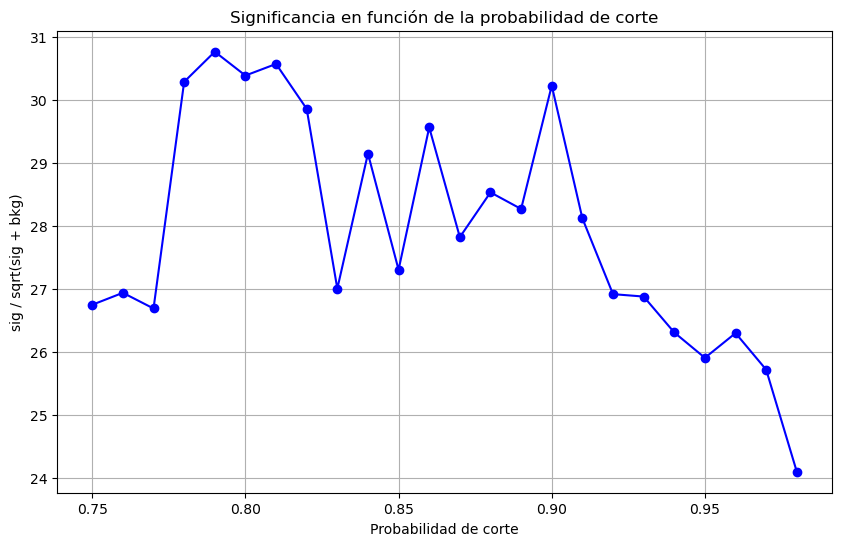

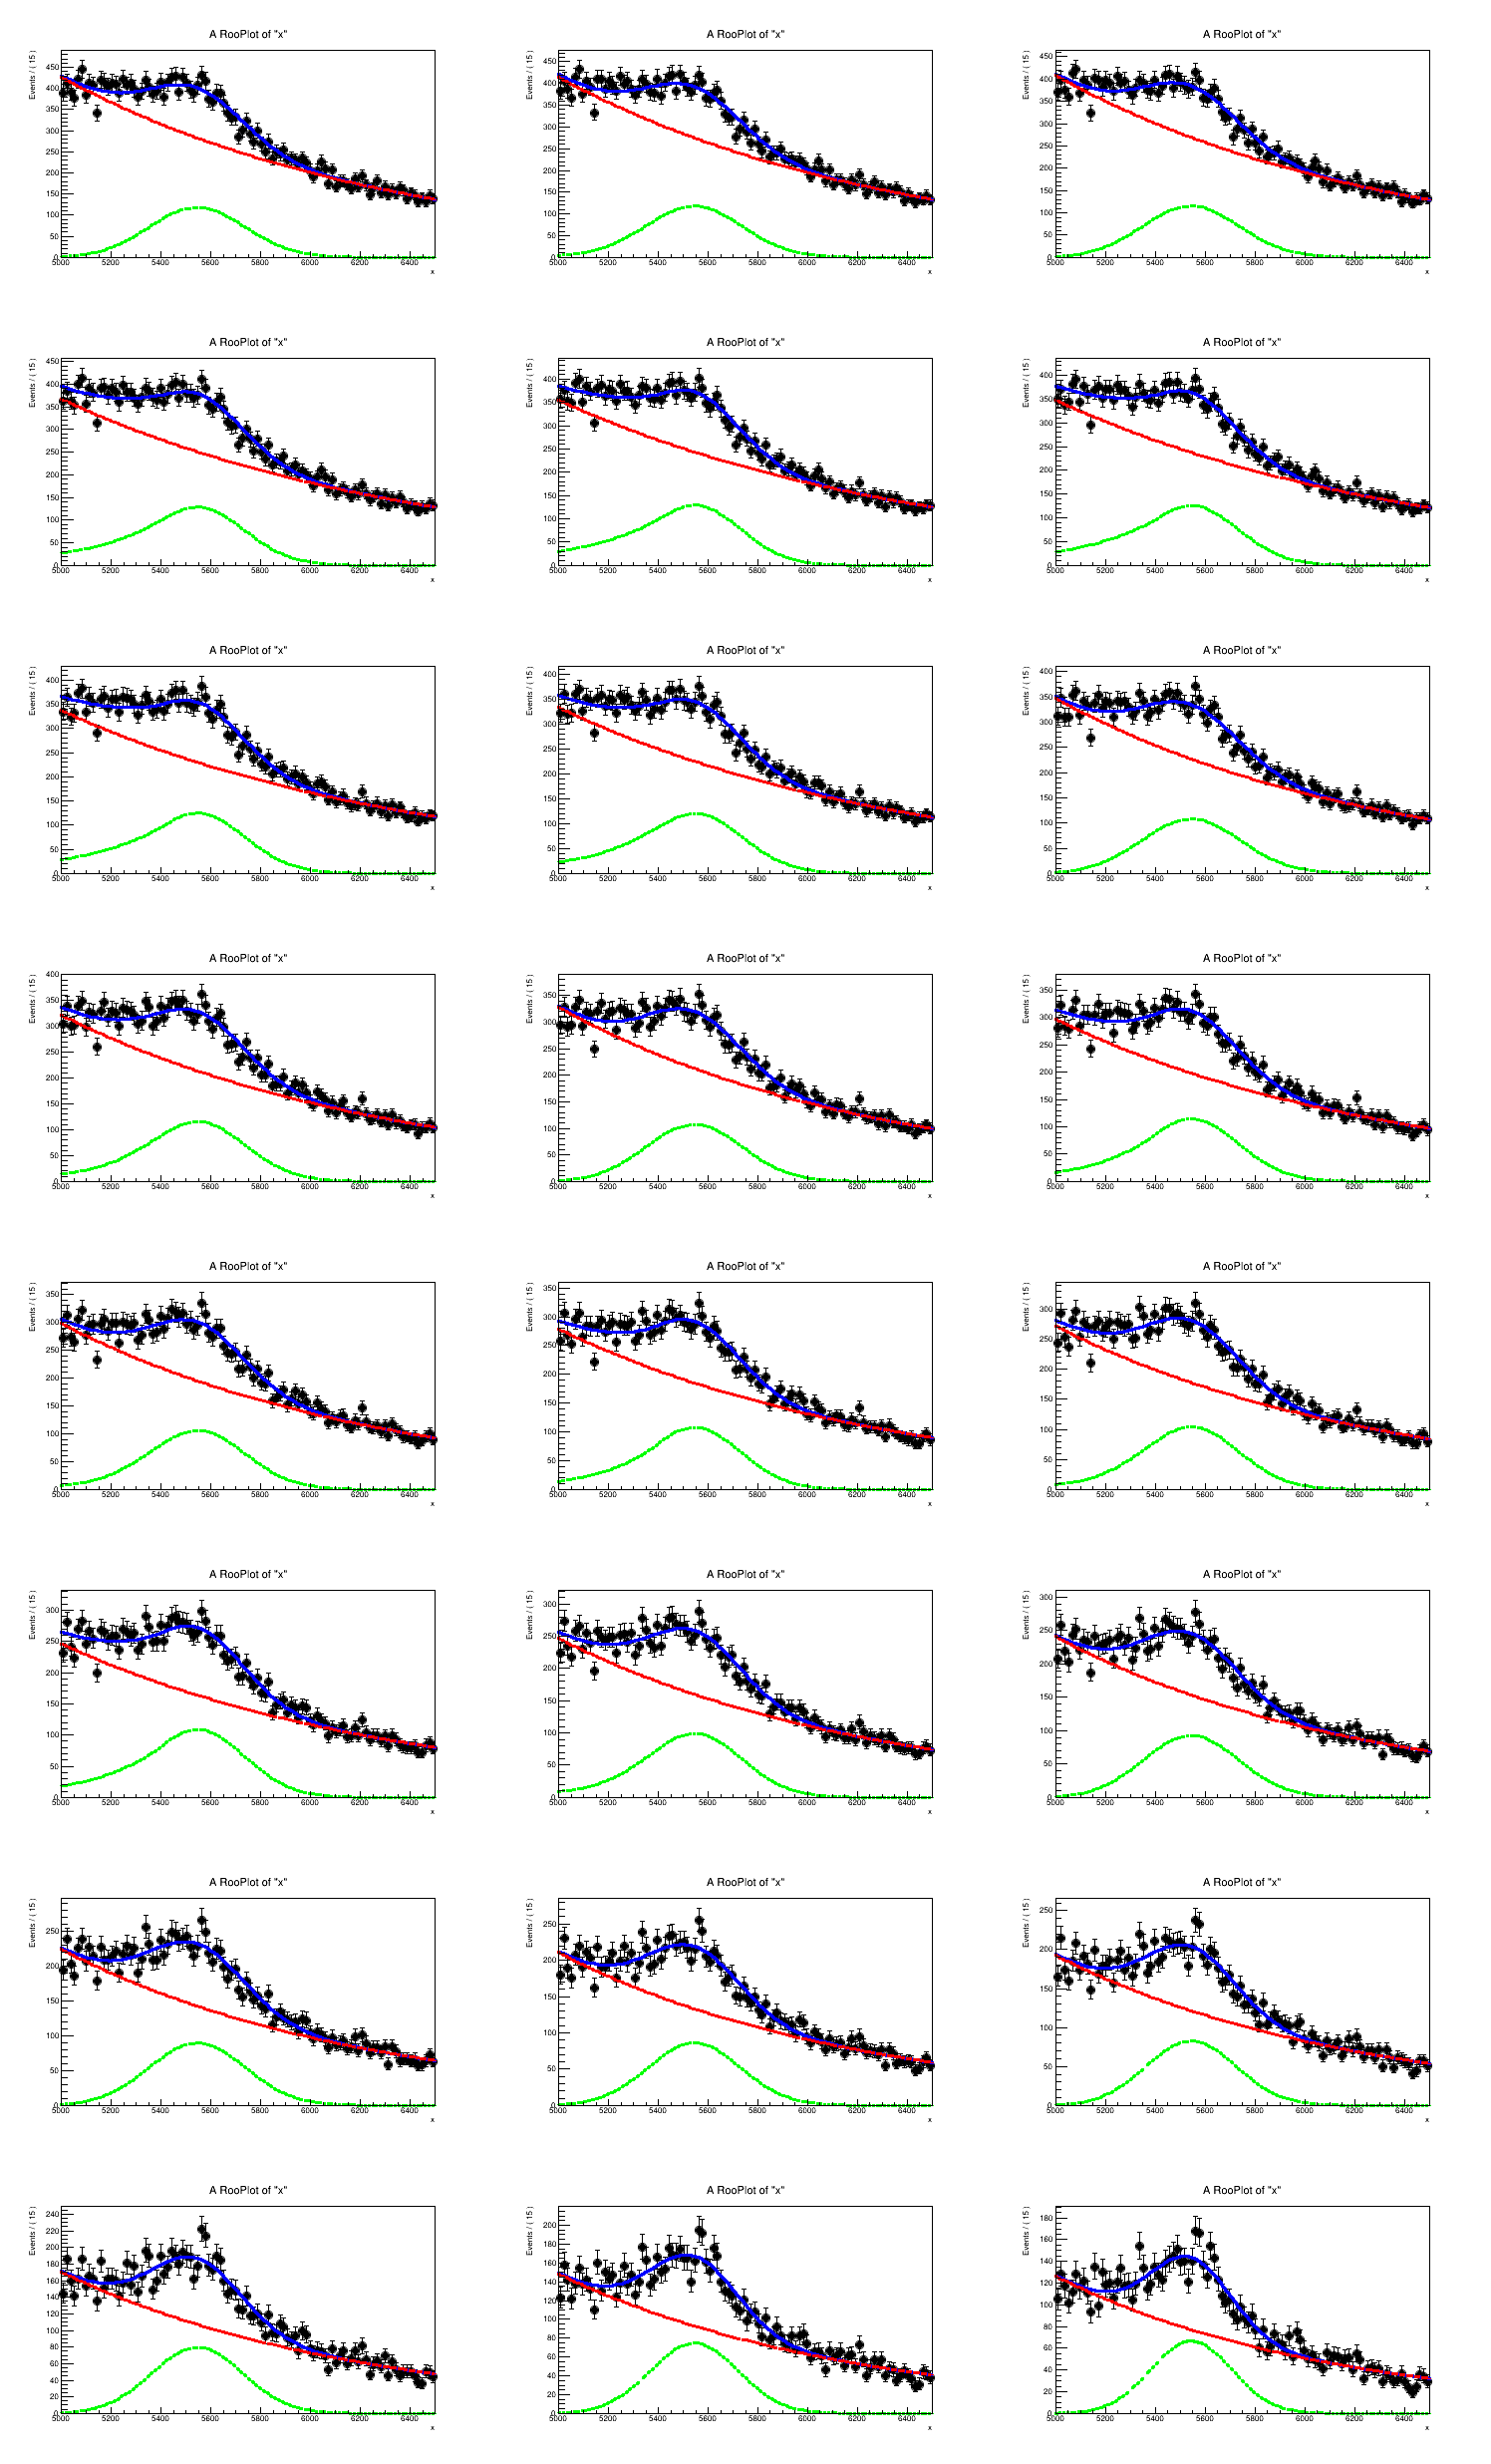

In [26]:
import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define el rango de probabilidad para evaluar
prob_start = 0.75
prob_end = 0.99
prob_step = 0.01  # Paso entre los valores de probabilidad

# Genera los valores de probabilidad dentro del rango definido
prob_values = np.arange(prob_start, prob_end, prob_step)

# Listas para almacenar los valores de probabilidad y los correspondientes valores de la expresión
prob_list = []
sig_bkg_ratio_list = []

# Variables para almacenar el valor máximo y la probabilidad correspondiente
max_sig_bkg_ratio = -1
best_prob = None

# Crear un canvas para dibujar los 12 ajustes con un nombre único
canvas_name = f"canvas_{np.random.randint(1e6)}"
canvas = ROOT.TCanvas(canvas_name, "Fits", 1500, 2500)
canvas.Divide(3, 8)  # 3 columnas por 4 filas

# Itera sobre diferentes valores de 'prob'
for i, prob_threshold in enumerate(prob_values):
    # Filtra los datos según el valor actual de 'prob'
    filtered_mass = data24_magdown.loc[
        (data24_magdown['prob'] > prob_threshold), 
        'Lb_MASS'
    ]

    # Convierte la Serie de pandas filtrada a un RooDataSet
    x = ROOT.RooRealVar('x', 'x', 5000, 6500)
    data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
    for mass in filtered_mass:
        x.setVal(mass)
        data_list.add(ROOT.RooArgSet(x))

    # Define los parámetros para la señal Double Crystal Ball, con sigmean fijo en 6012
    sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 5545)
    sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 120, 100, 300)
    
    # Parámetros de la cola izquierda
    alpha1 = ROOT.RooRealVar('alpha1', 'alpha1', 1.5, 0.5, 100.0)
    n1 = ROOT.RooRealVar('n1', 'n1', 2, 0.1, 500)
    
    # Parámetros de la cola derecha
    alpha2 = ROOT.RooRealVar('alpha2', 'alpha2', 1.5, 0.5, 100.0)
    n2 = ROOT.RooRealVar('n2', 'n2', 2, 0.1, 500)
    
    # Crear dos Crystal Ball: uno para la cola izquierda y otro para la derecha
    cb_left = ROOT.RooCBShape('cb_left', 'Crystal Ball Left Tail', x, sigmean, sigwidth, alpha1, n1)
    cb_right = ROOT.RooCBShape('cb_right', 'Crystal Ball Right Tail', x, sigmean, sigwidth, alpha2, n2)
    
    # Combina las dos funciones Crystal Ball en un modelo compuesto
    frac = ROOT.RooRealVar('frac', 'frac', 0.5, 0.0, 1.0)
    signalModel = ROOT.RooAddPdf('signal', 'Double Crystal Ball', cb_left, cb_right, frac)

    # Define el parámetro para el fondo exponencial
    lambda_bg = ROOT.RooRealVar('lambda_bg', 'slope', -0.001, -1.0, 0.0)

    # Construye el modelo de fondo exponencial
    background = ROOT.RooExponential('background', 'background', x, lambda_bg)

    # Construye un modelo combinado de señal y fondo
    nsig = ROOT.RooRealVar('nsig', 'nsig', 1000, 100., 20000)
    nbkg = ROOT.RooRealVar('nbkg', 'nbkg', 400, 100., 60000)
    model = ROOT.RooAddPdf('model', 'model', ROOT.RooArgList(signalModel, background), ROOT.RooArgList(nsig, nbkg))

    # Realiza el ajuste total
    total_fit_result = model.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

    # Crear un nuevo intervalo para la integración en la región de 5300-5750 MeV
    x.setRange("signalRegion", 5300, 5750)
    
    # Integra el componente de la señal y el fondo en la región de 5300-5750 MeV
    integral_signal_region = signalModel.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("signalRegion"))
    integral_full_range = signalModel.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("full"))
    
    ratio_signal = integral_signal_region.getVal() / integral_full_range.getVal()
    S_rescaled = nsig.getVal() * ratio_signal
    
    # Integra el componente de fondo en la región de 5300-5750 MeV
    integral_bkg_region = background.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("signalRegion"))
    integral_bkg_full_range = background.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("full"))
    
    ratio_bkg = integral_bkg_region.getVal() / integral_bkg_full_range.getVal()
    B_rescaled = nbkg.getVal() * ratio_bkg
    
    # Calcula la nueva relación S_rescaled / sqrt(S_rescaled + B_rescaled)
    sig_bkg_ratio = S_rescaled / np.sqrt(S_rescaled + B_rescaled)
    
    # Almacena los valores en las listas
    prob_list.append(prob_threshold)
    sig_bkg_ratio_list.append(sig_bkg_ratio)
    
    if sig_bkg_ratio > max_sig_bkg_ratio:
        max_sig_bkg_ratio = sig_bkg_ratio
        best_prob = prob_threshold
    
    # Dibuja los resultados del ajuste en el canvas
    canvas.cd(i+1)
    frame = x.frame()
    data_list.plotOn(frame)
    model.plotOn(frame)
    model.plotOn(frame, ROOT.RooFit.Components("background"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kRed))
    model.plotOn(frame, ROOT.RooFit.Components("signal"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kGreen))
    frame.Draw()

# Muestra el canvas con los 12 ajustes
canvas.Update()
canvas.Draw()

# Imprime el valor máximo y la probabilidad correspondiente
print(f"El valor máximo de sig / (sig + bkg)^0.5 es {max_sig_bkg_ratio} para prob = {best_prob}")

# Graficar los resultados de la significancia en función de la probabilidad
plt.figure(figsize=(10, 6))
plt.plot(prob_list, sig_bkg_ratio_list, marker='o', linestyle='-', color='b')
plt.xlabel('Probabilidad de corte')
plt.ylabel('sig / sqrt(sig + bkg)')
plt.title('Significancia en función de la probabilidad de corte')
plt.grid(True)
plt.show()


El valor máximo de sig / sqrt(sig + bkg) es 28.14268374914775 para prob = 0.9000000000000001


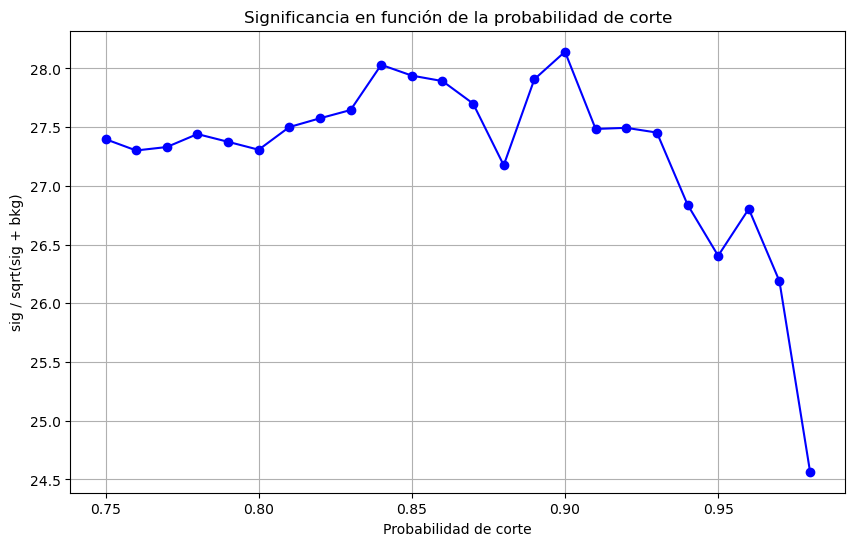

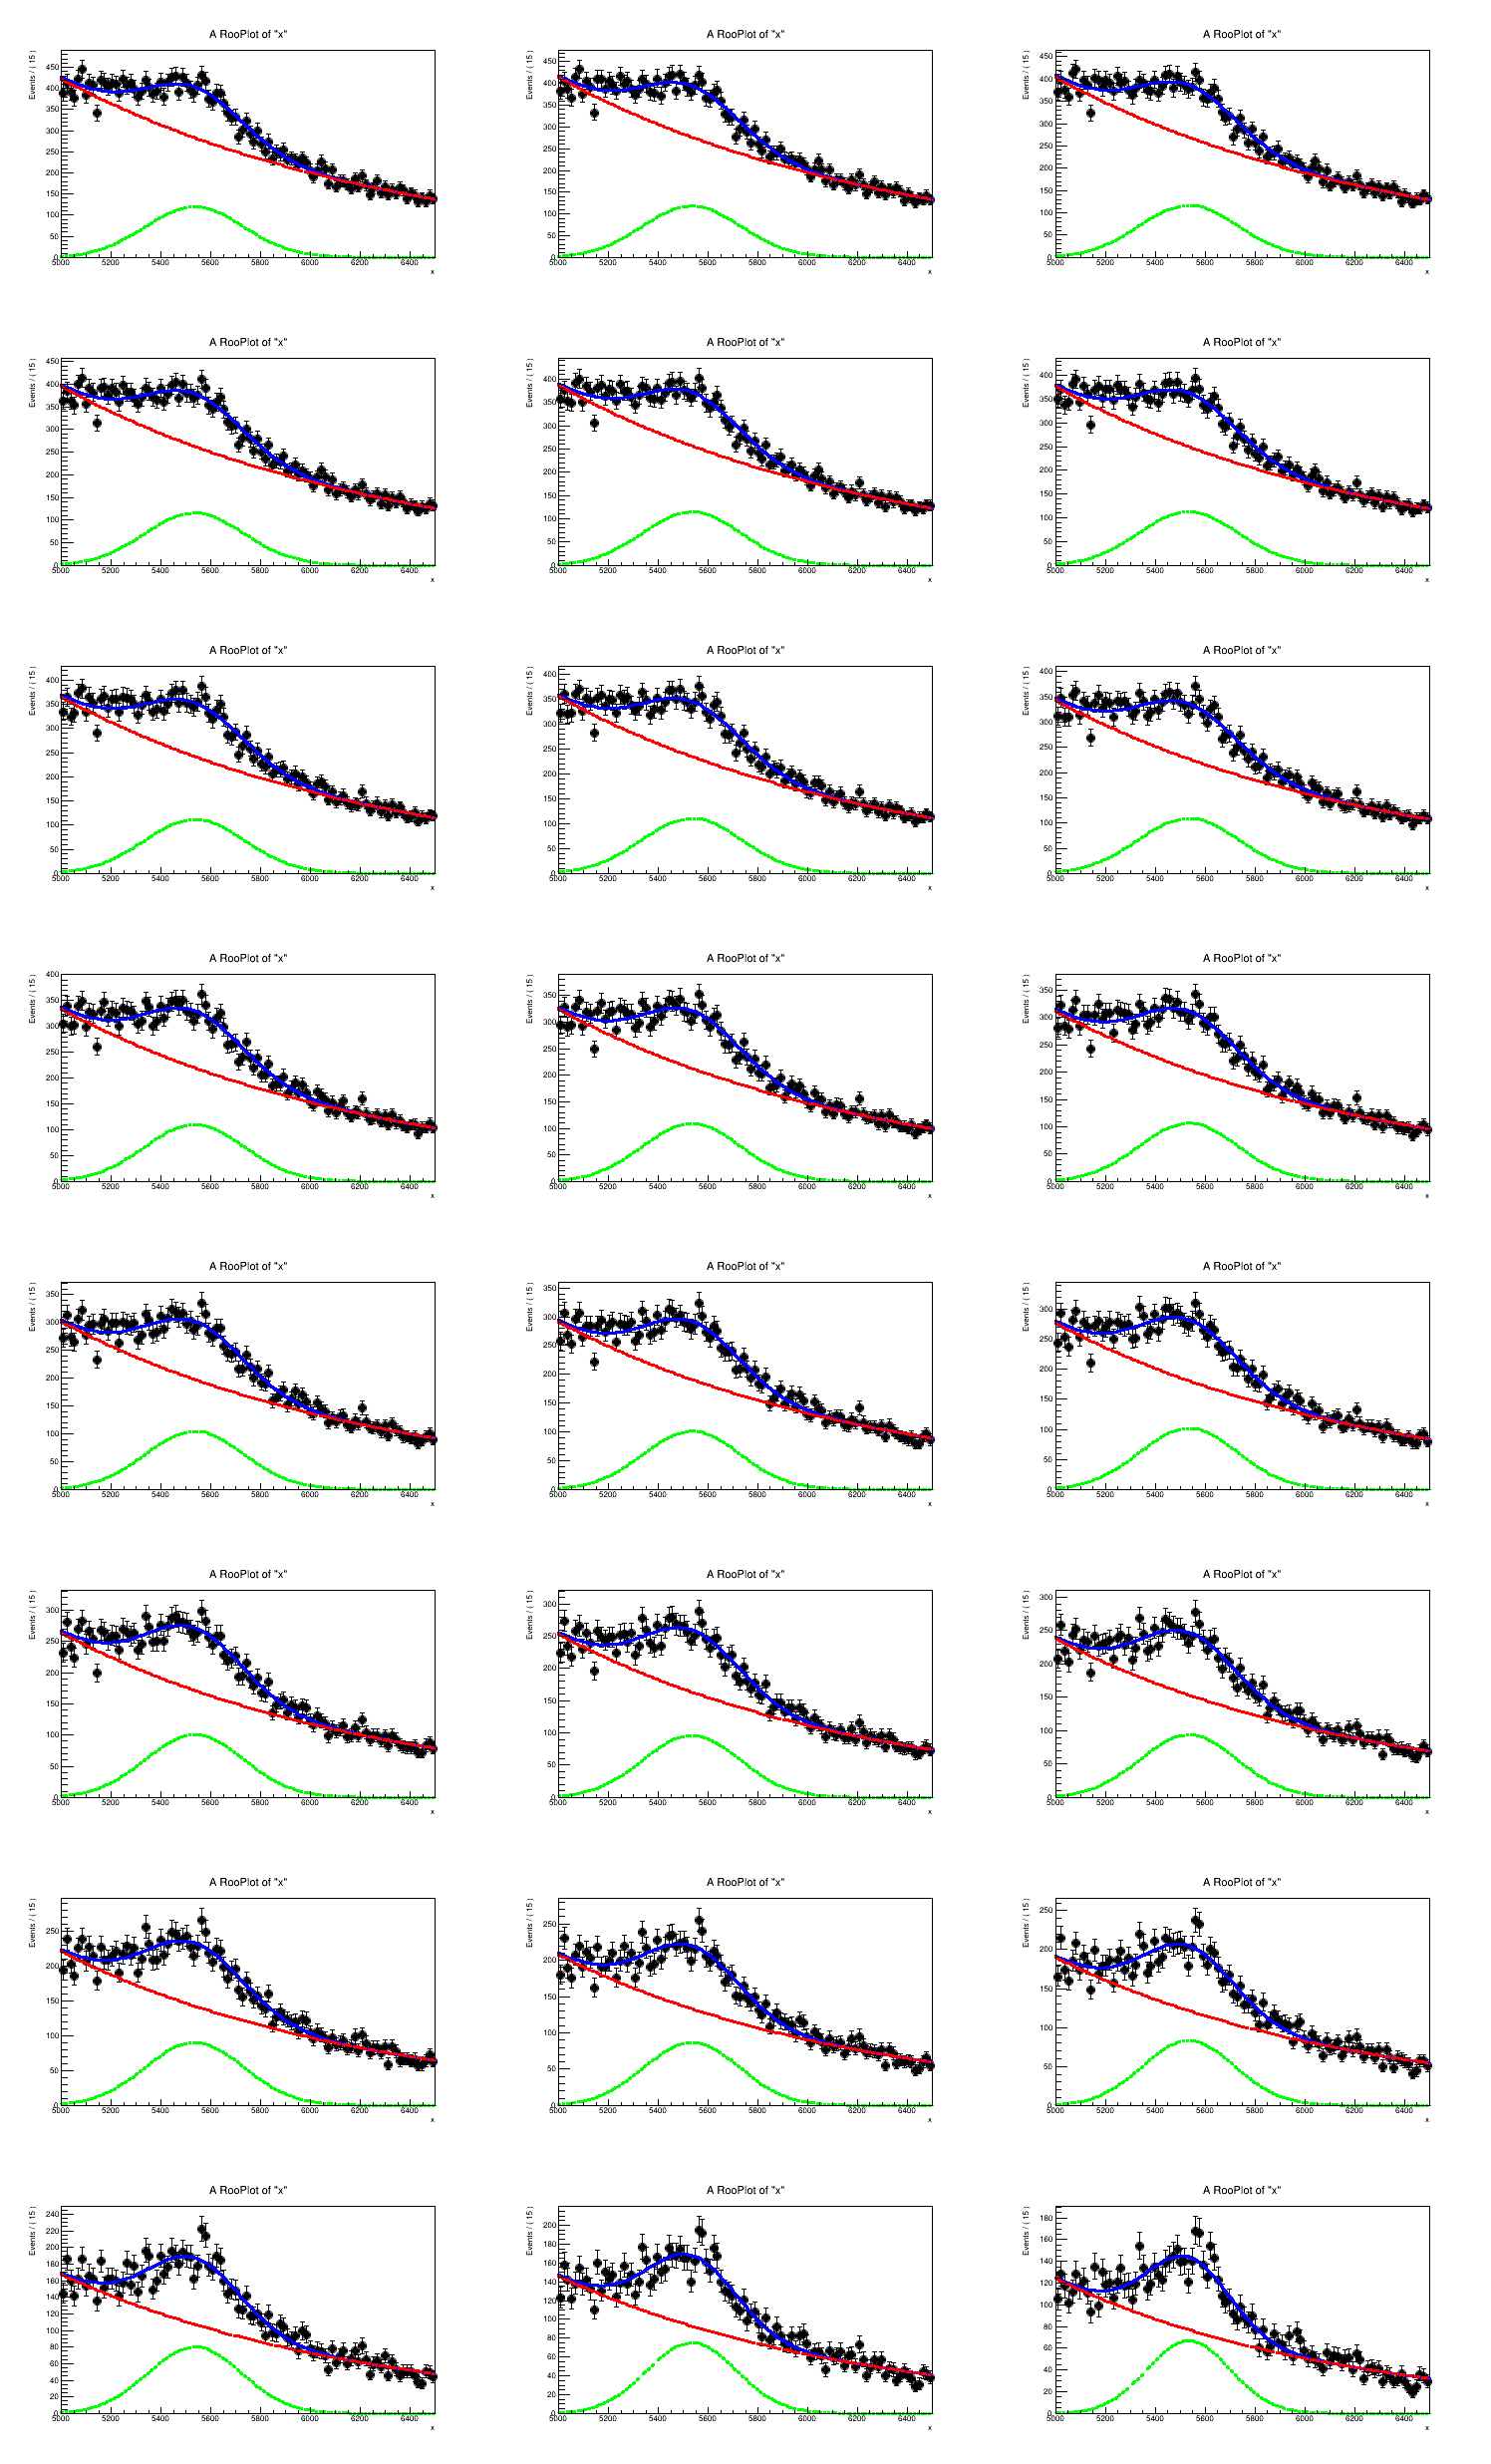

In [30]:
import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define el rango de probabilidad para evaluar
prob_start = 0.75
prob_end = 0.99
prob_step = 0.01  # Paso entre los valores de probabilidad

# Genera los valores de probabilidad dentro del rango definido
prob_values = np.arange(prob_start, prob_end, prob_step)

# Listas para almacenar los valores de probabilidad y los correspondientes valores de la expresión
prob_list = []
sig_bkg_ratio_list = []

# Variables para almacenar el valor máximo y la probabilidad correspondiente
max_sig_bkg_ratio = -1
best_prob = None

# Crear un canvas para dibujar los 12 ajustes con un nombre único
canvas_name = f"canvas_{np.random.randint(1e6)}"
canvas = ROOT.TCanvas(canvas_name, "Fits", 1500, 2500)
canvas.Divide(3, 8)  # 3 columnas por 8 filas

# Itera sobre diferentes valores de 'prob'
for i, prob_threshold in enumerate(prob_values):
    # Filtra los datos según el valor actual de 'prob'
    filtered_mass = data24_magdown.loc[
        (data24_magdown['prob'] > prob_threshold), 
        'Lb_MASS'
    ]

    # Convierte la Serie de pandas filtrada a un RooDataSet
    x = ROOT.RooRealVar('x', 'x', 5000, 6500)
    data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
    for mass in filtered_mass:
        x.setVal(mass)
        data_list.add(ROOT.RooArgSet(x))

    # Define los parámetros para la señal usando una función Gaussiana
    sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 5535)
    sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 120, 100, 300)
    
    # Crear la función Gaussiana
    signalModel = ROOT.RooGaussian('signal', 'Gaussian Signal', x, sigmean, sigwidth)

    # Define el parámetro para el fondo exponencial
    lambda_bg = ROOT.RooRealVar('lambda_bg', 'slope', -0.001, -1.0, 0.0)

    # Construye el modelo de fondo exponencial
    background = ROOT.RooExponential('background', 'background', x, lambda_bg)

    # Construye un modelo combinado de señal y fondo
    nsig = ROOT.RooRealVar('nsig', 'nsig', 1000, 100., 20000)
    nbkg = ROOT.RooRealVar('nbkg', 'nbkg', 400, 100., 60000)
    model = ROOT.RooAddPdf('model', 'model', ROOT.RooArgList(signalModel, background), ROOT.RooArgList(nsig, nbkg))

    # Realiza el ajuste total
    total_fit_result = model.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

    # Crear un nuevo intervalo para la integración en la región de 5300-5750 MeV
    x.setRange("signalRegion", 5300, 5750)
    
    # Integra el componente de la señal y el fondo en la región de 5300-5750 MeV
    integral_signal_region = signalModel.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("signalRegion"))
    integral_full_range = signalModel.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("full"))
    
    ratio_signal = integral_signal_region.getVal() / integral_full_range.getVal()
    S_rescaled = nsig.getVal() * ratio_signal
    
    # Integra el componente de fondo en la región de 5300-5750 MeV
    integral_bkg_region = background.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("signalRegion"))
    integral_bkg_full_range = background.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("full"))
    
    ratio_bkg = integral_bkg_region.getVal() / integral_bkg_full_range.getVal()
    B_rescaled = nbkg.getVal() * ratio_bkg
    
    # Calcula la nueva relación S_rescaled / sqrt(S_rescaled + B_rescaled)
    sig_bkg_ratio = S_rescaled / np.sqrt(S_rescaled + B_rescaled)
    
    # Almacena los valores en las listas
    prob_list.append(prob_threshold)
    sig_bkg_ratio_list.append(sig_bkg_ratio)
    
    if sig_bkg_ratio > max_sig_bkg_ratio:
        max_sig_bkg_ratio = sig_bkg_ratio
        best_prob = prob_threshold
    
    # Dibuja los resultados del ajuste en el canvas
    canvas.cd(i+1)
    frame = x.frame()
    data_list.plotOn(frame)
    model.plotOn(frame)
    model.plotOn(frame, ROOT.RooFit.Components("background"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kRed))
    model.plotOn(frame, ROOT.RooFit.Components("signal"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kGreen))
    frame.Draw()

# Muestra el canvas con los 12 ajustes
canvas.Update()
canvas.Draw()

# Imprime el valor máximo y la probabilidad correspondiente
print(f"El valor máximo de sig / sqrt(sig + bkg) es {max_sig_bkg_ratio} para prob = {best_prob}")

# Graficar los resultados de la significancia en función de la probabilidad
plt.figure(figsize=(10, 6))
plt.plot(prob_list, sig_bkg_ratio_list, marker='o', linestyle='-', color='b')
plt.xlabel('Probabilidad de corte')
plt.ylabel('sig / sqrt(sig + bkg)')
plt.title('Significancia en función de la probabilidad de corte')
plt.grid(True)
plt.show()


El valor máximo de sig / sqrt(sig + bkg) es 31.460580519083848 para prob = 0.8800000000000001


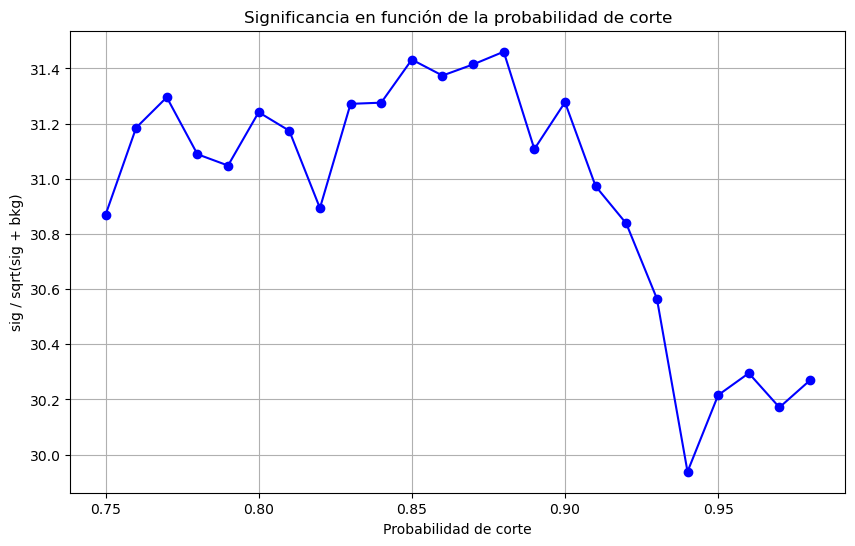

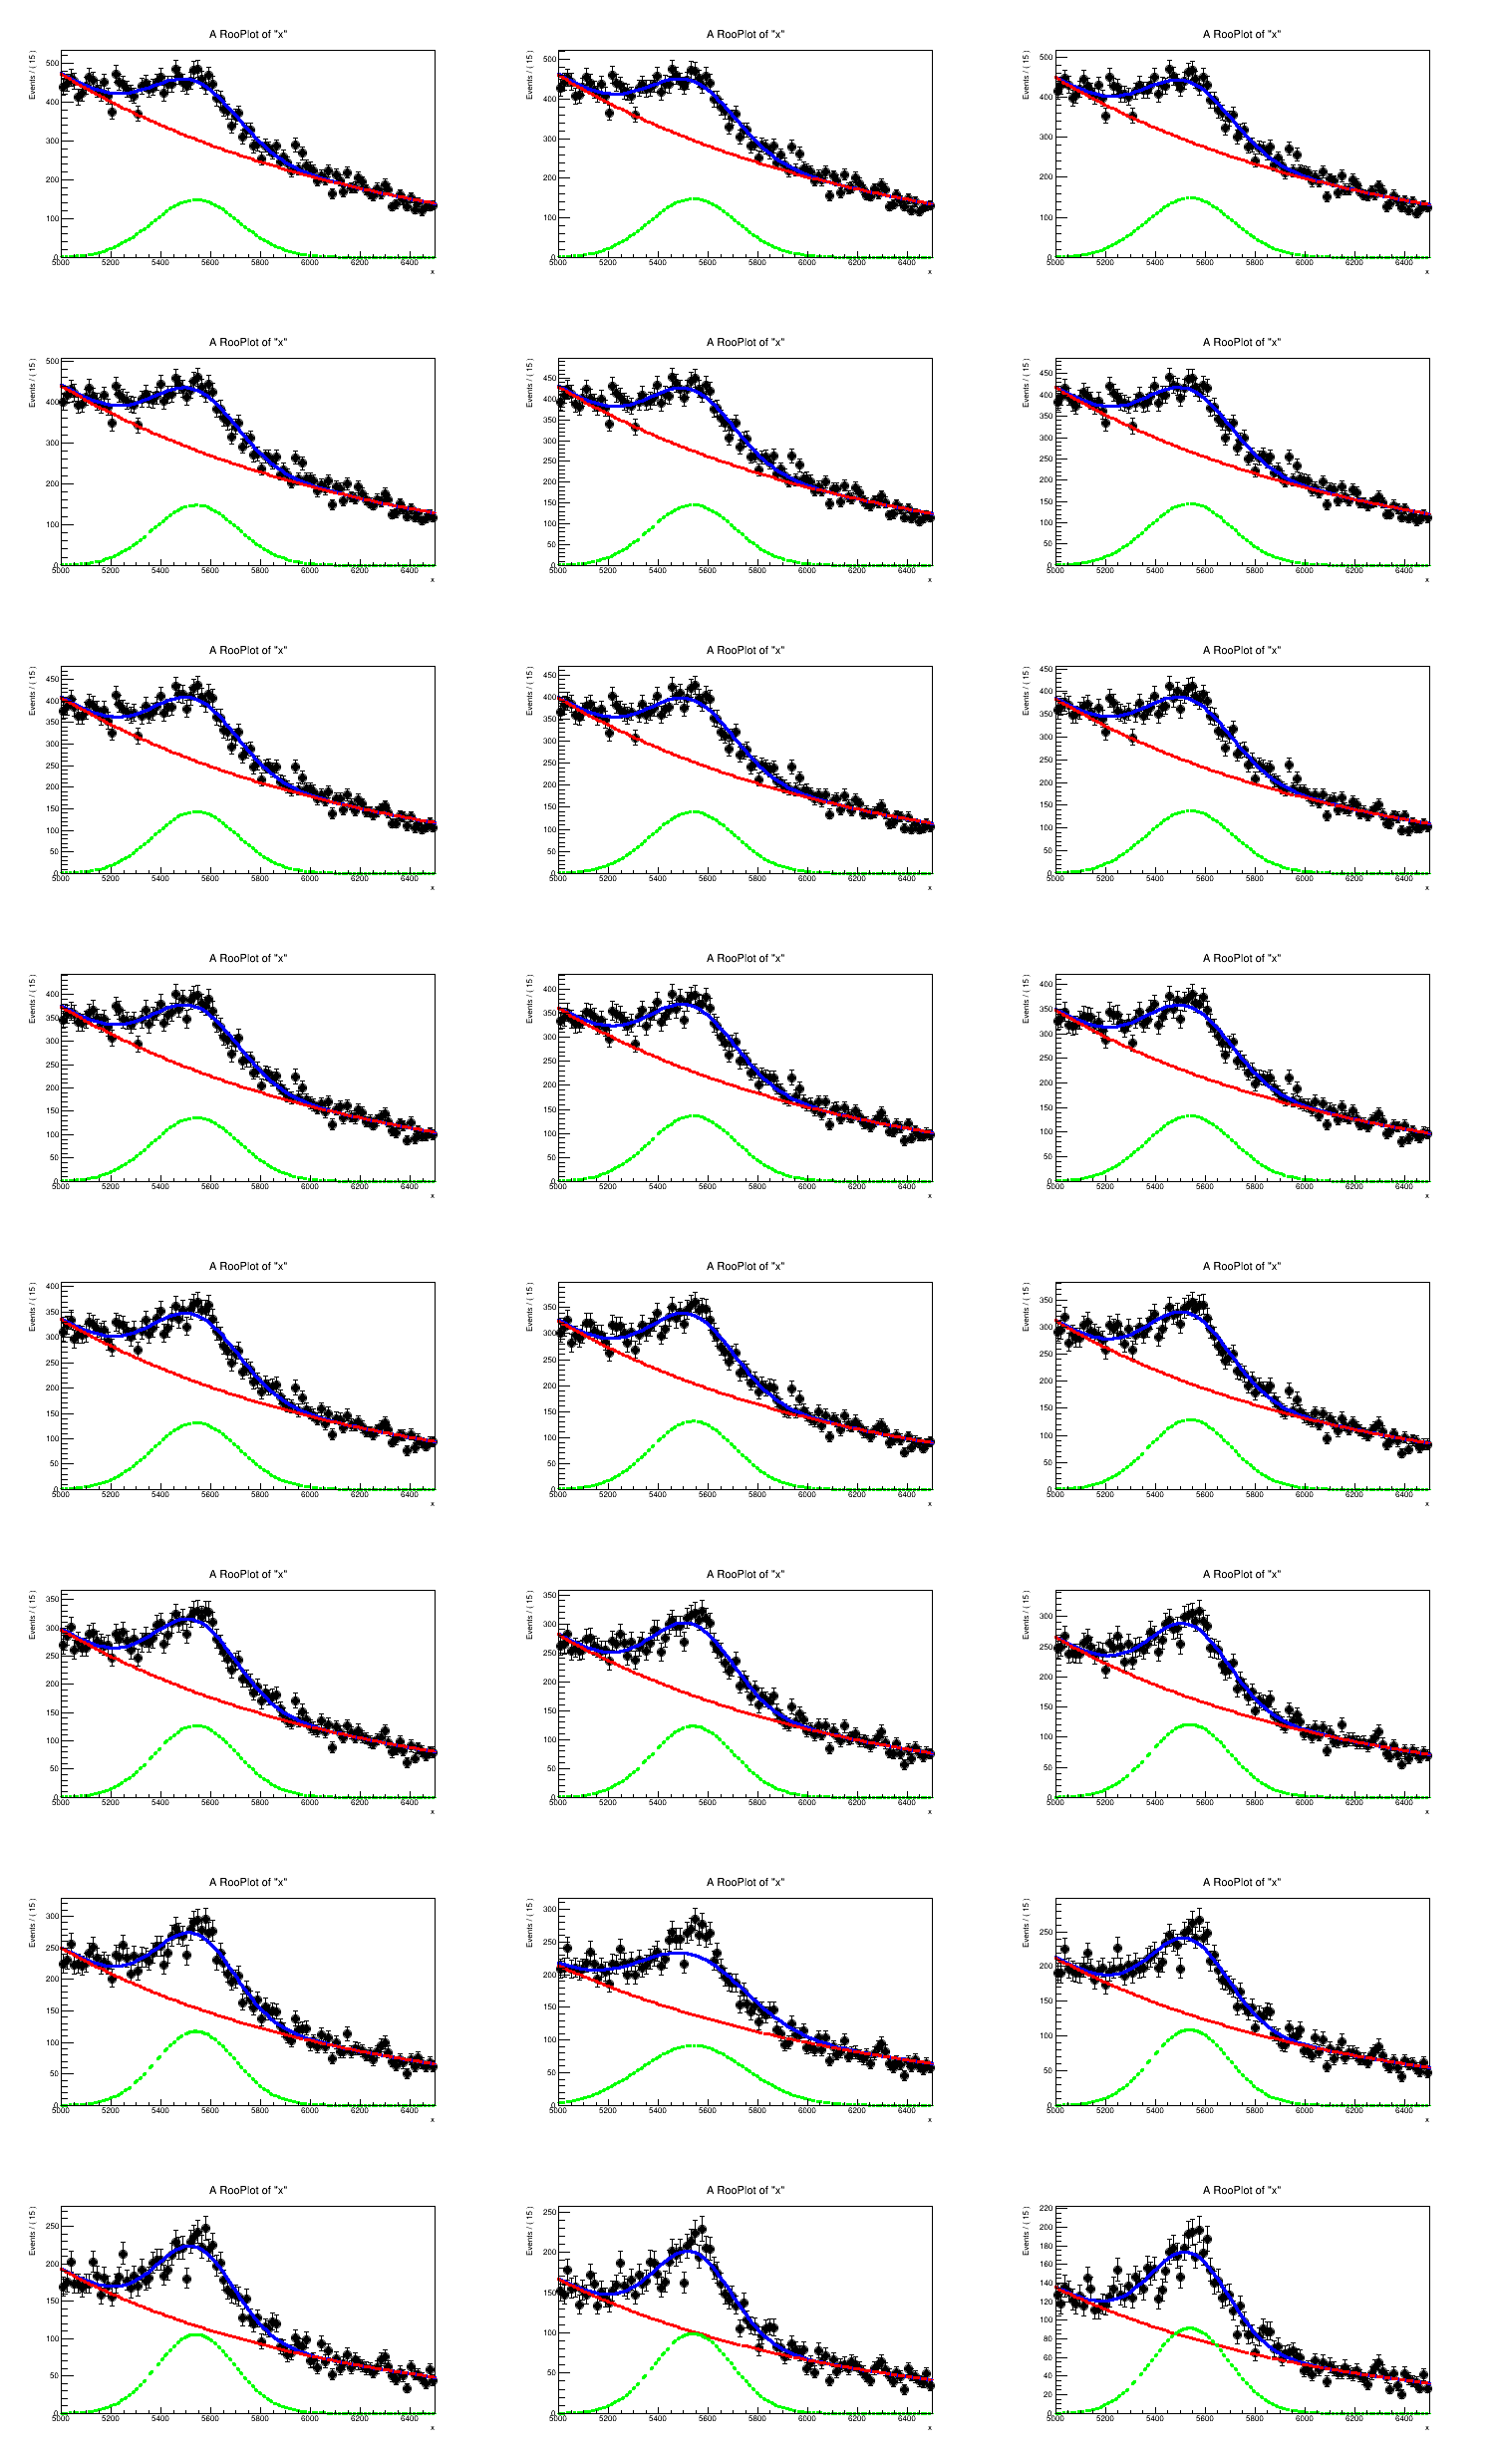

In [20]:
import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define el rango de probabilidad para evaluar
prob_start = 0.75
prob_end = 0.99
prob_step = 0.01  # Paso entre los valores de probabilidad

# Genera los valores de probabilidad dentro del rango definido
prob_values = np.arange(prob_start, prob_end, prob_step)

# Listas para almacenar los valores de probabilidad y los correspondientes valores de la expresión
prob_list = []
sig_bkg_ratio_list = []

# Variables para almacenar el valor máximo y la probabilidad correspondiente
max_sig_bkg_ratio = -1
best_prob = None

# Crear un canvas para dibujar los 12 ajustes con un nombre único
canvas_name = f"canvas_{np.random.randint(1e6)}"
canvas = ROOT.TCanvas(canvas_name, "Fits", 1500, 2500)
canvas.Divide(3, 8)  # 3 columnas por 8 filas

# Itera sobre diferentes valores de 'prob'
for i, prob_threshold in enumerate(prob_values):
    # Filtra los datos según el valor actual de 'prob'
    filtered_mass = data24_magup.loc[
        (data24_magup['prob'] > prob_threshold), 
        'Lb_MASS'
    ]

    # Convierte la Serie de pandas filtrada a un RooDataSet
    x = ROOT.RooRealVar('x', 'x', 5000, 6500)
    data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
    for mass in filtered_mass:
        x.setVal(mass)
        data_list.add(ROOT.RooArgSet(x))

    # Define los parámetros para la señal usando una función Gaussiana
    sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 5540)
    sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 120, 100, 300)
    
    # Crear la función Gaussiana
    signalModel = ROOT.RooGaussian('signal', 'Gaussian Signal', x, sigmean, sigwidth)

    # Define el parámetro para el fondo exponencial
    lambda_bg = ROOT.RooRealVar('lambda_bg', 'slope', -0.001, -1.0, 0.0)

    # Construye el modelo de fondo exponencial
    background = ROOT.RooExponential('background', 'background', x, lambda_bg)

    # Construye un modelo combinado de señal y fondo
    nsig = ROOT.RooRealVar('nsig', 'nsig', 1000, 100., 20000)
    nbkg = ROOT.RooRealVar('nbkg', 'nbkg', 400, 100., 60000)
    model = ROOT.RooAddPdf('model', 'model', ROOT.RooArgList(signalModel, background), ROOT.RooArgList(nsig, nbkg))

    # Realiza el ajuste total
    total_fit_result = model.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

    # Crear un nuevo intervalo para la integración en la región de 5300-5750 MeV
    x.setRange("signalRegion", 5300, 5750)
    
    # Integra el componente de la señal y el fondo en la región de 5300-5750 MeV
    integral_signal_region = signalModel.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("signalRegion"))
    integral_full_range = signalModel.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("full"))
    
    ratio_signal = integral_signal_region.getVal() / integral_full_range.getVal()
    S_rescaled = nsig.getVal() * ratio_signal
    
    # Integra el componente de fondo en la región de 5300-5750 MeV
    integral_bkg_region = background.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("signalRegion"))
    integral_bkg_full_range = background.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("full"))
    
    ratio_bkg = integral_bkg_region.getVal() / integral_bkg_full_range.getVal()
    B_rescaled = nbkg.getVal() * ratio_bkg
    
    # Calcula la nueva relación S_rescaled / sqrt(S_rescaled + B_rescaled)
    sig_bkg_ratio = S_rescaled / np.sqrt(S_rescaled + B_rescaled)
    
    # Almacena los valores en las listas
    prob_list.append(prob_threshold)
    sig_bkg_ratio_list.append(sig_bkg_ratio)
    
    if sig_bkg_ratio > max_sig_bkg_ratio:
        max_sig_bkg_ratio = sig_bkg_ratio
        best_prob = prob_threshold
    
    # Dibuja los resultados del ajuste en el canvas
    canvas.cd(i+1)
    frame = x.frame()
    data_list.plotOn(frame)
    model.plotOn(frame)
    model.plotOn(frame, ROOT.RooFit.Components("background"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kRed))
    model.plotOn(frame, ROOT.RooFit.Components("signal"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kGreen))
    frame.Draw()

# Muestra el canvas con los 12 ajustes
canvas.Update()
canvas.Draw()

# Imprime el valor máximo y la probabilidad correspondiente
print(f"El valor máximo de sig / sqrt(sig + bkg) es {max_sig_bkg_ratio} para prob = {best_prob}")

# Graficar los resultados de la significancia en función de la probabilidad
plt.figure(figsize=(10, 6))
plt.plot(prob_list, sig_bkg_ratio_list, marker='o', linestyle='-', color='b')
plt.xlabel('Probabilidad de corte')
plt.ylabel('sig / sqrt(sig + bkg)')
plt.title('Significancia en función de la probabilidad de corte')
plt.grid(True)
plt.show()


In [31]:
# import ROOT
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # Define el rango de probabilidad para evaluar
# prob_start = 0.75
# prob_end = 0.99
# prob_step = 0.01  # Paso entre los valores de probabilidad

# # Genera los valores de probabilidad dentro del rango definido
# prob_values = np.arange(prob_start, prob_end, prob_step)

# # Listas para almacenar los valores de probabilidad y los correspondientes valores de la expresión
# prob_list = []
# sig_bkg_ratio_list = []

# # Variables para almacenar el valor máximo y la probabilidad correspondiente
# max_sig_bkg_ratio = -1
# best_prob = None

# # Lista personalizada de valores de sigmean (28 valores)
# sigmean_values = [
#     5550, 5550, 5550, 5550, 5550, 5550, 5550, 5550,
#     5550, 5550, 5550, 5550, 5550, 5550, 5550, 5550,
#     5550, 5550, 5550, 5550, 5550, 5550, 5550, 5550,
#     5550, 5550, 5550, 5550
# ]

# # Crear un canvas para dibujar los 28 ajustes con un nombre único
# canvas_name = f"canvas_{np.random.randint(1e6)}"
# canvas = ROOT.TCanvas(canvas_name, "Fits", 1500, 2500)
# canvas.Divide(3, 8)  # 3 columnas por 8 filas

# # Itera sobre diferentes valores de 'prob'
# for i, prob_threshold in enumerate(prob_values):
#     # Filtra los datos según el valor actual de 'prob'
#     filtered_mass = data24_magup.loc[
#         (data24_magup['prob'] > prob_threshold), 
#         'Lb_MASS'
#     ]

#     # Convierte la Serie de pandas filtrada a un RooDataSet
#     x = ROOT.RooRealVar('x', 'x', 5000, 6500)
#     data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
#     for mass in filtered_mass:
#         x.setVal(mass)
#         data_list.add(ROOT.RooArgSet(x))

#     # Define el sigmean usando el valor correspondiente de la lista
#     sigmean = ROOT.RooRealVar('sigmean', 'sigmean', sigmean_values[i])
#     sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 120, 100, 300)
    
#     # Crear la función Gaussiana
#     signalModel = ROOT.RooGaussian('signal', 'Gaussian Signal', x, sigmean, sigwidth)

#     # Define el parámetro para el fondo exponencial
#     lambda_bg = ROOT.RooRealVar('lambda_bg', 'slope', -0.001, -1.0, 0.0)

#     # Construye el modelo de fondo exponencial
#     background = ROOT.RooExponential('background', 'background', x, lambda_bg)

#     # Construye un modelo combinado de señal y fondo
#     nsig = ROOT.RooRealVar('nsig', 'nsig', 1000, 100., 20000)
#     nbkg = ROOT.RooRealVar('nbkg', 'nbkg', 400, 100., 60000)
#     model = ROOT.RooAddPdf('model', 'model', ROOT.RooArgList(signalModel, background), ROOT.RooArgList(nsig, nbkg))

#     # Realiza el ajuste total
#     total_fit_result = model.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

#     # Crear un nuevo intervalo para la integración en la región de 5300-5750 MeV
#     x.setRange("signalRegion", 5300, 5750)
    
#     # Integra el componente de la señal y el fondo en la región de 5300-5750 MeV
#     integral_signal_region = signalModel.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("signalRegion"))
#     integral_full_range = signalModel.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("full"))
    
#     ratio_signal = integral_signal_region.getVal() / integral_full_range.getVal()
#     S_rescaled = nsig.getVal() * ratio_signal
    
#     # Integra el componente de fondo en la región de 5300-5750 MeV
#     integral_bkg_region = background.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("signalRegion"))
#     integral_bkg_full_range = background.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("full"))
    
#     ratio_bkg = integral_bkg_region.getVal() / integral_bkg_full_range.getVal()
#     B_rescaled = nbkg.getVal() * ratio_bkg
    
#     # Calcula la nueva relación S_rescaled / sqrt(S_rescaled + B_rescaled)
#     sig_bkg_ratio = S_rescaled / np.sqrt(S_rescaled + B_rescaled)
    
#     # Almacena los valores en las listas
#     prob_list.append(prob_threshold)
#     sig_bkg_ratio_list.append(sig_bkg_ratio)
    
#     if sig_bkg_ratio > max_sig_bkg_ratio:
#         max_sig_bkg_ratio = sig_bkg_ratio
#         best_prob = prob_threshold
    
#     # Dibuja los resultados del ajuste en el canvas
#     canvas.cd(i+1)
#     frame = x.frame()
#     data_list.plotOn(frame)
#     model.plotOn(frame)
#     model.plotOn(frame, ROOT.RooFit.Components("background"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kRed))
#     model.plotOn(frame, ROOT.RooFit.Components("signal"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kGreen))
#     frame.Draw()

# # Muestra el canvas con los 28 ajustes
# canvas.Update()
# canvas.Draw()

# # Imprime el valor máximo y la probabilidad correspondiente
# print(f"El valor máximo de sig / sqrt(sig + bkg) es {max_sig_bkg_ratio} para prob = {best_prob}")

# # Graficar los resultados de la significancia en función de la probabilidad
# plt.figure(figsize=(10, 6))
# plt.plot(prob_list, sig_bkg_ratio_list, marker='o', linestyle='-', color='b')
# plt.xlabel('Probabilidad de corte')
# plt.ylabel('sig / sqrt(sig + bkg)')
# plt.title('Significancia en función de la probabilidad de corte')
# plt.grid(True)
# plt.show()


El valor máximo de sig / sqrt(sig + bkg) es 31.55683464684529 para prob = 0.8500000000000001


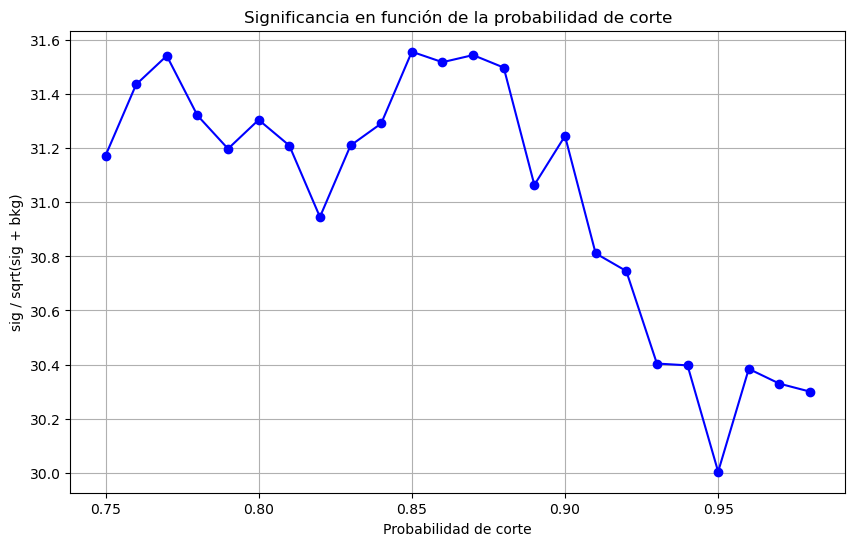

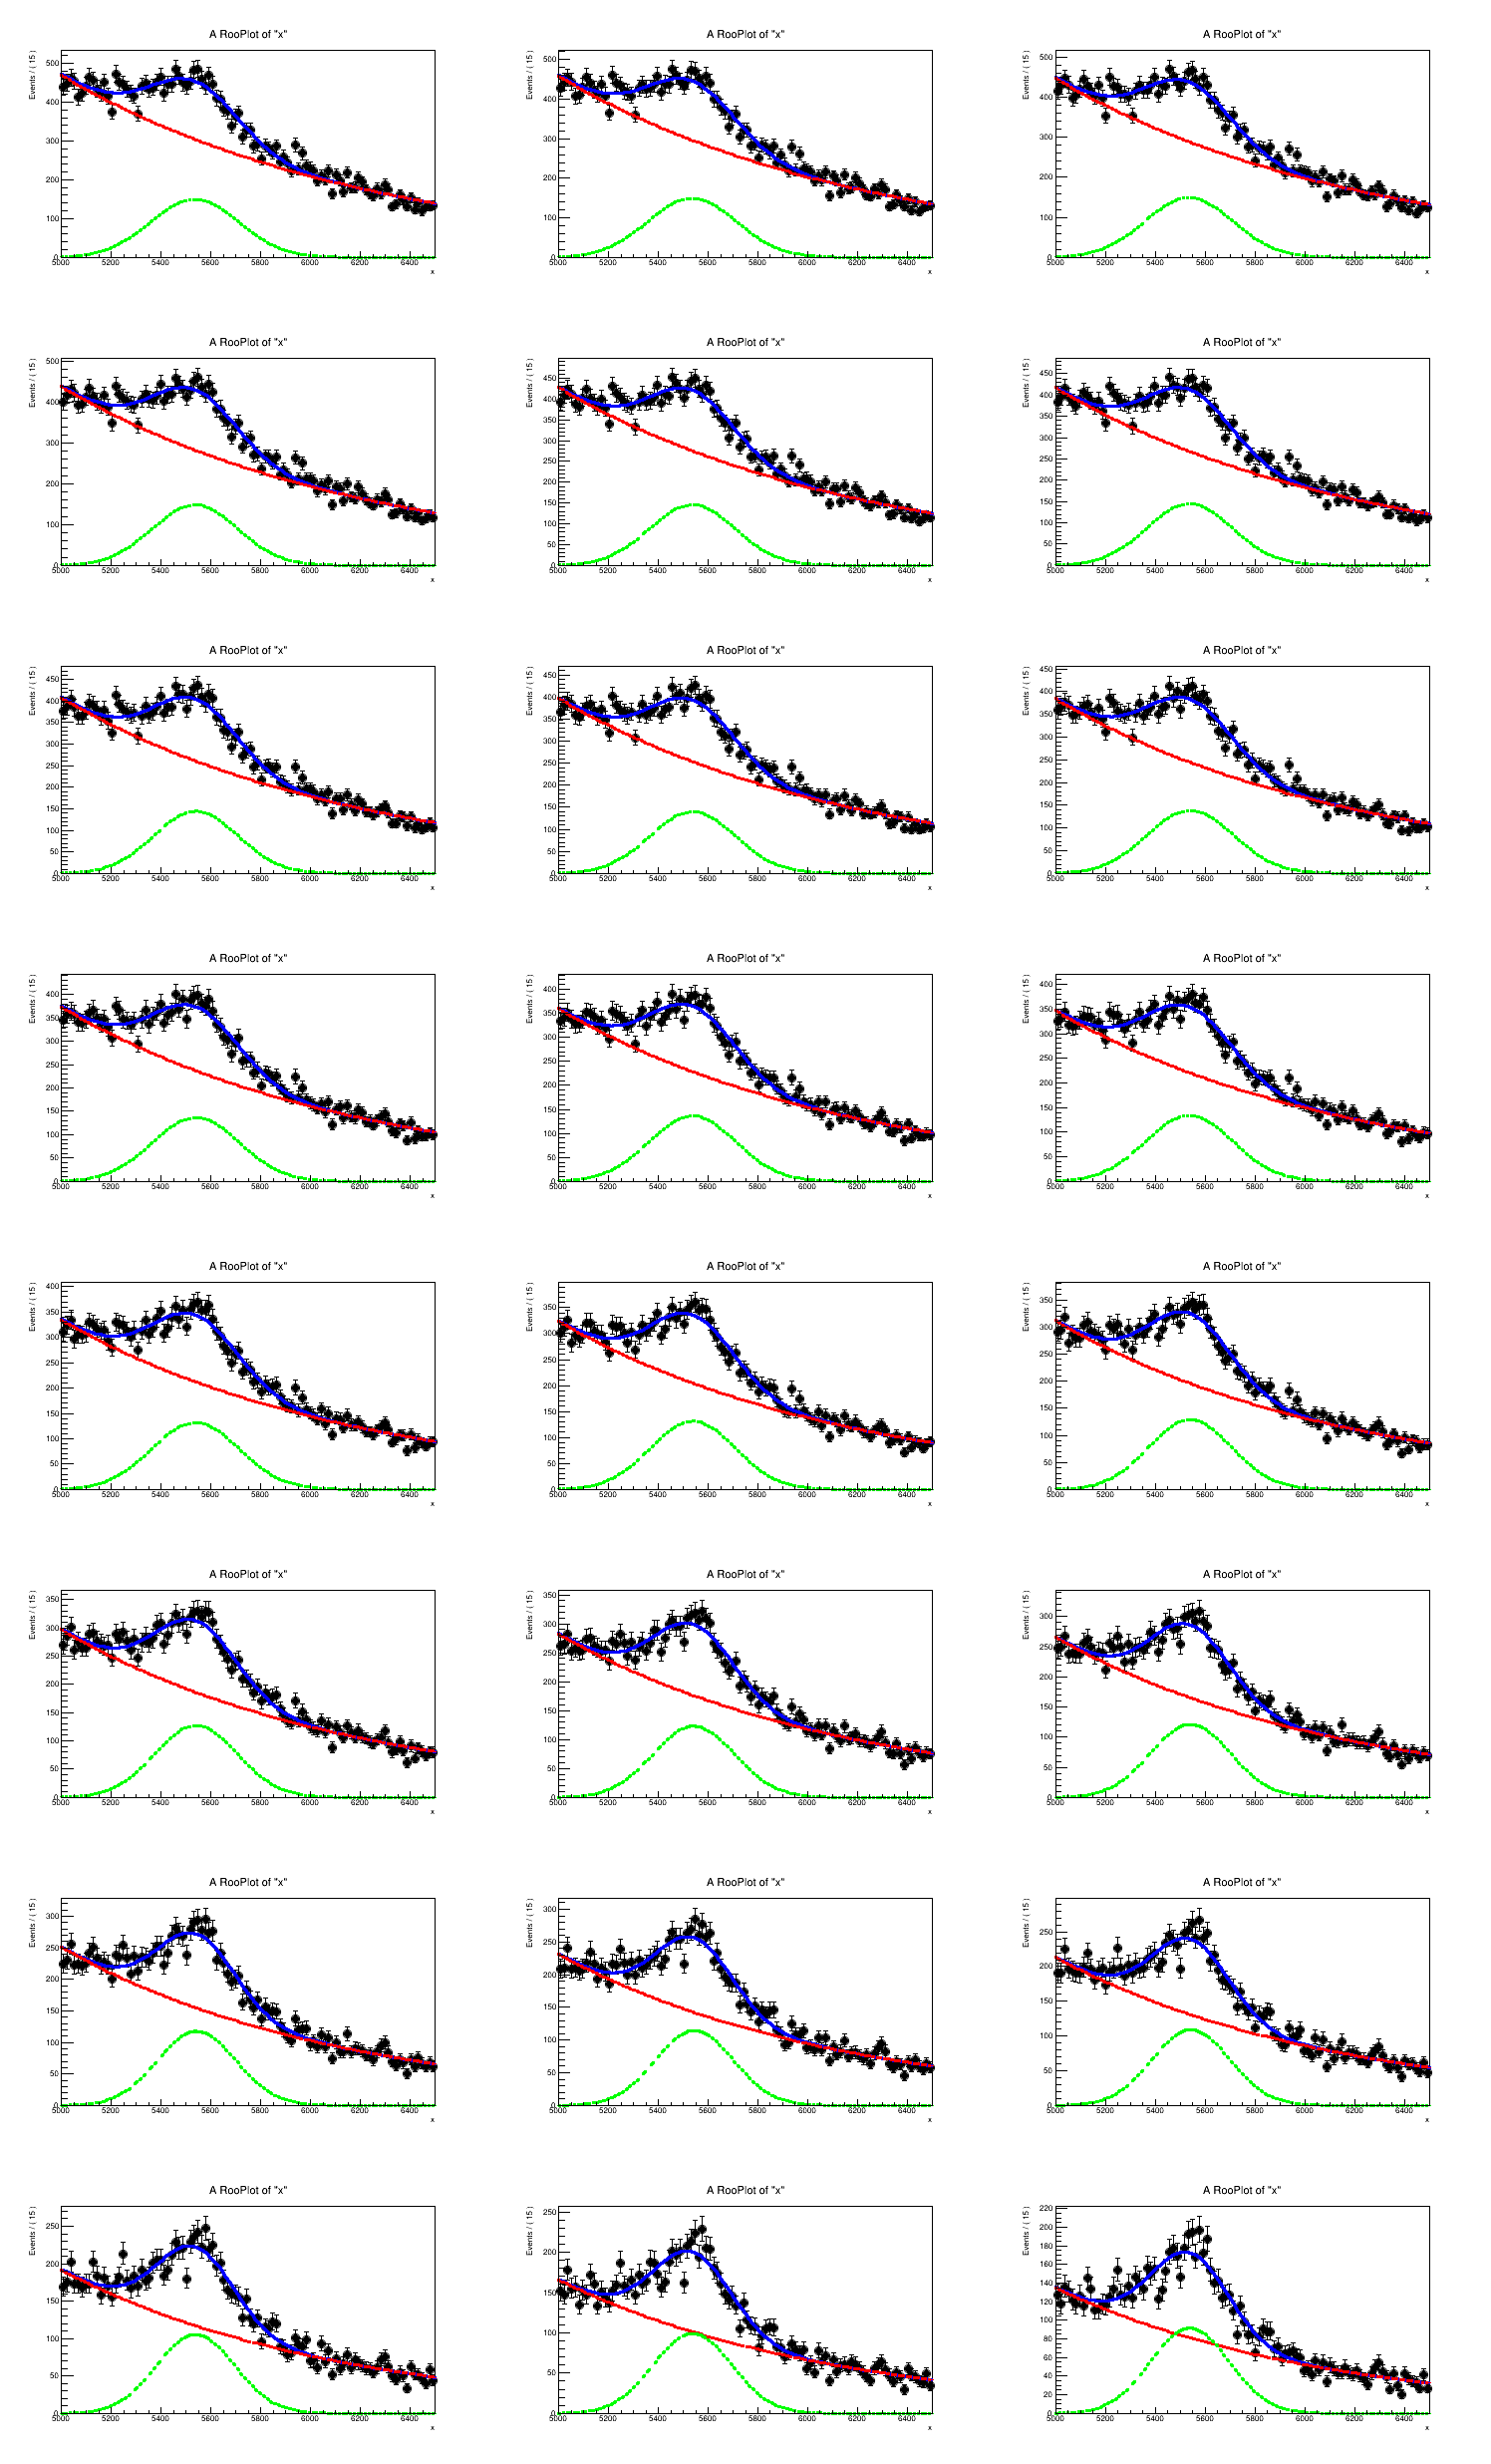

In [32]:
import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define el rango de probabilidad para evaluar
prob_start = 0.75
prob_end = 0.99
prob_step = 0.01  # Paso entre los valores de probabilidad

# Genera los valores de probabilidad dentro del rango definido
prob_values = np.arange(prob_start, prob_end, prob_step)

# Listas para almacenar los valores de probabilidad y los correspondientes valores de la expresión
prob_list = []
sig_bkg_ratio_list = []

# Variables para almacenar el valor máximo y la probabilidad correspondiente
max_sig_bkg_ratio = -1
best_prob = None

# Crear un canvas para dibujar los 12 ajustes con un nombre único
canvas_name = f"canvas_{np.random.randint(1e6)}"
canvas = ROOT.TCanvas(canvas_name, "Fits", 1500, 2500)
canvas.Divide(3, 8)  # 3 columnas por 8 filas

# Itera sobre diferentes valores de 'prob'
for i, prob_threshold in enumerate(prob_values):
    # Filtra los datos según el valor actual de 'prob'
    filtered_mass = data24_magup.loc[
        (data24_magup['prob'] > prob_threshold), 
        'Lb_MASS'
    ]

    # Convierte la Serie de pandas filtrada a un RooDataSet
    x = ROOT.RooRealVar('x', 'x', 5000, 6500)
    data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
    for mass in filtered_mass:
        x.setVal(mass)
        data_list.add(ROOT.RooArgSet(x))

    # Define los parámetros para la señal usando una función Gaussiana
    sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 5540, 5520, 5620)  # Permitir que flote en el rango 5500-5600
    sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 120, 100, 300)
    
    # Crear la función Gaussiana
    signalModel = ROOT.RooGaussian('signal', 'Gaussian Signal', x, sigmean, sigwidth)

    # Define el parámetro para el fondo exponencial
    lambda_bg = ROOT.RooRealVar('lambda_bg', 'slope', -0.001, -1.0, 0.0)

    # Construye el modelo de fondo exponencial
    background = ROOT.RooExponential('background', 'background', x, lambda_bg)

    # Construye un modelo combinado de señal y fondo
    nsig = ROOT.RooRealVar('nsig', 'nsig', 1000, 100., 20000)
    nbkg = ROOT.RooRealVar('nbkg', 'nbkg', 400, 100., 60000)
    model = ROOT.RooAddPdf('model', 'model', ROOT.RooArgList(signalModel, background), ROOT.RooArgList(nsig, nbkg))

    # Realiza el ajuste total
    total_fit_result = model.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

    # Crear un nuevo intervalo para la integración en la región de 5300-5750 MeV
    x.setRange("signalRegion", 5300, 5750)
    
    # Integra el componente de la señal y el fondo en la región de 5300-5750 MeV
    integral_signal_region = signalModel.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("signalRegion"))
    integral_full_range = signalModel.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("full"))
    
    ratio_signal = integral_signal_region.getVal() / integral_full_range.getVal()
    S_rescaled = nsig.getVal() * ratio_signal
    
    # Integra el componente de fondo en la región de 5300-5750 MeV
    integral_bkg_region = background.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("signalRegion"))
    integral_bkg_full_range = background.createIntegral(ROOT.RooArgSet(x), ROOT.RooFit.Range("full"))
    
    ratio_bkg = integral_bkg_region.getVal() / integral_bkg_full_range.getVal()
    B_rescaled = nbkg.getVal() * ratio_bkg
    
    # Calcula la nueva relación S_rescaled / sqrt(S_rescaled + B_rescaled)
    sig_bkg_ratio = S_rescaled / np.sqrt(S_rescaled + B_rescaled)
    
    # Almacena los valores en las listas
    prob_list.append(prob_threshold)
    sig_bkg_ratio_list.append(sig_bkg_ratio)
    
    if sig_bkg_ratio > max_sig_bkg_ratio:
        max_sig_bkg_ratio = sig_bkg_ratio
        best_prob = prob_threshold
    
    # Dibuja los resultados del ajuste en el canvas
    canvas.cd(i+1)
    frame = x.frame()
    data_list.plotOn(frame)
    model.plotOn(frame)
    model.plotOn(frame, ROOT.RooFit.Components("background"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kRed))
    model.plotOn(frame, ROOT.RooFit.Components("signal"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kGreen))
    frame.Draw()

# Muestra el canvas con los 12 ajustes
canvas.Update()
canvas.Draw()

# Imprime el valor máximo y la probabilidad correspondiente
print(f"El valor máximo de sig / sqrt(sig + bkg) es {max_sig_bkg_ratio} para prob = {best_prob}")

# Graficar los resultados de la significancia en función de la probabilidad
plt.figure(figsize=(10, 6))
plt.plot(prob_list, sig_bkg_ratio_list, marker='o', linestyle='-', color='b')
plt.xlabel('Probabilidad de corte')
plt.ylabel('sig / sqrt(sig + bkg)')
plt.title('Significancia en función de la probabilidad de corte')
plt.grid(True)
plt.show()


Lambda mass fit

In [44]:
mc_magup = mc_data.query('(MAGFIELD == True) & (prob > 0.96)')
mc_magdown = mc_data.query('(MAGFIELD == False) & (prob > 0.90)')

mc_test = pd.merge(mc_magup, mc_magdown, how = 'outer')


===== Parámetros del Ajuste =====
sigmean: 1117.1509303901598 ± 0.253555985820185
sigwidth: 14.392487787756322 ± 0.16820967449523838
alpha1: -0.5738185328739682 ± 0.013513132419899598
n1: 1.42151664080878 ± 0.023257698318850606
alpha2: 2.022372926286173 ± 8.250974844740812
n2: 6.037290133857551 ± 62.26832587748364
frac: 0.9999999001385872 ± 0.0068746936673856895

===== Estadísticas del Ajuste =====
Chi2/Ndof: 1.5916307753588805/93


Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas


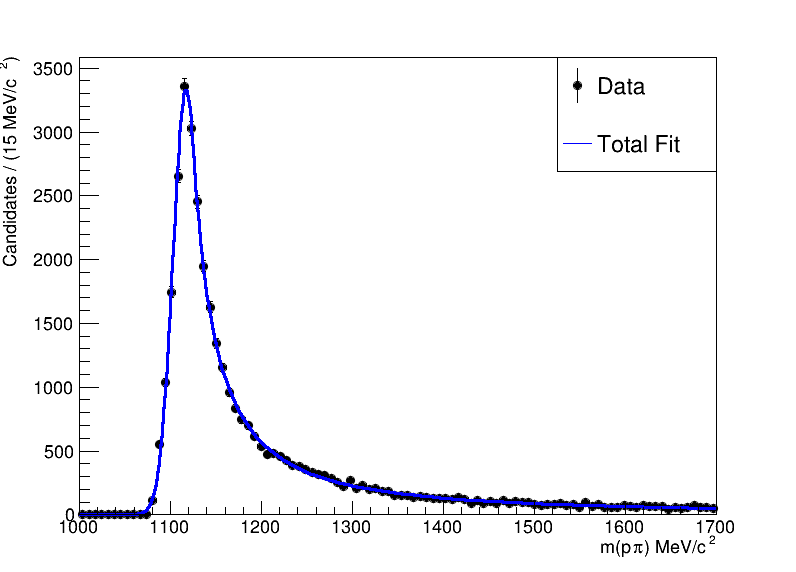

In [70]:
import ROOT
import pandas as pd

# Filtra los datos según las condiciones especificadas
filtered_mass = mc_test['L_MASS']

# Convierte la Serie de pandas filtrada a un RooDataSet
x = ROOT.RooRealVar('x', 'x', 1000, 1700)
data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
for mass in filtered_mass:
    x.setVal(mass)
    data_list.add(ROOT.RooArgSet(x))

# Define los parámetros para la señal (izquierda y derecha) usando CrystalBallShape
sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 1115, 1100, 1150)
sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 10, 1, 100)

# Parámetros de la cola izquierda
alpha1 = ROOT.RooRealVar('alpha1', 'alpha1', -1.5, -10.0, -0.5)
n1 = ROOT.RooRealVar('n1', 'n1', 10, 0.1, 10)

# Parámetros de la cola derecha
alpha2 = ROOT.RooRealVar('alpha2', 'alpha2', 1.5, 0.5, 10.0)
n2 = ROOT.RooRealVar('n2', 'n2', 2, 0.1, 100)

# Crear dos Crystal Ball: uno para la cola izquierda y otro para la derecha
cb_left = ROOT.RooCBShape('cb_left', 'Crystal Ball Left Tail', x, sigmean, sigwidth, alpha1, n1)
cb_right = ROOT.RooCBShape('cb_right', 'Crystal Ball Right Tail', x, sigmean, sigwidth, alpha2, n2)

# Cambia la fracción para dar más peso a la función de cola derecha
frac = ROOT.RooRealVar('frac', 'frac', 0.9, 0.0, 1.0)
signalModel = ROOT.RooAddPdf('signal', 'Double Crystal Ball', cb_left, cb_right, frac)

# Realiza el ajuste de la señal
signal_fit_result = signalModel.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Extrae y muestra los resultados de ajuste
print("\n===== Parámetros del Ajuste =====")
print(f"sigmean: {sigmean.getVal()} ± {sigmean.getError()}")
print(f"sigwidth: {sigwidth.getVal()} ± {sigwidth.getError()}")
print(f"alpha1: {alpha1.getVal()} ± {alpha1.getError()}")
print(f"n1: {n1.getVal()} ± {n1.getError()}")
print(f"alpha2: {alpha2.getVal()} ± {alpha2.getError()}")
print(f"n2: {n2.getVal()} ± {n2.getError()}")
print(f"frac: {frac.getVal()} ± {frac.getError()}")

# Muestra algunas estadísticas del ajuste
xframe = x.frame()
data_list.plotOn(xframe)
signalModel.plotOn(xframe)
chi2 = xframe.chiSquare()
ndof = xframe.GetNbinsX() - signal_fit_result.floatParsFinal().getSize()
print("\n===== Estadísticas del Ajuste =====")
print(f"Chi2/Ndof: {chi2}/{ndof}")

# Crea un RooPlot para dibujar
xframe = x.frame()

# Dibuja los datos y el modelo de señal
data_list.plotOn(xframe)
signalModel.plotOn(xframe, ROOT.RooFit.LineColor(ROOT.kBlue)) 


# Configura los títulos de los ejes
xframe.SetTitle("")
xframe.SetXTitle("m(p#pi) MeV/c^{2}")
xframe.SetYTitle("Candidates / (15 MeV/c^{2})")

# Crea una leyenda
legend = ROOT.TLegend(0.7, 0.7, 0.9, 0.9)
# Ajusta el estilo de los puntos de la leyenda a círculos
data_marker = ROOT.TMarker()
data_marker.SetMarkerStyle(ROOT.kFullCircle)
legend.AddEntry(data_marker, "Data", "pe")

signal_line = ROOT.TLine()
signal_line.SetLineColor(ROOT.kBlue)
legend.AddEntry(signal_line, "Total Fit", "l")

# Dibuja el gráfico
canvas = ROOT.TCanvas('canvas', 'Fit Plot', 800, 600)
xframe.Draw()
legend.Draw()
canvas.Draw()


Welcome to JupyROOT 6.30/04
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization

===== Parámetros del Ajuste =====
sigmean: 1116.9474578330205 ± 0.30591244301069764
sigwidth: 14.687098733779601 ± 0.22282067727745858
alpha1: -0.5000000001475282 ± 0.004099382439756383
n1: 2.040711092526646 ± 0.03541038251819906
alpha2: 4.720118755043912 ± 6.736026171360356
n2: 7.069932593393731 ± 95.67443920304723
frac: 0.9999997718529878 ± 0.004345619137856416
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (cb_left,cb_right)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization

===== Estadísticas del Ajuste =====
Chi2/Ndof: 1.554135290665699/93


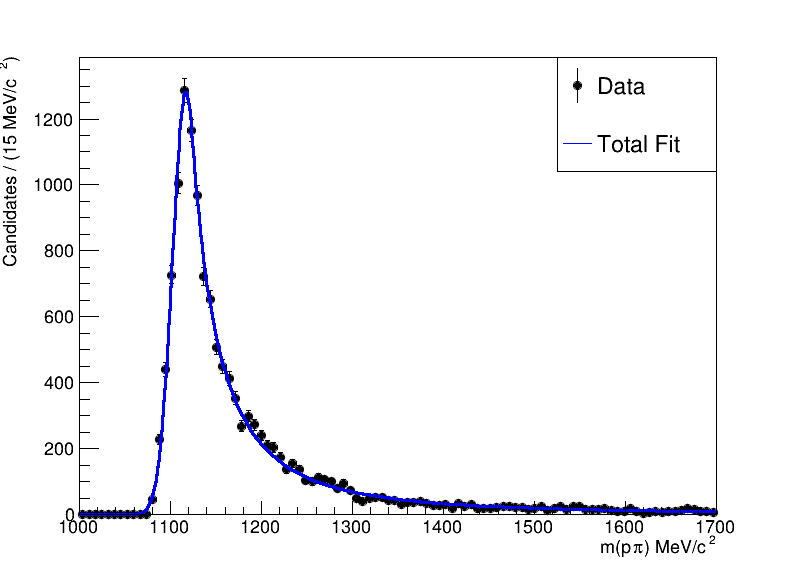

In [4]:
import ROOT
import pandas as pd

# Filtra los datos según las condiciones especificadas
filtered_mass = data24_magup.loc[
        (data24_magup['prob'] > 0.96), 
        'L_MASS'
    ]

# Convierte la Serie de pandas filtrada a un RooDataSet
x = ROOT.RooRealVar('x', 'x', 1000, 1700)
data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
for mass in filtered_mass:
    x.setVal(mass)
    data_list.add(ROOT.RooArgSet(x))

# Define los parámetros para la señal (izquierda y derecha) usando CrystalBallShape
sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 1115, 1100, 1150)
sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 10, 1, 100)

# Parámetros de la cola izquierda
alpha1 = ROOT.RooRealVar('alpha1', 'alpha1', -1.5, -10.0, -0.5)
n1 = ROOT.RooRealVar('n1', 'n1', 10, 0.1, 10)

# Parámetros de la cola derecha
alpha2 = ROOT.RooRealVar('alpha2', 'alpha2', 1.5, 0.5, 10.0)
n2 = ROOT.RooRealVar('n2', 'n2', 2, 0.1, 100)

# Crear dos Crystal Ball: uno para la cola izquierda y otro para la derecha
cb_left = ROOT.RooCBShape('cb_left', 'Crystal Ball Left Tail', x, sigmean, sigwidth, alpha1, n1)
cb_right = ROOT.RooCBShape('cb_right', 'Crystal Ball Right Tail', x, sigmean, sigwidth, alpha2, n2)

# Cambia la fracción para dar más peso a la función de cola derecha
frac = ROOT.RooRealVar('frac', 'frac', 0.9, 0.0, 1.0)
signalModel = ROOT.RooAddPdf('signal', 'Double Crystal Ball', cb_left, cb_right, frac)

# Realiza el ajuste de la señal
signal_fit_result = signalModel.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Extrae y muestra los resultados de ajuste
print("\n===== Parámetros del Ajuste =====")
print(f"sigmean: {sigmean.getVal()} ± {sigmean.getError()}")
print(f"sigwidth: {sigwidth.getVal()} ± {sigwidth.getError()}")
print(f"alpha1: {alpha1.getVal()} ± {alpha1.getError()}")
print(f"n1: {n1.getVal()} ± {n1.getError()}")
print(f"alpha2: {alpha2.getVal()} ± {alpha2.getError()}")
print(f"n2: {n2.getVal()} ± {n2.getError()}")
print(f"frac: {frac.getVal()} ± {frac.getError()}")

# Muestra algunas estadísticas del ajuste
xframe = x.frame()
data_list.plotOn(xframe)
signalModel.plotOn(xframe)
chi2 = xframe.chiSquare()
ndof = xframe.GetNbinsX() - signal_fit_result.floatParsFinal().getSize()
print("\n===== Estadísticas del Ajuste =====")
print(f"Chi2/Ndof: {chi2}/{ndof}")

# Crea un RooPlot para dibujar
xframe = x.frame()

# Dibuja los datos y el modelo de señal
data_list.plotOn(xframe)
signalModel.plotOn(xframe, ROOT.RooFit.LineColor(ROOT.kBlue)) 


# Configura los títulos de los ejes
xframe.SetTitle("")
xframe.SetXTitle("m(p#pi) MeV/c^{2}")
xframe.SetYTitle("Candidates / (15 MeV/c^{2})")

# Crea una leyenda
legend = ROOT.TLegend(0.7, 0.7, 0.9, 0.9)
# Ajusta el estilo de los puntos de la leyenda a círculos
data_marker = ROOT.TMarker()
data_marker.SetMarkerStyle(ROOT.kFullCircle)
legend.AddEntry(data_marker, "Data", "pe")

signal_line = ROOT.TLine()
signal_line.SetLineColor(ROOT.kBlue)
legend.AddEntry(signal_line, "Total Fit", "l")

# Dibuja el gráfico
canvas = ROOT.TCanvas('canvas', 'Fit Plot', 800, 600)
xframe.Draw()
legend.Draw()
canvas.Draw()



===== Parámetros del Ajuste =====
sigmean: 1119.9999995156195 ± 0.04885181574763919
sigwidth: 16.62943478216568 ± 0.1575106343474122
alpha1: -0.5000000002102905 ± 0.0005845994849167369
n1: 1.6487150878063048 ± 0.019195013199089228
alpha2: 8.428364256660585 ± 8.685878469059475
n2: 41.22338062958388 ± 22.45261102115419
frac: 0.99918422508262 ± 5.361999625808078e-06

===== Estadísticas del Ajuste =====
Chi2/Ndof: 2.7361032441936475/93
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (cb_left,cb_right)
[#0] WARNING:Eval -- RooAddPdf::updateCoefCache(signal WARNING: sum of PDF coefficients not in range [0-1], value=1.04053
[#0] WARNING:Eval -- RooAddPdf::updateCoefCache(signal WARNING: sum of PDF coefficients not in range [0-1], value=1.04053
[#0] WARNING:Eval -- RooAddPdf::updateCoefCache(signal WARNING: sum of PDF coefficients not in range [0-1], va

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas


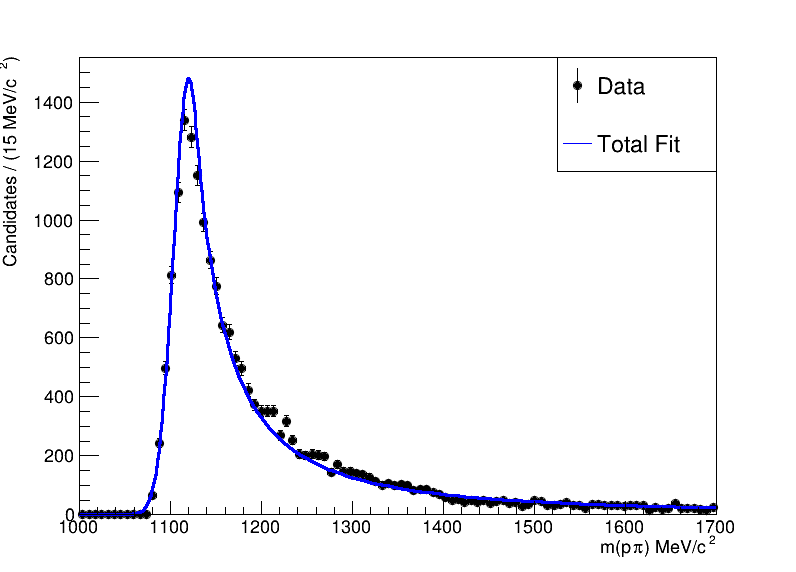

In [7]:
import ROOT
import pandas as pd

# Filtra los datos según las condiciones especificadas
filtered_mass = data24_magdown.loc[
        (data24_magdown['prob'] > 0.90), 
        'L_MASS'
    ]

# Convierte la Serie de pandas filtrada a un RooDataSet
x = ROOT.RooRealVar('x', 'x', 1000, 1700)
data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
for mass in filtered_mass:
    x.setVal(mass)
    data_list.add(ROOT.RooArgSet(x))

# Define los parámetros para la señal (izquierda y derecha) usando CrystalBallShape
sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 1115, 1100, 1120)
sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 10, 1, 100)

# Parámetros de la cola izquierda
alpha1 = ROOT.RooRealVar('alpha1', 'alpha1', -1.5, -10.0, -0.5)
n1 = ROOT.RooRealVar('n1', 'n1', 10, 0.1, 10)

# Parámetros de la cola derecha
alpha2 = ROOT.RooRealVar('alpha2', 'alpha2', 1.5, 0.5, 10.0)
n2 = ROOT.RooRealVar('n2', 'n2', 2, 0.1, 100)

# Crear dos Crystal Ball: uno para la cola izquierda y otro para la derecha
cb_left = ROOT.RooCBShape('cb_left', 'Crystal Ball Left Tail', x, sigmean, sigwidth, alpha1, n1)
cb_right = ROOT.RooCBShape('cb_right', 'Crystal Ball Right Tail', x, sigmean, sigwidth, alpha2, n2)

# Cambia la fracción para dar más peso a la función de cola derecha
frac = ROOT.RooRealVar('frac', 'frac', 0.9, 0.0, 5.0)
signalModel = ROOT.RooAddPdf('signal', 'Double Crystal Ball', cb_left, cb_right, frac)

# Realiza el ajuste de la señal
signal_fit_result = signalModel.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Extrae y muestra los resultados de ajuste
print("\n===== Parámetros del Ajuste =====")
print(f"sigmean: {sigmean.getVal()} ± {sigmean.getError()}")
print(f"sigwidth: {sigwidth.getVal()} ± {sigwidth.getError()}")
print(f"alpha1: {alpha1.getVal()} ± {alpha1.getError()}")
print(f"n1: {n1.getVal()} ± {n1.getError()}")
print(f"alpha2: {alpha2.getVal()} ± {alpha2.getError()}")
print(f"n2: {n2.getVal()} ± {n2.getError()}")
print(f"frac: {frac.getVal()} ± {frac.getError()}")

# Muestra algunas estadísticas del ajuste
xframe = x.frame()
data_list.plotOn(xframe)
signalModel.plotOn(xframe)
chi2 = xframe.chiSquare()
ndof = xframe.GetNbinsX() - signal_fit_result.floatParsFinal().getSize()
print("\n===== Estadísticas del Ajuste =====")
print(f"Chi2/Ndof: {chi2}/{ndof}")

# Crea un RooPlot para dibujar
xframe = x.frame()

# Dibuja los datos y el modelo de señal
data_list.plotOn(xframe)
signalModel.plotOn(xframe, ROOT.RooFit.LineColor(ROOT.kBlue)) 


# Configura los títulos de los ejes
xframe.SetTitle("")
xframe.SetXTitle("m(p#pi) MeV/c^{2}")
xframe.SetYTitle("Candidates / (15 MeV/c^{2})")

# Crea una leyenda
legend = ROOT.TLegend(0.7, 0.7, 0.9, 0.9)
# Ajusta el estilo de los puntos de la leyenda a círculos
data_marker = ROOT.TMarker()
data_marker.SetMarkerStyle(ROOT.kFullCircle)
legend.AddEntry(data_marker, "Data", "pe")

signal_line = ROOT.TLine()
signal_line.SetLineColor(ROOT.kBlue)
legend.AddEntry(signal_line, "Total Fit", "l")

# Dibuja el gráfico
canvas = ROOT.TCanvas('canvas', 'Fit Plot', 800, 600)
xframe.Draw()
legend.Draw()
canvas.Draw()
